# Lesson 119 · Year 3 synthesis: graphs versus flat tables

Student lab · Four live TODO/CHECK tasks and a one-page written synthesis. Default: exact course examples plus scoring of embedded real F1 predictions. Full training is a separate OFF-by-default gate. Prediction artifacts are author evidence, not your own model training.

In [ ]:
# @colab-bootstrap: install missing dependencies; report actual versions.
import importlib.util,importlib.metadata,subprocess,sys
required={'numpy':'numpy','pandas':'pandas','pyarrow':'pyarrow','torch':'torch','torch_frame':'pytorch-frame==0.2.3','torch_geometric':'torch-geometric==2.6.1','relbench':'relbench==1.1.0','pooch':'pooch'}
missing=[package for module,package in required.items() if importlib.util.find_spec(module) is None]
if missing:subprocess.check_call([sys.executable,'-m','pip','install',*missing])
print('Actual notebook runtime:',sys.version)
print({k:importlib.metadata.version(k) for k in ['numpy','pandas','torch','pytorch-frame','torch-geometric','relbench']})


## Execution contract

The default notebook needs no checkout, private path or external dataset download. Figures and fresh prediction arrays are embedded. It executes complete model definitions but does not train by default. The bootstrap installs only missing packages and reports your actual versions; it does not certify a historical environment. The optional full reproduction requires the pinned Python3.11/CUDA12.4 runtime and native pyg-lib described in the contract. Live Colab NOT_CHECKED.

**Data tiers:** the authored pair and graph examples isolate mechanisms; the embedded 6,295 predictions come from five fresh full-data RelBench runs. Neither kind of evidence substitutes for the other.

<!-- sequence-review:start -->
<aside class="sequence-context" aria-label="Where this lesson fits">
<p class="sequence-eyebrow">From Lesson 118 to this lesson</p>
<p>The two relational constructions expose useful choices. Now separate information preserved by a representation, functions a model can express, and evidence from a measured experiment.</p>
<details><summary>Quick prerequisite reminder</summary><p>A collision means different inputs become identical features. No deterministic predictor using only those features can give the two inputs different answers.</p></details>
</aside>
<!-- sequence-review:end -->

<p class="stream-kicker">From a plausible thesis to a defensible argument</p>

**Your win:** write one page explaining when relational structure helps prediction, when flat features suffice, and what your Year 3 evidence actually establishes.

[Student notebook](https://avistian.github.io/relational/labs/0119-year-3-synthesis.ipynb) · [Executed solution](https://avistian.github.io/relational/labs/html/0119-year-3-synthesis.html) · [Quick reference](https://avistian.github.io/relational/reference/year-3-synthesis.html) · [Writing template](https://avistian.github.io/relational/labs/l119-writing-template.md) · [Reproduction contract](https://avistian.github.io/relational/labs/l119-reproduction.md)

Take the short route through Sections 1–5 and the writing task. Use Sections 6–8 and the notebook for the empirical audit. This is the synthesis before the Year 3 exit exam, not a new architecture survey.

Without notes: explain one aggregation collision, one limit of message passing, and the timestamp that governs a two-hop prediction.



## 1 · Separate information, computation, and evidence

Your mission is to test whether learned relational models unlock predictive value beyond a single-table workflow. The useful question is specific: **which information reaches this predictor, which computation can use it, and under which evaluation protocol does it help?**

A **representation** is the information made available to a model. For example, a customer row containing order count and total spending is one representation; dated order rows linked to that customer are another. A **hypothesis class** is the set of functions a model can express. Giving a graph to a limited message-passing network does not guarantee that the network can distinguish every pair of graphs.

Finally, **empirical evidence** is an observed result under a stated protocol. It is not interchangeable with a representation argument. A graph may contain additional information that is irrelevant to the target, too sparse to learn from, or unavailable at prediction time.

The causal chain is:

1. The database contains particular attributes and relationships.
2. Extraction decides which of them are visible for a prediction.
3. Encoding and aggregation preserve some distinctions and erase others.
4. Training tries to exploit the remaining distinctions.
5. Evaluation tests the resulting predictor on specified future queries.

An error at any step weakens the conclusion. [Fey et al.'s RDL blueprint](https://proceedings.mlr.press/v235/fey24a.html) supplies the relational modeling motivation. In this lesson, the small examples are original course constructions; they are not figures or benchmark results reproduced from that paper.



## 2 · A collision proves something narrow and useful

Return to [Lesson 035](https://avistian.github.io/relational/lessons/0035-what-joins-destroy.html) and [Lesson 077](https://avistian.github.io/relational/lessons/0077-single-table-ceiling.html). A **collision** occurs when distinct inputs become the same representation. Once that happens, a deterministic predictor receiving only that representation must return the same answer for both.

**Worked example.** Ada's order amounts at times 1, 2, 3 are `[10, 30, 50]`. Bo's are `[50, 30, 10]`. The labels in this authored exercise are simply “rising” and “falling”; they are not observed churn labels. Both summaries are `(count=3, total=90, mean=30, max=50)`.

Predict first: can any classifier using only those four numbers label both examples correctly?

<figure class="stream-figure" tabindex="0" style="max-width:100%;overflow:auto">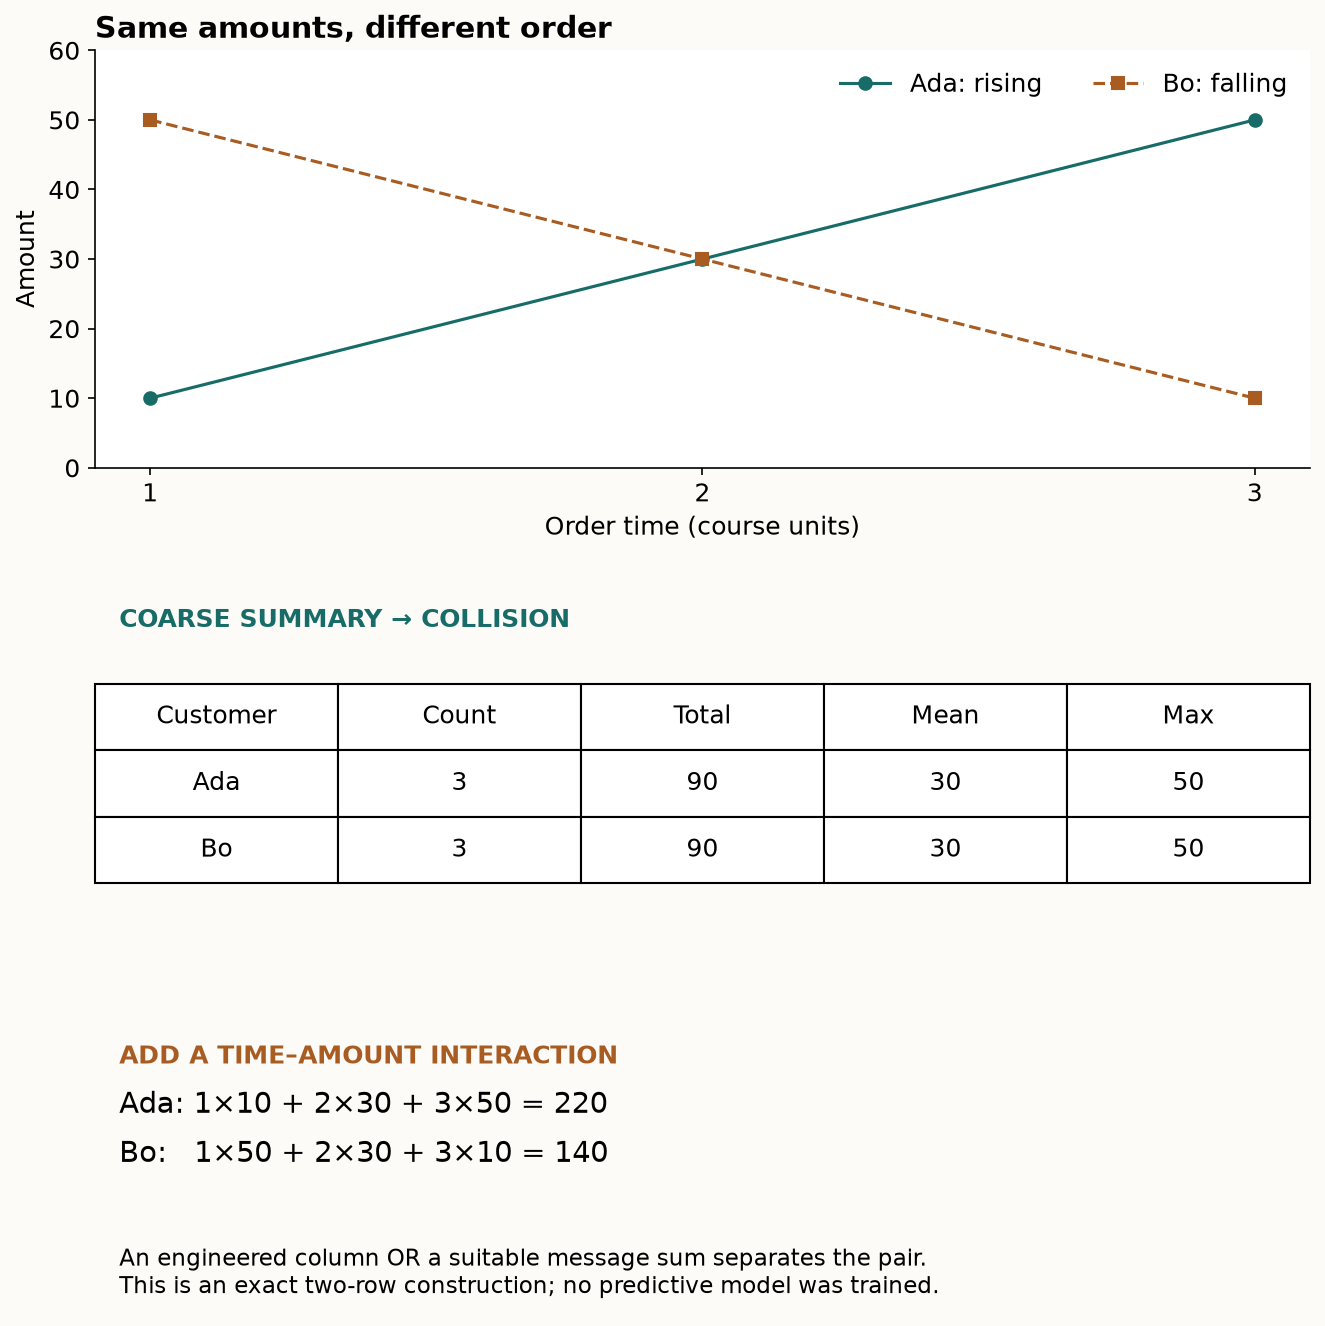<figcaption>A chosen four-number summary erases temporal order. An engineered time-weighted sum or suitable message sum restores this distinction: 220 versus 140. Scroll sideways on narrow screens.</figcaption></figure>
Static trace: [3,90,30,50] for both rows gives a 50% observed ceiling. Add time-weighted sums 220 and 140: the ceiling becomes 100% on these two examples.

It cannot. In this balanced two-example world, it gets at most one of two labels right. Changing a tree into a neural network does not restore the discarded order. Repeating the same examples under more random seeds does not restore it either.

For any finite labeled set, partition the rows into groups with identical features. Within each group, the most accurate fixed prediction is the majority label. The **observed representation ceiling** is:

`ceiling = sum(largest label count within each identical-feature group) / number of rows`.

This is an exact bound on these observed rows for deterministic classifiers restricted to these features. It is not a confidence interval, a population estimate, or a promise that training will attain it. For continuous features, almost every row may be unique and this diagnostic may become uninformative.

**Repair the representation.** Add the feature `sum(time × amount)`. Ada gets `1×10 + 2×30 + 3×50 = 220`; Bo gets `1×50 + 2×30 + 3×10 = 140`. A threshold at 180 separates them. A manually engineered table can therefore recover this distinction.

**Connect to message passing.** An order node could emit its `time × amount` contribution, and a sum aggregator could send those contributions to the customer. A learned message function could potentially learn a useful time–amount interaction. This construction only establishes representability with suitable inputs and operators; we did not train such a model here. If the node features contain amounts alone and aggregation ignores ordering, Ada and Bo still present the same multiset `{10,30,50}`.

> **In plain terms.** The failure belongs to the chosen summary. A better feature or a suitable graph computation can repair it. Neither “all tables lose structure” nor “graphs automatically recover it” follows.

**Notebook TODO 1:** compute the ceiling from identical-feature groups. Its CHECK includes unequal group sizes so counting groups instead of observations fails.



## 3 · Message passing learns aggregation, but still compresses

[Lesson 081](https://avistian.github.io/relational/lessons/0081-mpnn-framework.html) describes a message-passing neural network, or **MPNN**. Each node starts with a feature vector. A **message function** transforms information from a neighbor. An **aggregation function**, often sum or mean, combines incoming messages without depending on their input order. An **update function** combines the aggregate with the node's previous state.

One round communicates over one edge. A node normally needs two rounds to receive information from a node two edges away. The synchronous update uses the previous round's states throughout; it does not immediately reuse a just-updated neighbor.

Static trace: C=8 gives A=3 after one round and A=3.75 after two. C=20 keeps A=3 after one round and changes its two-round state to 5.25.

In this scalar example, each node retains half its old value and adds half the mean of its neighbors. At baseline `[A,B,C,D]=[2,4,8,10]`, A becomes 3 after one round and 3.75 after two. D is isolated and uses zero for its empty neighbor mean. Raising C to 20 changes A only after the second round, to 5.25. The widget is a course arithmetic example, not the RelBench layer.

### A graph can contain a distinction that the model cannot use

Consider a six-node cycle and two disconnected triangles. Give every node the same feature 1, the same node type, and the same edge type. Every node has exactly two neighbors.

Use the shared update `new_state = old_state + sum(neighbor_states)`. Every node becomes 3, then 9, then 27, then 81 in both graphs. Their six-node sum readouts are also equal. One graph is connected and the other is not, yet this computation cannot distinguish them.

<figure class="stream-figure" tabindex="0" style="max-width:100%;overflow:auto">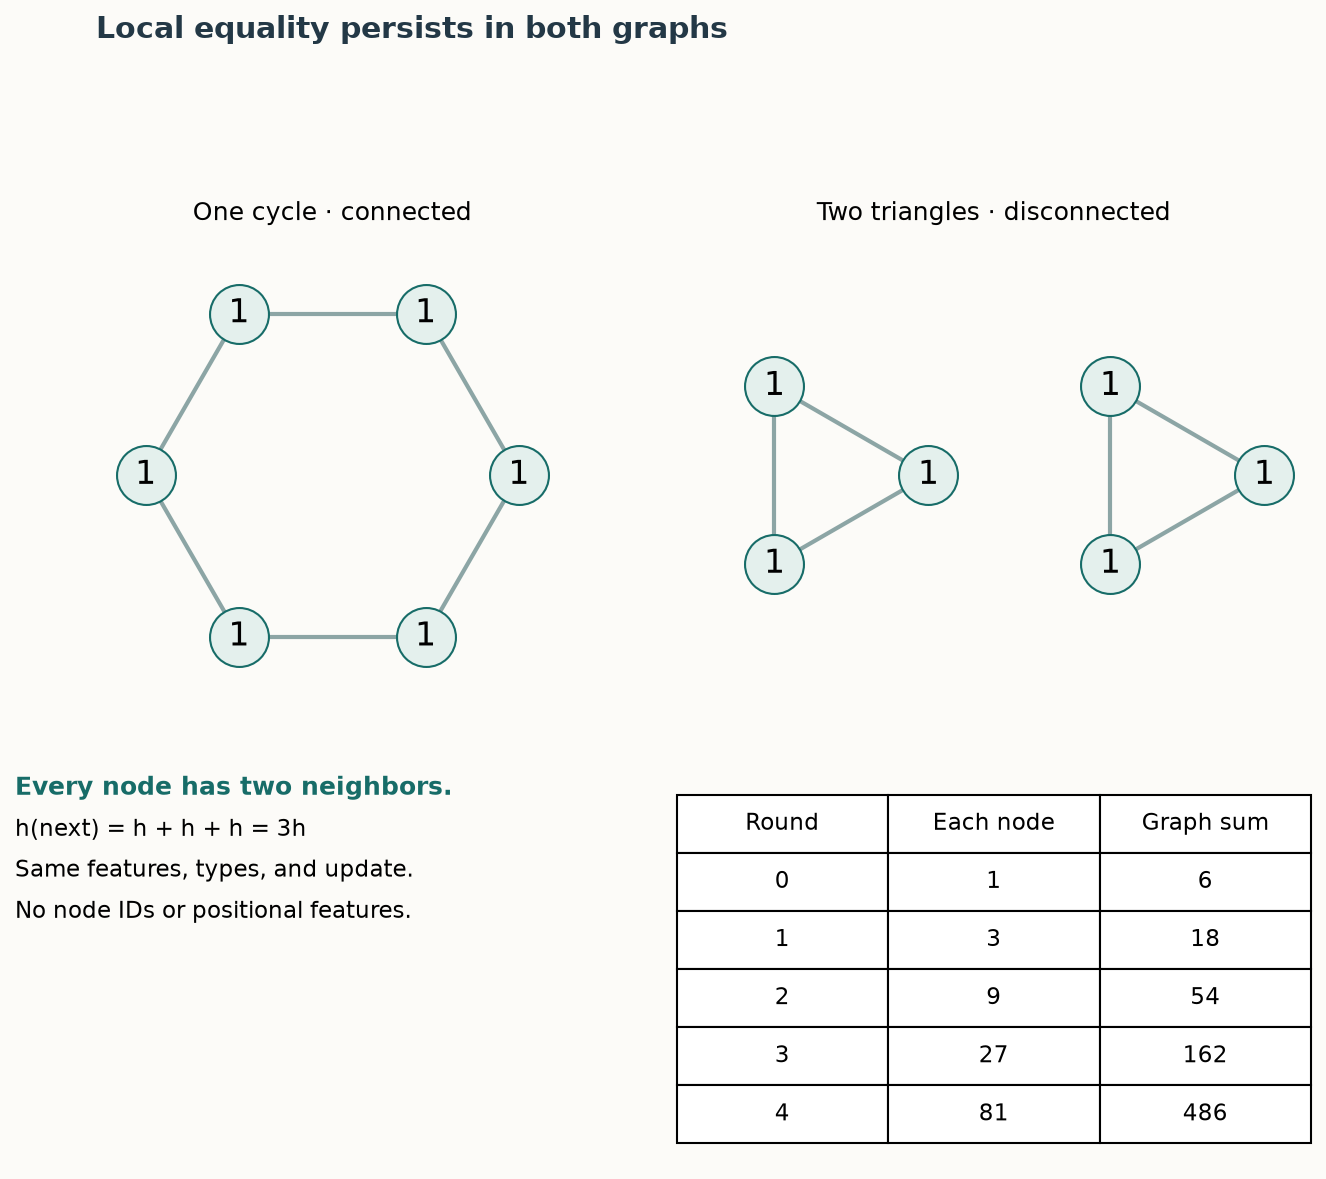<figcaption>Equal initial states and two equal neighbors per node stay equal in a six-cycle and two triangles. The displayed shared sum update cannot detect connectivity. Scroll sideways on narrow screens.</figcaption></figure>

The argument extends beyond these particular numbers for ordinary shared, permutation-invariant local message passing under these initial features: equal states and equal neighbor-state multisets remain equal at every round. Global sum or mean readout then sees the same six states. Extra distinguishing inputs or different operators change the assumptions.

[Xu et al.](https://arxiv.org/abs/1810.00826) formalize expressiveness limits and the conditions under which aggregation can distinguish multisets. Our two-graph calculation is a small witness you can verify yourself. More layers do not fix this symmetry. A hand-engineered connected-component count would distinguish these two graphs.

**Transfer question:** why does the extra time feature fix the order example while extra rounds do not fix the cycle example? Identify what changes in the first case and what stays indistinguishable in the second.



## 4 · Relation meaning and prediction time are part of the model

### Types decide what a relationship means

[Lesson 091](https://avistian.github.io/relational/lessons/0091-r-gcn.html) introduced relation-specific transformations. A **relation type** names a semantic connection, such as “buys” or “refunds.” It is not merely a drawing color.

**Worked example.** Both customers connect to values 10 and 4. For customer A the 10 is a purchase and the 4 is a refund; for B those roles are reversed. Untyped sum gives 14 for both. Give purchase messages weight +1 and refund messages weight −1: the outputs become +6 and −6. The topology and values did not change; the relation meanings did.

| Stage | Customer A | Customer B |
|---|---:|---:|
| Purchase contribution | +10 | +4 |
| Refund contribution | −4 | −10 |
| Typed sum | +6 | −6 |
| Untyped sum | 14 | 14 |

This scalar example is not a full R-GCN implementation. It isolates why relation-specific message functions can preserve a distinction that pooling all relations together discards. A table with separate purchase/refund columns can preserve it too. Even typed sums can collide for other inputs.

**Notebook TODO 2:** accumulate each relation's weighted source value at its destination. Tests include swapped relation names, repeated edges, and renamed node positions. Renaming positions must only rename outputs.

### Time decides what the predictor is allowed to know

[Lesson 104](https://avistian.github.io/relational/lessons/0104-information-leakage-in-time.html) distinguishes **event time**, when something happened, from **availability time**, when the prediction system could first know it. A row with event time 5 but availability time 9 is unavailable to a prediction at time 7.

For this course audit, a row is eligible only if both clocks are no later than the original query cutoff. A declared timeless dimension does not grant access to future events connected through it. `None` in this exercise means explicitly timeless; it must not be used as a shortcut for an unknown ingestion date.

| Two-hop path from the query at 7 | Event | Available | Decision |
|---|---:|---:|---|
| Customer → timeless dimension → row A | 5 | 9 | Exclude: arrived late |
| Customer → timeless dimension → row B | 6 | 6 | Include |
| Customer → timeless dimension → row C | 11 | 11 | Exclude: future event |

**Notebook TODO 3:** walk the graph using the same query cutoff at every hop. A test catches implementations that check event time alone.

Target outcomes may occur after the prediction timestamp; that is the prediction problem. They must not enter input features, and a training label must already be mature when the historical training process uses it. Feature-statistic fitting, mutable feature histories, and graph sampling need separate checks. An event-time sampler alone does not settle all of them.



## 5 · Build an argument with an evidence ledger

An **evidence ledger** attaches each claim to its source, measurement, and remaining limitation. It prevents a correct local computation from silently turning into a universal empirical conclusion.

| Claim | What supports it here | What remains open |
|---|---|---|
| These four summary features cannot distinguish the order pair | Exact collision and .5 observed ceiling | Frequency and predictive value of such collisions in real tasks |
| A richer representation can separate this pair | Explicit 220/140 calculation | Whether learning discovers a useful rule on new data |
| Ordinary message passing has limits | Cycle/triangles calculation under equal features | Behavior after adding distinguishing features or operators |
| Typed and time-valid access matters | Controlled relation and dual-clock checks | Actual ingestion/revision history in a real database |
| The selected RDL experiment is executable | Fresh five-seed full-data replay below | Historical run identity, all other tasks, and a fresh matched tabular comparison |

The previous [Lesson 118](https://avistian.github.io/relational/lessons/0118-cvitkovic-relational-gnn.html) contributes lineage and a reproduction limitation. Its Home Credit full run remains **NOT_RUN** because the measured pilot projected beyond the budget. A correct port, a timing pilot, and a completed paper experiment are different kinds of evidence. Preserve that gap in your synthesis.



## 6 · Fresh empirical anchor: a complete selected RelBench replay

The empirical companion is **RelBench v1, Table 7, `rel-f1/driver-position`, RDL column**. A query identifies a driver and prediction date; the regression target describes subsequent finishing position. **Mean absolute error (MAE)** averages absolute differences between predictions and targets. Lower is better. Read [Table 7 and Appendix B](https://arxiv.org/html/2407.20060v1) alongside the [pinned release](https://github.com/snap-stanford/relbench/tree/9aa346267c2e1c560bd92da07d6f4ad1ca2f0639).

This is a new execution of the complete selected protocol from Lesson 117: all nine tables, 74,063 release-censored rows, 7,453 training queries, 499 validation queries and 760 test queries. Five declared seeds each train for ten full epochs. Validation selects the first minimum-MAE checkpoint. Test scores are recorded afterward and never used to choose epochs.

<figure class="stream-figure" tabindex="0" style="max-width:100%;overflow:auto">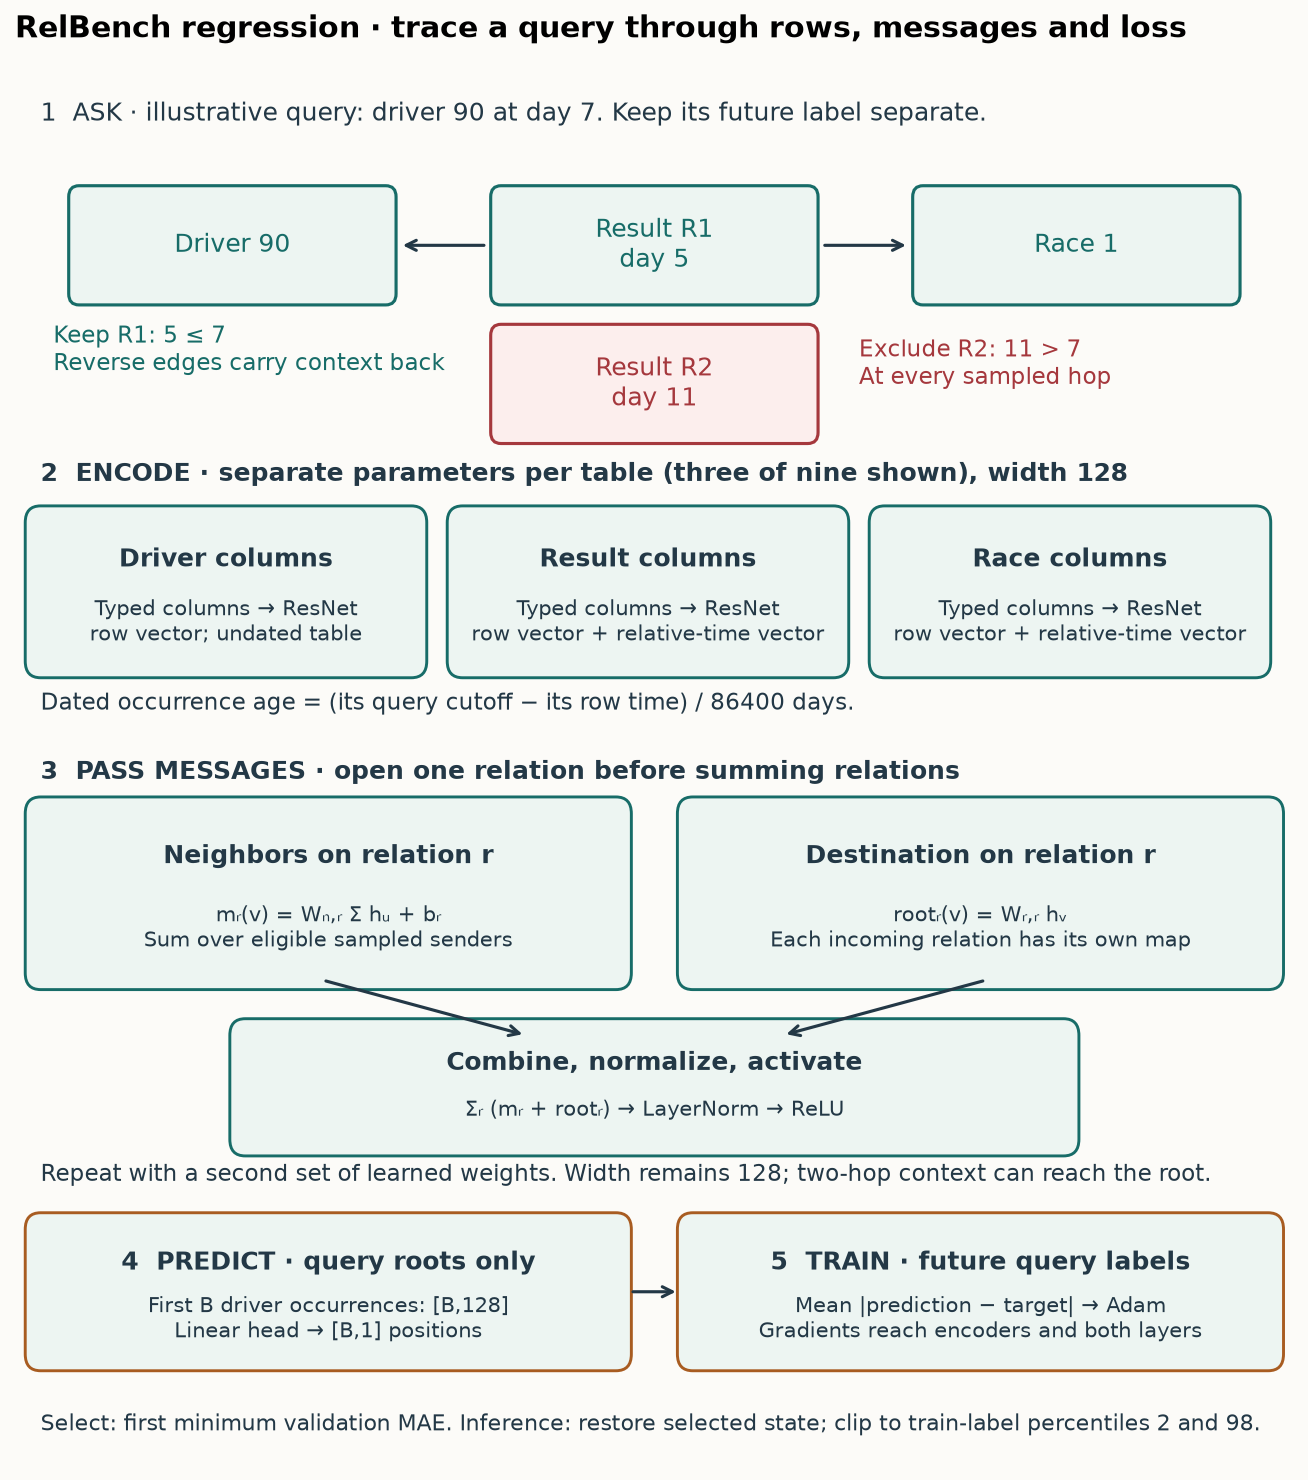<figcaption>The reused released RelBench regression model: query-time sampling, per-table encoders, two typed GraphSAGE layers, seed readout, loss and validation selection. Scroll sideways on narrow screens.</figcaption></figure>

**Diagram trace.** Trace the inherited RDL predictor, then separate that measured model from the synthetic representation-collision argument. On a narrow screen, scroll the figure sideways.

**Trace the actual computation.** The query supplies the cutoff and seed node. Temporal sampling creates query-specific context. Table-specific encoders produce 128-wide row vectors; relative-age encodings carry time. Two typed GraphSAGE layers aggregate messages. A linear head reads the seed driver's vector. Training minimizes mean absolute error with Adam at learning rate .005; inference clips predictions to training-target percentiles 2 and 98. The full graph constructor, model and trainer are visible in the notebook.

**Predict before inspecting the result:** would a score close to the published mean establish that this freshly run model beats a freshly run feature-engineered model? Write your reason first.

**Author-reference evidence: five fresh full-data fits for Lesson 119.** The notebook default only rescores these stored predictions.

| Split | Fresh mean MAE | Sample seed SD | Published RDL mean | Verdict |
|---|---:|---:|---:|---|
| val | 3.18950 | 0.04009 | 3.193 | CLOSE |
| test | 4.01457 | 0.12673 | 4.022 | CLOSE |

| Seed | Selected epoch | Validation MAE | Test MAE |
|---|---:|---:|---:|
| 0 | 9 | 3.15735 | 4.14047 |
| 1 | 8 | 3.18435 | 4.08645 |
| 2 | 8 | 3.19599 | 3.89961 |
| 3 | 10 | 3.15566 | 3.85788 |
| 4 | 7 | 3.25415 | 4.08844 |

All **6,295** final query predictions were independently rescored. The largest raw-output discrepancy from the separately loaded original model on the same inputs was **2.86e-06**. Selected experiment: **COMPLETE**; whole-paper parity: **NOT_ESTABLISHED**.

Pilot plus five-run measured worker resource estimate: **USD0.0584**. This excludes unitemized build/startup/storage charges. Reservations cap eight worker-hours at USD6.500736, with USD3.499264 held for overhead under the USD10 plan. [Fresh evidence](https://avistian.github.io/relational/labs/evidence/l119/summary.json) · [Budget](https://avistian.github.io/relational/labs/_budget_l119.json).

<figure class="stream-figure" tabindex="0" style="max-width:100%;overflow:auto">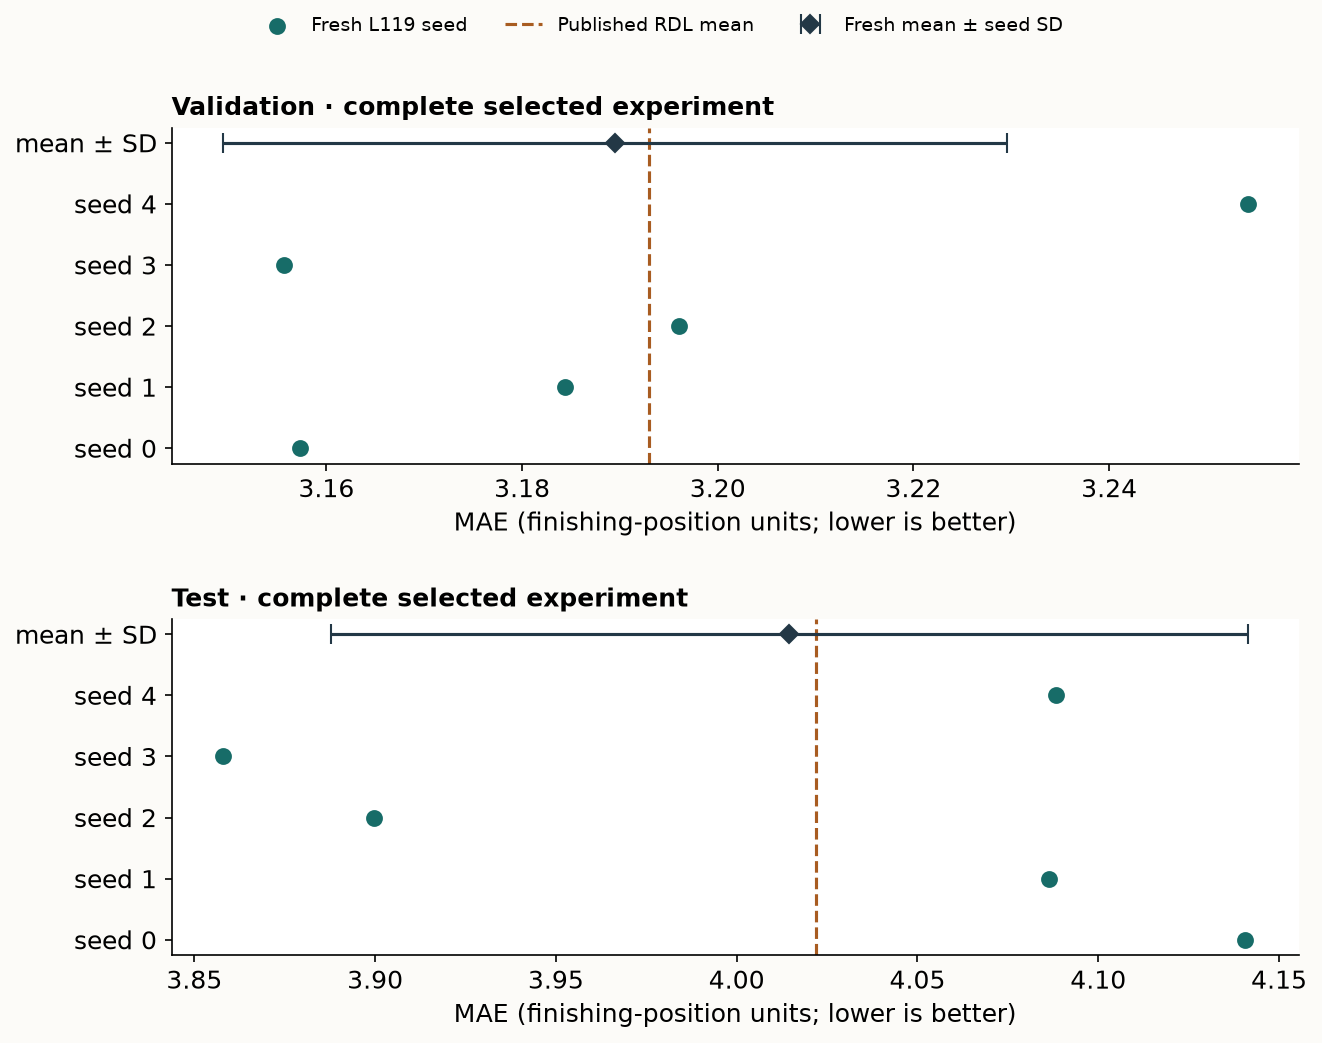<figcaption>Fresh L119 seeds and published RDL means. The diamond and bar show the fresh mean and sample seed standard deviation, not a confidence interval or a matched baseline comparison. Scroll sideways on narrow screens.</figcaption></figure>

### Interpret the comparison correctly

The published Table 7 F1 test means are 4.022 for RDL and 4.170 for LightGBM. Those are **cited paper measurements**. Only the RDL column was freshly trained here. Subtracting our new RDL score from the historical LightGBM mean does not create a matched comparison, a paired confidence interval, or a new claim of statistical superiority. The paper itself marks both test entries as best or not statistically different from best.

The plotted spread across five seeds describes training variability on one fixed task and split. It does not estimate variation across databases, future calendar periods, or feature-engineering choices. `CLOSE` uses a predeclared absolute mean tolerance of .2 MAE; it is a descriptive criterion, not an equivalence test.

> **Scope check.** The release samples fanout `[128,64]`, whereas the paper's hyperparameter table lists 128. Preprocessing statistics use the test-censored database rather than a train-only fit. Historical seeds/runtime and real ingestion or revision histories are unavailable. Full selected released-protocol execution can be COMPLETE while historical identity and whole-paper parity remain NOT_ESTABLISHED. The [contract](https://avistian.github.io/relational/labs/l119-reproduction.md) lists each deviation.



## 7 · Notebook: make your argument survive checks

The notebook is independently readable. It embeds the figures and fresh prediction artifacts, and exposes the full reproduction implementation. Its default run executes course mechanisms and rescores real predictions; it does not silently retrain the cloud experiment.

1. **Group by representation:** calculate the best observed label accuracy that any deterministic predictor could achieve from the available features.
2. **Keep relation meaning:** aggregate source messages with the correct relation weight and receiving node.
3. **Keep one temporal cutoff:** reject future and late-arriving rows at every hop.
4. **Align query identities:** calculate MAE after joining predictions to targets by the full query key.

For Task 4, an entity can recur at multiple times. “Driver 90” is therefore insufficient as a query identity. The exercise deliberately permutes predictions, so a position-based score fails. Your function then rescores all five runs' actual validation and test outputs. A missing query, duplicate query or nonfinite prediction causes a failure rather than silently changing the population.

The optional full-data gate reruns all five ten-epoch fits with the same visible model. Use the pinned environment and budgeted Modal operator in the contract for author-equivalent execution. The gate is OFF by default. Live Colab verification is a separate status.



## 8 · Write the one-page synthesis

Use the [submission template](https://avistian.github.io/relational/labs/l119-writing-template.md). Aim for **500–700 words**; the goal is a compact argument, not a survey of every architecture.

**Paragraph 1 — Claim and conditions.** State a testable claim about a target, database, prediction time and competing representations. Identify the information that might matter. Avoid “graphs are better” without conditions.

**Paragraph 2 — Mechanism.** Work through one collision and its repair. Explain whether a better flat feature can also repair it. Connect the needed computation to neighborhood depth and relation types.

**Paragraph 3 — Counterargument.** Explain the cycle/triangles failure or another precise limitation. Address temporal availability and a case where the extra relations need not improve generalization.

**Paragraph 4 — Evidence.** Cite two primary sources and one measured artifact. State the selected reproduction scope and at least two deviations. Preserve Lesson 118's unrun status. Explain why the fresh RDL replay alone is not a fresh graphs-versus-tables contest.

**Paragraph 5 — Falsification.** Propose a fair comparison on identical queries and cutoffs, with train-only fitting for the proposed new experiment, validation-only tuning, a strong flat-feature baseline, and predefined metrics. Specify an outcome that would weaken your claim. A useful information ablation holds features and query populations fixed while removing or permuting relevant edges; a compute/selection budget must also be comparable. This proposed experiment is not claimed executed here.

**Rubric, 0–2 each:** precise conditional claim; correct mechanism; substantive counterexample; evidence/protocol discipline; falsifiable comparison. A fluent essay that hides a failed or unrun experiment cannot earn full evidence credit.

Explain why both a lossy flat summary and a limited graph model can fail. State what the fresh selected reproduction adds, and which baseline experiment is still missing.

**Exit ticket:** submit the four live functions, the notebook report, and your synthesis. The teacher checks the code and challenges the argument. Author-reference execution does not mark your learning complete: **PENDING_WRITTEN_DEFENSE**.

**Spacing:** tomorrow, redraw the collision and its repair without notes. In seven days, explain the message-passing counterexample and the two-clock cutoff. In thirty days, rewrite the thesis paragraph using one new piece of counter-evidence.

**Next:** Lesson 120 asks you to build and defend a heterogeneous temporal GNN pipeline. This synthesis tells you what that pipeline must demonstrate. Ask the agent follow-up questions or paste your draft for a scored critique before advancing.

<!-- sequence-next:start -->
**Carry this forward.** Demonstrate the complete pipeline and defend it in the Year 3 exit exam. [Continue to Lesson 120](https://avistian.github.io/relational/lessons/0120-year-3-exit-exam.html).
<!-- sequence-next:end -->


## Implement the four evidence checks

Complete each TODO before running its CHECK. The final course and real-prediction cells call these exact functions. Checks give feedback on rejected cases; passing them does not grade the written argument.

### Shared dependencies (PROVIDED)

In [ ]:
from collections import Counter, defaultdict
import math
import numpy as np

### Task 1: accuracy ceiling for an observed representation

**Goal:** Find identical-feature groups and count their majority labels.

**Why:** This detects information lost before any classifier trains.

**Hint boundary:** use the stated information contract; do not change the CHECK.

In [ ]:
def collision_ceiling(features, labels):
    raise NotImplementedError("TODO: collision_ceiling")

In [ ]:
def check_ceiling(fn):
    assert fn([(2, 4), (2, 4)], [0, 1]) == .5, 'A collided pair cannot both be correct'
    assert fn([(0,), (0,), (0,), (1,), (1,)], [0, 0, 1, 1, 1]) == .8, 'Weight groups by rows'
    assert fn([(1,), (2,)], ['yes', 'no']) == 1., 'Distinct rows can separate observed labels'
    for x,y in [([], []), ([(1,)], [0,1])]:
        try: fn(x,y)
        except ValueError: pass
        else: raise AssertionError('Reject empty or misaligned observations')
check_ceiling(collision_ceiling)
print("PASS: collision_ceiling")

### Task 2: preserve the meaning of each relationship

**Goal:** Send weighted source values to their receiving nodes using each relation type.

**Why:** The same values can mean different things under different relationships.

**Hint boundary:** use the stated information contract; do not change the CHECK.

In [ ]:
def typed_sum(values, edges, weights):
    raise NotImplementedError("TODO: typed_sum")

In [ ]:
def check_typed(fn):
    edges=[(0,2,'buy'),(1,2,'refund')]
    np.testing.assert_array_equal(fn([10.,4.,0.],edges,{'buy':1.,'refund':-1.}),[0,0,6])
    np.testing.assert_array_equal(fn([10.,4.,0.],[(0,2,'refund'),(1,2,'buy')],{'buy':1.,'refund':-1.}),[0,0,-6])
    np.testing.assert_array_equal(fn([2.,0.],[(0,1,'r'),(0,1,'r')],{'r':3.}),[0,12])
    # Permutation equivariance: rename nodes without changing the computation.
    np.testing.assert_array_equal(fn([0.,10.,4.],[(1,0,'buy'),(2,0,'refund')],{'buy':1.,'refund':-1.}),[6,0,0])
check_typed(typed_sum)
print("PASS: typed_sum")

### Task 3: preserve one cutoff across a graph walk

**Goal:** Expand legal neighbors with one fixed query cutoff and both clocks.

**Why:** A late-arriving event is not available just because its event date is old.

**Hint boundary:** use the stated information contract; do not change the CHECK.

In [ ]:
def eligible_nodes(edges, event_times, available_times, seed, cutoff, hops):
    raise NotImplementedError("TODO: eligible_nodes")

In [ ]:
def check_time(fn):
    edges=[(0,1),(1,2),(1,3),(1,4)]
    event=[None,None,5,6,11];available=[None,None,9,6,11]
    assert fn(edges,event,available,0,7,2)==[0,1,3], 'Late-arriving and future rows must be excluded'
    assert fn(edges,event,available,0,9,2)==[0,1,2,3], 'Equality at availability cutoff is allowed'
    assert fn(edges,event,available,0,7,1)==[0,1], 'Respect hop budget'
    assert fn(edges,event,available,0,7,0)==[0], 'Seed only with zero hops'
    assert fn([(0,1)],[None,3],[None,4],0,4,1)==[0,1]
check_time(eligible_nodes)
print("PASS: eligible_nodes")

### Task 4: score predictions by query identity

**Goal:** Join predictions and targets by complete, unique query identity before scoring.

**Why:** Entity IDs repeat; row order is not a reliable join key.

**Hint boundary:** use the stated information contract; do not change the CHECK.

In [ ]:
def aligned_mae(pred_ids, predictions, target_ids, targets):
    raise NotImplementedError("TODO: aligned_mae")

In [ ]:
def check_mae(fn):
    ids=['driver90@7','driver10@7','driver90@12']
    assert fn([ids[2],ids[0],ids[1]],[10,4,5],ids,[3,7,11])==4/3, 'Join by full query ID, not position'
    for pi,p,ti,t in [(['a','a'],[1,2],['a','b'],[1,2]),(['a'],[1],['b'],[1]),(['a'],[np.nan],['a'],[1]),(['a'],[1,2],['a'],[1])]:
        try: fn(pi,p,ti,t)
        except ValueError: pass
        else: raise AssertionError('Reject ambiguous, missing or nonfinite predictions')
check_mae(aligned_mae)
print("PASS: aligned_mae")

### Mechanism fixtures (PROVIDED; not a benchmark)

In [ ]:
def course_experiment():
    amounts = np.array([[10.,30.,50.],[50.,30.,10.]])
    times = np.array([1.,2.,3.])
    coarse = [(len(x),sum(x),np.mean(x),max(x)) for x in amounts]
    time_weighted = [(float(np.dot(times,x)),) for x in amounts]
    labels = [1,0]  # Authored rising/falling labels; no inferred customer outcome.
    cycle = [(i,(i+1)%6,'r') for i in range(6)]
    triangles = [(0,1,'r'),(1,2,'r'),(2,0,'r'),(3,4,'r'),(4,5,'r'),(5,3,'r')]
    def undirected(edges): return edges + [(v,u,r) for u,v,r in edges]
    states=[]
    for edges in [cycle,triangles]:
        x=np.ones(6);history=[x.tolist()]
        for _ in range(4):
            x=x+typed_sum(x,undirected(edges),{'r':1.})
            history.append(x.tolist())
        states.append(history)
    typed=[typed_sum([10.,4.,0.],[(0,2,a),(1,2,b)],{'buy':1.,'refund':-1.})[2]
           for a,b in [('buy','refund'),('refund','buy')]]
    eligible=eligible_nodes([(0,1),(1,2),(1,3),(1,4)],
                            [None,None,5,6,11],[None,None,9,6,11],0,7,2)
    return dict(status='PASS',scope='COURSE_ONLY',coarse=coarse,
                coarse_ceiling=collision_ceiling(coarse,labels),
                augmented_ceiling=collision_ceiling(time_weighted,labels),
                time_weighted=time_weighted,typed_outputs=typed,
                untyped_outputs=[14.,14.],cycle_states=states[0],triangle_states=states[1],
                indistinguishable=states[0]==states[1],eligible_nodes=eligible)

## RUN · exact mechanisms and real prediction audit

Predict the representation ceilings and graph states before running. Your identity-aware scorer then joins intentionally reversed predictions to the correct real query targets. The arrays are the Lesson119 author runs, not a new fit in this notebook.

In [ ]:
# PROVIDED: actual fresh-run predictions, hash-checked before your scorer uses them.
import base64,hashlib,io,json
AUTHOR_PREDICTIONS = {'0': {'sha256': '17647227e989c1961c0ce328bee7950e495e310ebf1dca52cdc0b9303d7ca1fc', 'base64': 'UEsDBC0AAAAIAAAAIQCOglEK//////////8MABQAdmFsX3ByZWQubnB5AQAQAEwIAAAAAAAAKgcAAAAAAACdlelXEwYWxRHZIWExQMKShBASlkiVRYWhmJ8iFERERBFcIgJqZZXFgxAiogI6otatDqMdWqk4Hjou47R2XNCpS2WqUxcUEdShFNEDihui48Ck/8K8b+9+eOfcc++7d1fCvFmJqWNM1piUqzOzijIK1eFydcTyELVGrl6eX1hcmJ6nyy/MzPoNj07PKcoy4kUr0wuyjLtvSFiYxk8jr5D/32Nzo86WgrzpXP9iVPv8ipbLBn+yXnhSOsebzXVjaFvqw+JtPtTnFuMwkILv4xLef5fA0re2aDo30bsnFrNfN9OR4UlCcgiDyQL6HgRzYkE8Ept15KyZzWdlrmzrcWD+VF/OfpAzs7+AuF1SMgMXcO6JmGc/iOlxyObmEwOBhglUyW2x2O9B+CEVQ0+sqbqp4E61gX2RKtQxETRbiRixFHDkVznR6snIotKwErkS3ScmwUpFc70N+3UVnO6TYdZewV7n5cw+50HQuFJKIjzJ7a5m5wEp4mw52+xsMHwuwOasCtd7eprd7Mm8MKQd1gfQkbuS9iIxI3cFNGmDiZonpeeSkKcnXYkbVLHwSgpdWR9j8q0zk5ZOIbhPz3++VBH1RwMPs2W0nvPk25pUHm0ci/0iGatCPNnmp+DAGX+SWsM44uxGwEg0CocP2sRhPRc6RrV2yVHsFwiRDqbwo58HgzpHJp0XodvnzPhWOxStS/H5XsD1RmemKtzJ2eXN0153ds2XcftuOTmndWR0byLkvSf/WLeJPAs3PrGPo91ciCYwgfJCFyItTLAwWUlmmw/dvnMZtLPj/RI1d8sV3LoygZdBMkx7oujJc0KZbUv6kB0N5aHUTHcnr7aIaS3mHDop4cPpjdR3eVA5T8YxKzOE2xfy5xRrthxUUrXHlzvThVyutIGrahyaYmjTBBLxwIegR1GURUym1cQRD/dcrA9a0NheiENzEj9oA9Dcm8uObxxIVMfRWV7DleoQNkdKSJ2jQG8uoL7MmmdWEgavp2OYnMqbWRFEunpSki/GRehO2dgt6I165MxRIqyspqFewPp0GaosHy5OiuGd4LW2PWo1aTWvtLfuqomudaTK1IG+EAHRXb+j54w3h9a4Ei+0Z+aMOFLDPWnWW9I+KkX/Tsof+ssY+HclP43q+cjLnO1hldxvkbC/q4LYE4FMuFDJghtjKP9cQVLokLajYCW/3+XOxID/aifqRDxb6M7GhCwa6ww8PeyF7mUCw4PBnJrgwp0aKxIt5JxfrCK43onV7XqiRBXoir2QvpBSlSnli6kbOGJvxTf5k1n2IZ/IAS9eXwrgxbSpXB7vw5lUe8xSVexcYM+Pbz1paBLy8Zdr2feJlLARe6JWjONAlQfHqh1xCppIYoyQLTop4d8pcY0NoGRqAIrHAuLy1lP3roztbevZe3oRu5WmTIk0Q9v3KWl1EqIveTI7dTEPPramvXEMjq+t2ftQht2rApKeCCjqrkR0TIhIIue5tyPOx9Ucs/biSrgT8bnmxGdm45iroeGdM+4pXtRfkSBM11Pcb8u49HyWt23g2W41pim++CfU0TXqSaupDJs7mTQXGDDtk9NQMJZN/9xEz0wB+66FcrlTjHKVmozzCkqzrNhxVYFjqylpW8fSEl7E373ncTw8hwZ/4x8UW1LUJMekwIU3GXp2nJWwu8mWq/UTWagMYelDO+xa9BQE+JD8tR/3jirYGmUg7utEfrI1I3TciNZiWMw5nRsHx0vZ8F5DaaAc6el8FJOnY3vNhGUPtexpeastO2lJ5qcq+nptOHXDn8tzFnNGZcHgEQG/7JhNVbM/gyPlJPULCdq4llMTxWQGpRHYH8DNX3w4nyInamw+nX+TUHvYnPz7NpRMseKlfgaqbuON40Nau0czqGxS0PmZmHipild57jiEOPHmhi/BPSIW9crY6RFIQ6ED1/xD+BNKNAmLUd0L4oC3HYNpCnpXGHNq9lr8rcx57S/FqSaZwtcj2vZsD6IFfoQNZKD9lw3zbLP5yyU1S9YJSIpW0pjtjUmJD0eeSPBqWkf9liGtxuir7goJFyY44nZRQkuLCGuxlC0f5fHXaXEkvoim2jwQUwsByy2zuP5Qyes0PbUCGa5dyZTmxbBtkjFDs9dxPeeDtniVjBN1nsQ8FuIi8UP0PoNzA6PaZQfE+LSvJN3YI7r7JtQmGbvpRQYjnUrm+2Wwea4pP89NY814O0LdSoifF0ds6HwuCI0+3+fBMp3QyN2R/hNy3GRCTj0OwEMdxCSdip9TNjDcM6qNNYsm/rk5/re9ObrE3ZiHbmgCpOx2ldKsFmI5w8CSN7F8H2GBf4cXtxdH4lPhS8CALY1ttoysceFo+1jedOQTd80Mw+oVfCUXcfKWH4kfHNn6zJXGJfFcVCoYFhRSdtaFw1NkiM4soXbMBubOErDzq/EM7zRy2W9Am+zO/umV9MZKjBrWcLpUzP8AUEsDBC0AAAAIAAAAIQAK+biZ//////////8OABQAdmFsX3RhcmdldC5ucHkBABAAGBAAAAAAAABKBAAAAAAAAJ2XzW4cVRCFOxFEkWMsO5BgD/5pT8bTM+OZ9vw4UYyQplfZgdhkwQpZxBYLRJCN2ERI/Q5ZhUeAl/ADJO+SRRRliT11vmrdctjQm9K9ffvWqXOrTt1++d3Tb7//4Ub2R/aieHZy/tNZ8XVefHP6uBjmxenzs9/Pjn/98fnZs5Or+SfHv5yfXM6f/3z828nluHd4dDTsD/M/8//9LL15ffWsVv/8ffX0qqeLp6hmi+egOl087+e2Lq+yxbMuO5Rtm617Gk9lB9Vfr66ese9n83dlJ/I30ngsuyq/Q1ntn+W+78JUk8pwldr/jvytpetqvv9CNtO6A33f1XwvzI9lN7X/A61b9vWGH38z2Y7W74W4OimOev+aXxu3ZIeavycehLOG9w9zeOT8bJ381eyXC89E4/0Qz0jfL1Xsx7mY3dL8ZsDP/h/m5ld8Z93/ODfFX+96vJyzjW+I7/jdbT8PGx86bouDfJuGuPohH9YVD+cCLyOt29V8IZz4G4qfm86zzZceb2K9Dg4C7n7gqy3/XzmvNk99lMKrvKqoo32fT+NpeLP5DeEd+9jeC18NTx29/0zj1Y/H5XmMfWf553mcCT/xc94T4f5SY3A+FO994dwO/krnxyzng17A521Z6h3/OwGv1tddxQvuQ/mHd+qr5+sX9oL6bvLL3vdd52z+nuznsrnyYBDqgnrEH3FT18TX0vdxPToJvztBj+CDPF0JvKz5PtSBjZev9QGbh68916UUD/qAXhQhrmngaaq4PhFO9AObh3oWjnrm780qryt0sNS+9Kn7sm3Zmdez7Q+epp45J3TX9uto3An76VwuOJ9Nr1PzQzyHPjbb8vq09+Tt23mKh34jvivWqx7QqRrdAgfr4IF8GOh8P9V57FVpf9/3ukz6jn/f+E37knS4Jo/gsRX64XKK1/OqI79bwvdA442wnvwahTF5esvjtu8Lx2Hz6Jt4qjs+j05STzb/SDb3OO191BP4nolP6qIQDsVZTUOfg99JsAO/n6T1veF6aONGJ8yuBN2HJ/okfunjwuk6Tv/YDfkBT/F+Ufq9g/pI+xJ5M/LzSPclf0r3b7a5H6X30ftVet8ow/pC8bPP2zn3xNQ//RA+JoFP5sug2/iFV3Sp698l+eG8t/y92a7nRZpv68IvvtGVmv3ok+RlFu4R6DB4VsUz91/w6HwuyNu288K9CRzGC9+h1+jVwPEbT9vpOq9LdGjb68P8oO/gRq9V1/WecAzDPSb0/WzJ+xb6TxypH3CjJ42ekifgNr+T9Dy459dNXqT1D8/cJ5q8AJ+N6b/ci9AT5ZX3Q+49O+E/bRz6S6MbZjPtw3wZxtTnlvdD+jr88f+T6tkg5Hfp9Zz48fPe9XrkHpS+bwfc4Jy5H/QEPSMfUn+639TgoA8MXG/p9/Q3e08+zHz/9L+E/sJ9gHvUuv/HpPen7XDOrSrVH+mU1zP5oXq+7Kv/AlBLAwQtAAAACAAAACEAz0eQwP//////////DgAUAHZhbF9lbnRpdHkubnB5AQAQABgQAAAAAAAAxQIAAAAAAACdl81vjFEUxudDDfXRFqPtUC7F2yaztFCxErEjNhZWMtERTURlRmzEX2GDv1bF81v4JScSd/Pk3nnfe87zPOee98635y+fvXjV733ufekO58s3i+5h6x4dPeimrXt7vPi0mH14fbw4nP9efzp7v5yfrC/fzT7OT+Z79w8OpvvT9rX991gd9f6Mc72/x0pwI3g22A+eCg6El4KrxZx414rniHczeFVxN4O3gveCQ+1/JXg+eCe4HmzBi8LHwR/By8EzwXEQvuhA3iv6nfcvaJ8NPTfR/uQND94337Xg3SD8toPwuq45eqKX451WHAbvTbSOT/gGv2p/eOwrjn3eCsJzXdiCN4LwQ1f0tD/Us+se//EJ/8gPXVxf8B9rjk74xz7Wg/fgBd9tzfl9Nwhf+1XVXXWu8Wmg3z3nvBKH/Xkf/+BD3jvK1/UIMvDffca6E7fyt1onb59v9yvqz/m4b5GffSU/4qHLnvZFN/y1Luhl/74H8cN17/r2nLjU61BzeN7WvvByP4Knz+lagdSF+9XPIDo+CaI/eTPgNda6/XDfQi/7wD7wqXw1H/MG8c99hX5D3KpeHd9z96ex1t2f3G99jvAb//097oLmj4/0Y/xtQde1zxWDfMjX/c1z69Iv1hkTPVf1Y/yiDuDN+9aJfmD/0WVX6+jjc1z1MZ8/30NA97F/3UOqfui+7jogvvsE+1IXLQhff6+N+EBczonzcz/z94L8qz4+0vqWfrde6I//5m2/7TPx2L+6Z7mfgVVdV3XMOvs7X3jYV/xz/97RegvaT3ziHo1++Oj88asvrL5jQ/3uuXXg/o/PxDNv9HD92temde7f1qHyxXXs8+e6o26q+xv1tKnn3QeqOud5dGR/3+ur+oF3C7pOfL79P4q49EHOBfnB0/xHQutmna3vQHOeQyfXDz4SH/58F6wXuvj/WQtW9+FfUEsDBC0AAAAIAAAAIQA6uRuZ//////////8MABQAdmFsX3RpbWUubnB5AQAQABgQAAAAAAAAnQIAAAAAAAClV01IVGEUfUJEVKCzCFq+RfISZiHmwpFAIrKCSkFEQkQHHZ1CM2dCRBEMipDIjQVCtQ0XgaAupY0SIraJcpNIUBBJkIgQoURfxKGPwxzum2k2h3k/97vnnvv3pq+1Xm2+XhYMB2NRTybfnYvqw+jsjbooGUa9g7k7ufStzsFcT+bP9cZ0fz7jruez6dsZ9/90bSqVrEqG42HJv6NBMPE9sdaWCIKDjw2dFzwceTuwV1MA95afToYOv734sbBfEQTZmcrLXx1+nmzZ2nDYNXY3v+Jh87nU6qiH6zV9HVkPV04sPzjvYd32lYvHHS5+GN38Wf4Pq9/MDn1x+PLVxuH3Hj67N9X+0MOTw0s7Iw4f923f7y2A4Ae74IVzEQ+F4A9+m/1zR+Ydvms6duaRh4ov8NKpJ7utHm/mGZcX+HDcYIf9wbnMB3oCwYv5sf9AnK/8YN3C6a7Xzwug4gmd4Aefy/ly6Nen2psJnd8qzxEPxlLjA/84Doo381T2wBM8LH+BXJ8qjzlfuD4VH+QrdIMOeA/n8Tmwz7oBlT7chxjRlxhZP1XHVv0qna34QG/Od/Bn/2Ef91WckA8qLioO3K+4LwG57yoeai6w3mzX4se6qzyOO29Un4qrV7E8rT6k+o+lI8dBzSFVz3HnD/OHLmyf7eA98MF9pTfH5X/5q3zgeFh7SNw9g+PC/UHVvcp7FRe1h1l9zZrnat5Y/Y3nGevN9zlOuI44xN1Hrb2M80DNN5UHcfca+KGes3jxvFb9Re2brJ+a25Z+yHPed6w+CeR8ZlQ6Kr4qn609pdS9FHXJ/GHf2nu4rrnfF7uvqDgU+/2h6pznlNJVzQE1L3EffuK5Yvdztc9a35/qO1TtO1b/t/Yg1t/KE/CAH3+f/w1QSwMELQAAAAgAAAAhAHK/ErL//////////w0AFAB0ZXN0X3ByZWQubnB5AQAQAGAMAAAAAAAAbggAAAAAAACdVnlUk1cWB4WwJCRfIKIUCAnZSNgEIqJVOz+0Vi0yCCirIso2SgEhLMoWEJVxcKlaxdZh3CpqtToOKh7tVOuODNqpWrWeajmu7aBTxzItWp3v3a9J7b+Tc9753nLffb/fvb93X9bGT5+akOboUOFQbcjJLZtbahitMozJMxtCVIa84lJLaXZRVnFpTi6bn5hdWJbLz5cVZJfk8uOgkdHDQ4whqlrV//1zTz/RjKzdcrjp6nH5XA0ac5Yh/nIdBoWb8Mb+JgwqX4pzd62o+U4Bl0YrUocKLXxDA1ymf0Dr23ZaYajmyAezfXVN9J075jzSQz1fi3k/eUDyaR3KpizGKXcvPL83k85afUyKzlMN6AjT4Pj79dRfv1GEtjg19tzVY8EKNe0rqJPjRW8+9V865iGhk8Mn051wwdeCcRX+eHLUB4s7DNCPj7TzYJh/PK0A4/nMoIPvPh3hZ5gZ3o3ZHOFkjc0z/GzP/RlDyIbNWVvFcG0KxMMrEWi9lIopPXJwi6zwlidDMVGDpqdSyA7NovNuBQQi3mxC+qeucHjfF9/PqQUG6uis0T4y+rKxSl+HfhcJcWWcn/spsTWhFNNWKfH62GDKBbPtPOpF2BmmdYkKwqN0HYnypgzqH3BowNJRMpwpXYULN7XoEnPU724V+BteajAUZkyozEBFthTeJwNh2q1D6X9MtP93m7IQ+bGUbFle+k1eFF9bHj7WyTFwuB4Jc6eh7l1XmI+ocajFhLXNo5FY5I7WvExIPnfH3iWzMMpHZedT52RB1TVfHI8Nxv6/RyK1V9CPLS8h4zztHJnOcqVSws36E/ZKkNq/FI8npeGBczQetKRCPzca+nVa3CzQYI1IRj6sI9KR6B+FhcU6PCswQqGVkPaKy62Uz7y1HHYlWe1ctsdqiGNBmReq9jrjzMI0lAwNxtFDblhk9IPFUYtRYyzYqvdHrLcOk0t9cE4dSZro3ifElcXbxsGqaKQxi+OlY2mw1o1AzEAQvA0muH4i2JzczAl9n0Cy27A3iTinb+EwLigc41xmYd9+NeFjrcXXFQ9u6YnDO1Ixpv2QBs/mYGzPD8YcuRj/npSJ4Nt+WOnphM91UdhxJhwnFmcivj6acLK4rXhDguxaIYYsngynDXPb4SD61pUJ8WbYWDPPM6DHLR3zi820fufdYMLA4sli+XSTGk1OYjzuLCB9RJz2gs8sqx23LcbsW9jnDPPXGlj+HIhYq5L8KDh3xJfMxDOjCNZ7YRSLne68/eurkST2smvBVodqfpDhy5NGwhJfbkRjrY76hd/KCW/MRwYaa/0zsXJ2BHb5yvBkUTK+mCTUoaQ4FZ1rw2fDxs6tkAXiaYwWg2co8c8VQej7kxKF1/wwQ5QBDBLj6VdG3Kzxwc1OLZ6Mb8JXQ6Jw2VGoG+srBR3vnq9HXtQQ6ttyzdqzt/S4sUxLcxx/L5e3p8D1eQT6w/5AcRv6gQJZMe7k69W4BW7T4NJCF8LcHKfD326no/f34fAb7geusxbz7rrgeZwzOhyDSXNnezj7fWFfLsvDXteoRvO5L5kswc9zmkgXrLE1lktWm1lebfbaW0JNbd7M34sb0/FWkvAepHrKkNvmhrCcpSi6VoHjwc6Q8ff/qm8gBm7o4ZsgRWVRBvG+f6UKm44k4rM3OfSMdcZPYc7kc9qCXKSYODvXHQeVuNoTAFGvL470hSIhSdApw7lMaoLsIzNmW2YStpLz0Tj1x8zf6JfxZVxs7w5rpHvePsZbYudme7d2L0/EsDRPoc7skZOPknqBL7dNgbOT01FwNgIPYnl9H9fgxYd6rOmthGlTIMJWWuy4Wd2IdfCCvHgmVvaJKU+2uu59uBZdr8nQ4VyG9rfLsHrbMDRNDaW8vCziCMfXF2fihSIaW0YakbdF0FD9YCO6nb3smg867E5xYPFQJQvzjJ+5X4ycg8Ie5ovNh0Z5YmuD+Dd3lMWgpUeDQ7Ig7Kj2R96KMFhas+z63+FYhbuFleh7poY6SY3HVSK7/t6epCI+A3ukcOX9b++pRm+PD6Zs80MRf0boQRE8eR16Vw3Ho4IMvIdonOb5rd4gI3uG/3K7J5YP1uPNTgVc2b3gW9FlPsY85hSmxwAJXvD8cq6Kacz6bO/9/3LEk9mf6hLeOJ/MQOLlwPNi50+6IEMcnzuN40K8OFyB0SfKUfUwHI+CZtN6uUsA5TTcXY4l9QVIiXehe3K93Wg/yxQmQflZHUry5XbMKmU0FvSm0H1lfI4bpOhdKqH+nfMp6D1kxpaDGiQEB8PhUiSsB9IJx1++5NDcmkx+iiI5wnwxyQ3h/F2xxVR2R0m6WaPygjQ/n+LL7H80VeMOf09uh8zGO/wbuiLPgu5dLnacwzM8CDuLx6XrCvx1rJbwhDpJkdGmRaPKhI2zM+Gx2IzNG0egS5oGxxIP4uDYoIHoCykulgka777gRRimLpIT7qJf9MLiei9Bg9RHRsL8ao3kmi2w6t0w4aUM/demoXtWDe1dtSoDG0ZKye8/auRo2eSPdbX+iOnQ419mJcpVengHBsCS34S22GH4pt+I3IjXUJtjxKAjUVjyyAf1vaFodxdqz5jvdcS5tUhM/DrypXbe62oVhJHFK6Xai75RUXJa+7ZFgZUFYvLBxmMnKvg3xQNPE/n/d3lG4njlmJLep7k/V6KwQA2HgfJfa+2pMOinZmL1UC2+uTiK7Fkb1hiAz+Jc8GFkGWmdNX1yGDyq9ISZ1SBWi1gsGM64X/4DsPlSSyoGnR9BfLrGS+zabs/ytOd1/UMB83t3hfuxhRO+5hOCHm15EfE1LLVNjJhmgXe0ayQcctNw40eOzmQ+roVX4OoFNXb2iaDU8vU02Rfp19MwuSsEDQfE2HPSCbEjlfgfUEsDBC0AAAAIAAAAIQBIy/9d//////////8PABQAdGVzdF90YXJnZXQubnB5AQAQAEAYAAAAAAAAGgYAAAAAAACdmLtuXFUUhgcTkDUKkR1fg40zPp6LxzNjzy1OhJB8KjoQTQqqyCK2KBBBNqJBSOcdqOAR4CXmAeBdKABBRMHY6//WsFaUhtMs7X32Xvfr/v7jpx998ukbtW9q33aeX1x/dtV5v9H54PJJp9/oXL64+vrq/MtnL66eX9zsf3j+xfXFfP/68/OvLubrw8enw3633/iu8b+/eu32G5U//3TzHZa3y9nIYNU2WDsWPBIclNwzyL1hOndP8G3BfvnjDzffJMGe/S/HOrcifppan2gNH/ALfx3haZWT2++kfHr77Tv/tp5o3Swvb79Hgn1B8MNHV/tF1MOM/4+cX8PfSfd3xWe//PWXm28qOBKf8Lea7u8ITqN+5xA9GGw4nXhvKL7va10XbCQ9oz+dq7ArdoRu9zX7Y/HNPey+LrgtiJ8sJ7uxvxHlrZC7ndZ10XtH8rXjvbk97P+B6Gzq3Fh6H0vv+IvoluKjRL4VQdmjYr/hfmnwQPQO033ssi66hdbYoyW8+He+h77XdE77Ho+nzl+Qo/bbmUHwbrn/GX/467vCJ7vN9WtynLh9TG8T8b+rtexbYWfhnWOOdJ8IFsKLndErfBDHR8JPfOBfdf2fpnzQdbwGpa+qp3MDQcUXdqlaiX4hSPzAZ9K72+cf02+FfYC1dG7FzxsfL3WviHm26sX7+OE8b5qfCv8M/1bczvVveror+w8SviPdP9CavIefLOs+5x5qjZ9Bb1UQvIrrEv8T3rlesSP4bX8/8QGePcETv29r8hf1p9C6kfI5dPGH5ejnc7ymF+LzNNUP8hP+ST7U/Qo7wIfovOJHnBsKz6roPpDcW9GO7hfYH//FbzhHHSAejoX3b8X3nYjH8w7yoSfwPBDEvunePL+ZfoauN1sXqc60PA5NLuoM9Qw/xC6bgqeelyOfwIHkpE5yfxzjxfPNlugcp3qS+xXBCj1MdJ56h/2aHkfkOZMn5ekqxxn+gj0L7W/HeKJfoq+qFSmfIddyhK/EYUt6xJ7YnTgCIv+O6Cz6mUhvJLnxF/I+fQL8Ysdd79tMPz3xM039FfytON5o1+N0TvXoP31X7IceRv/x/kX9Bfb1fE1+59wiT1DX7Pwgnne7wnehfezbcr4M/qF4JO9NnU/6RluDFz03Pe+aPNjxvUivluVRH1ei5yWdF163+zDKCX6nQx0ZeNzbGr3gJ+R76ENPenG/ID/CF/6F/uXPPlcwL+j8bOz9B/nQ4GPv48j/oa91fNChvp04Hbv3lvS94/XAzhHP6LkX+XM5tmNf4vm/nuRBj+QL8h1xPIj75dj9w+Q69HMmdz3qqVrUKfRl/8G/pHNtn4NC3+b9dc5ryH/vlTpreN5MdFfF357nAfpc2ydv0P+rH6xSnXA/xG+Jd/xq0RfbvZHXCduHzl7CA13yKXME9WEr4Uev2BX5fz+L+sG/8RPZsRqmOZH+uhfru+eb+z7HBL7Jt1WepxbxGv3lz7No58U8bOcXfQz9CHWdOcj+57q87/mD+QL/jP15of95TqLupvcB7//ot4nDRV9rEHzoQX23923wjZ13I71Znivb8VxtlPoR5WHvI7lPfYdeygvE42zhR3YfP4GvoceJ7XN+Sf/7iZ91nZ/EOuH1G3mom/hJ1jdzCXWWvEgeAh96GaT/wCLx1/R8amvmzg3PH+Td0D+ir+okzXtNf7+xe7y7MCeMfR/56LMNH3If+3/bz+8n9AHrUT6/t6jLRo/5lLn4ZZqv0VsheCfi8/wvPXkewV6sC5ePfjb64YbXA94zeDeL7zzC63Wo63gM/zj1VaduJ1sv8lv042bKL697T0KP+T1mmPa7sns76XnT/T7q967kQR9j9zP60VAXyqHLy1wY+hzP//gtcpEvqAP03c30nzyEHYnDNdHdcHmY3+I8QH1rJ79edwi/4MEviBM7R183cnymp2Z6B4NP6hn3C8Gp1wVbU19bvja68Elewu5HsZ65Pok76iN1sYj/PQ6B1F/8jLz5l+yFvOndwPWQ+wjmPerKfpobed/a9Lkv9Fee1/Gfbc9r6De8w1Xojzhsx3jyOWMtvQ+o/6+l+uN+Sjw0/V3uX1BLAwQtAAAACAAAACEAZcZ71P//////////DwAUAHRlc3RfZW50aXR5Lm5weQEAEABAGAAAAAAAANUDAAAAAAAAnZhNa1NBFIZvW6EqYi1S3ChmISataXvTpN+J/dSd4saFKyk2RUGspOJG/BVu1F9rlXmEPPAScTYnZ2bunJn3PefMmXx7/vLZi1dT1efqS/N0ePFm1NxpNPvvtprtRvPsfPRpdPLh9fnodPi7/+nJ+4vhZf/F25OPw0u9tblRtxfbja+N/27Xj2aqP62Iqll+7BX5uMiVIufLvH7RO0X2irxRxteLXkuuFbmh77thH70J39HY17UiZ4tcKvNWtb871fi5rhS9XfRbRV+eGe+/JzvYnZI97DxQPzrjtLlq3O7NIn9Kmo912YPP6Wpc1sK5Kbw7wrUW/rbT1Twa9m4X+aMat/O9yIdFcl7wNy/Gmbag9RbDudAZZz7j8Los3uHDPOwFO0cBJ/AxHvQPisRft8Wf+3fEf8Kb7xg3jtgHb/BnXcfLknBq6/zmlWa792XP9tHhwfwkXpDOP44X9mse+4EH+mm7RQdn447u+GPdlfB98nPyXkvxadzNC/iZR9qh7F8N+3BeAmfj3wv4DQIP+xqvAy7zkptaZ1b9znf4o+OV9cGBfNIWjuR78js8gJdxNJ6Msy/Ws9/63OC5K/+j7co/9wPO4Ga84GdTkvnej9cDB/yzI/xpvv/wwwPh7Di3Dm74IXxhj/04jxhv/OKwyCcT8oLrIeYZV/Rp9bMf45vyAPzgt77HfF7jZ9w4L3jhx45z5yv8Fj9mf477u9Idf87H2HO/4zrhyjxwMn7J32h1wMl5E78BZ3BzvIPrI/kpkv2ne5743da46zV054Otovck+Y64pG5e03rMS7glP2SftGPdz45X+1uq91xHhPQX6+lUz6W6mgau4Mk+U93m/pR/++LF752uxl1Pmze/txI/rucSv6lumVQHoBvv9M5iP8ST63XX5XOS5s3xAh6pfkh5yLjtCX/8Af/w/K7m205P57Q/p3sUPzAP5BvXL87/xs9xQHw6/8H/YjgvPC1Icg7WJR+m+sb8pXuW/RhXv7NSvbQl3XFuXrph/Vr4mC/XHyuBB6T5a2n99D8C+HKf4Bc+F431kp87j3G/mh/fWylvpLzpeijV5c5/3Cv/+r4Bp0n5xXnJ91bCcxD8g/MbN+Ni3NK73e8Z+lMeXw3+l/KL88qx8E3vbhqwwCP4Ytf4er/pnrEOz9SZvgfS/wDup953HDtfmL/Ed0f+5fhC93e0OqyLXePg/HAgXnwvO16cb6hn+T+mJX8hrxMPrEted37/+24o/dRB1EX4xUC66ybHR8rnxjnFa3qHWDd/jpcNrev5jmPHYR34Al/wA/f0/wyN738BUEsDBC0AAAAIAAAAIQDti0pI//////////8NABQAdGVzdF90aW1lLm5weQEAEABAGAAAAAAAAJQDAAAAAAAAtVhLSFRhGL1CYhYJaSU9FoOLxmTobQ9xES4Ug0qFgqKSaZyoCJWZsaBoEyGimygoc2HQqjch4abCVRZCQrRLlEEiFxEUmQsX1W1x8HK4h++fsWZzmLnzP+4533e+7/9vHjx8oOlogXfBuxxtS6YTqWhNJFp7dk80Fome7khlUvH21o5UW/Lv7/Xx8+mk/3v6TLwz6X+v3L1ra2xTLHIlkvdnmec9XPIu27LK8zbOzXftC8F7M5XLNwew5G7Jz/dlnnc13f98IIC/2kYbe3y8dGR2qiuAcw0VmYSPqb1Nxc0+ntvweEcsBD+v+Ph2rY+nfhedLArg1LfqH7OlnndsOtEzHYItr0eGXvk4Pvy14VEA6/ouFmV8rGn/sO1QCA63FrypDUG8n5p39E5jqtvHivKZZ9mVCzi4dHX9uI/r5usmXoTgrS+dnQ9CsHRysPC2j1U7+7oLSxe+8/xYH3op3aDTwNi16mIfbzzJtn5ahE6uuuy/v36yP8AP+Ld0wLjtzVuOV4Xg07oT38sDCJ4svi3egWp+6MDPmX/WgfMFOqx5OTQ2V7aA0AXx1nu9tnckgKwXI3RjnYBKH9Yp1/zgeSzdwCcQ8WzpZI3n37Ef1/zIVyelF+vD+cR5BH2A8Bv2HejEyLqo8awL+xUj4p7jH+P4OdZTfCteFb/5+pKqB+xDyo/AI6/HcQ4+FuvzvI7l4+znln8oH3Hl1/J7rotAqw4A8T7YH/cDqs5jXujBvqDiGetYcWrxDbT4Vf0N88h5y/wxcryy/7CvcNwqnjh+Oc+BahzWt+KX8x6Yq28yXxZviDvwhn1w3WR/cK1n+B/zyPHmyodr/rr6pNUfcBwqflX/gPeDTopH1dcpfoGu8cnr8Dh+bp17XPXi/oB9mXV0rWucz666KV+28oXzBIg4w75Un6jyg31H6Qdk3Xidf9V/W3VTnXNd+3Clo2veWf4P5Hql4ovrN8+PPFT9oVUvuE/EvKwX66T6Q9d+m32QETwwuurFeaXyifsc7m/AP/uQ1ccA+RxqnWuYR0aOb8Uj82bd36j+TfkT9+uc59yP4rmqI+w7jKpugGd1zud7MOXzqm678ppr363i0vX8g/fCPtX5KN/67Xpfxucm1sX6v9q/yhflN5au/ytP1LmVdcB+EV/c1/F413s09nPFP/6H+Tk/1HlK9U+u9yxWnrnWBUsn9hvrPlrdE3PdZp04r1S+hNeFP1BLAQItAy0AAAAIAAAAIQCOglEKKgcAAEwIAAAMAAAAAAAAAAAAAACAAQAAAAB2YWxfcHJlZC5ucHlQSwECLQMtAAAACAAAACEACvm4mUoEAAAYEAAADgAAAAAAAAAAAAAAgAFoBwAAdmFsX3RhcmdldC5ucHlQSwECLQMtAAAACAAAACEAz0eQwMUCAAAYEAAADgAAAAAAAAAAAAAAgAHyCwAAdmFsX2VudGl0eS5ucHlQSwECLQMtAAAACAAAACEAOrkbmZ0CAAAYEAAADAAAAAAAAAAAAAAAgAH3DgAAdmFsX3RpbWUubnB5UEsBAi0DLQAAAAgAAAAhAHK/ErJuCAAAYAwAAA0AAAAAAAAAAAAAAIAB0hEAAHRlc3RfcHJlZC5ucHlQSwECLQMtAAAACAAAACEASMv/XRoGAABAGAAADwAAAAAAAAAAAAAAgAF/GgAAdGVzdF90YXJnZXQubnB5UEsBAi0DLQAAAAgAAAAhAGXGe9TVAwAAQBgAAA8AAAAAAAAAAAAAAIAB2iAAAHRlc3RfZW50aXR5Lm5weVBLAQItAy0AAAAIAAAAIQDti0pIlAMAAEAYAAANAAAAAAAAAAAAAACAAfAkAAB0ZXN0X3RpbWUubnB5UEsFBgAAAAAIAAgA3AEAAMMoAAAAAA=='}, '1': {'sha256': '2e01e80a778b1413516b5db442de10093c16b225b1665dcced03e58116b3add7', 'base64': 'UEsDBC0AAAAIAAAAIQCRRS4r//////////8MABQAdmFsX3ByZWQubnB5AQAQAEwIAAAAAAAAOwcAAAAAAACdlftfDPgax6spXWaamjRdpsZMN1MKJZ2S2v2+FVGSy2kRolSTDW130a6asjgWh6xkdaw9hz1W7B65rsshTtaG17Iur8UKoRI22Yip7cz5F87z2/P88Hyey+f5PNVTkhOnzjY3KzZbocvILFiYr4vU6qKyRuuCtLqs3PzC/LSl83PzMzL/F5+Qtrgg0xQvyE77KNPk+48eMyYoIEj7sfb/NrulTn1imn08f9rWLQKLJnDSQYPf/gBWNLozyrxfeNwcxn4PfzImLUK3Kgbd9Wxaz0eRV2RGSbOBb4LDGbhUSuR9B2auDCHbwQyFUyDSffF4HjBwzy6N/lFKKkNs6L01hLAgXyrXf8C1HA/03fO5OEtKxjBH9Hap1G8zsFujZV2vGdeHqOjsGUZevCNnnZX8UWdAMWsEO7dqmZluz7F7b8Uno5zoPwF5EzMITJTTUeRDjl5DSHCPuFpr4Md1auJK8+jVFGK72wt93lIuxMu48GM5euQM1rsx47FR7C21Qe6sZu46Uz/3LLFwfSjeHvLisMjkUbOEFxV9YtPqEF5ecOT7BAm2Np6or7jha8IN3ReG42IFElNtsVsMHI1W0UM+myO9KIrxZcnX83i1rEscfc8BV6mWXbVKpp31orUxFrVuKJo58Yzb2iZi/2qgqe6peL8mlE9mWDLPOBWHLc78+6qcCZbWXChyoidXguJaGpdXWLDkpgPN72sp6fBgmlzGXkc1q9+W8KBxHgfKqzDs9SFqegV14fbsbIhhocSUc3I0lUnO7AxrEwPVS5nvpOLtlBT2fdQvLnYFceOMMydORbB4kxyPJaNoC7In9rCZiQ8S1uiH8+qyHbNu6Fn6vFM8VjtwZ0gZOWsdcPeVI/lPr4i+lUi0pQ3H1f4opd7cSrZm1vA3oqXWk80vEsj5Mopz2a5oHiUx8N54zgZJSQhJYYjTb+LnlCzsvQXBKl+MLUl8nqTBmBFB82/FrJkdidUDT84GqhBzLKjq7he2sXKM+XGkVMzF6k0Iv2/xQJ0so2eaAzcS1xDz1ViSmjW4XFlNTbgE7+98aDil4lhuAg6qX0VLYz7bD/4qFkV5svEXCVaLrNl62IK/bw1ieIobe4vllH5lRfjBHDZ9rcLGp0scj1YTFqphW34J5qFlXNlgIKX6iTh4xIB9hT2Rewzk9fqz7vRyVH95J/TRbjxtbxEnLZdxfr6CoMR2EaUYTMg4Fzy604k1cVQv8+fIuzhaNw1jfrsd3Yp3wn6DL5eytUz5mx27mwppOVnErlNaXNK9TTvxI+Ooge0Z70TwlqE03F7IvofunPinN+WuCdS6jsROb4vjeleaw6VU31GS1m1JzqPlqDudSL85iLXnLDmSLscywo66qABaSizYeNKBM6edqPxOy5sNwUgfvhbl5wwYw3N5k7kSWXYqXT89F2WyDiFu5KE7L6P7lCNxkZN5VmjNhw2vxXHvd2KOVMXYqVnIKiSkUUToPEserHWl2NqezmJPRsicGX/DkYz4Z0K7PJMuK1+eNTqzuEfB7BIZqioDZ0olDPPIo6yygoBbtmQs8cTGfwPdezwwe+mN16J0Hu0wkH/Qj/JrreKzqFKikiUc6RvLgXs+HGtzw7rOwaRpfWLQTH8sJeYUhFkRc1XP3Z8EC2bMxKpLxrnIl+KI22CaRkoZa8K1SDaj/rYZBTUBjPl5BPcP9YtvPzXg1uXBIvlgzM1cSPihAOOkBfxu3iHczjwRFuekvDkuJ+eUjF86tEhPu6PQ5UJ9CPLdHWL6lDi+dWsRJ3ZKubw+kOtT+0Wl21Aau6ZztN4RO505T3UJxGzXcHqVAbN/WPHl8wxqv5BzJy+LermGqv1OGIeqUWgXU7BZw5rax+LSq7fiTp41q4Lfw9PXEllBiyAsiZWprrxarSQ105PUhUqSK00696mGiauUzP1CyYk8P8wv2vHEZihFha786wc9/vdDabpmFN0DSm6kqdEsLmGFc4cI2GGa9eMFbKvtFNGjZVTKVDTFLiGhz4KXTXNoS/XjSu8gSl4GENLrSpC3J4sinCk08XpZwwPx/VQrBoqdiJ5lS+ZcORfWuNDS6orFNzPI3B9HxZ4xdMYOp6rJKOoisjG+cOH+1gKsVmjJTp3D4bRULnzsTY/pL6Q/bBULx9vzJkbFrivW1Ez2Y2PNFMpD2oVjpz1HXecyoJdSNq5dTO7qE3rbCmo83PHzmIfPa1uaikyasvAP4X4gm5nVESjPJxFX5U2LXSifKU13P0LK8tzBNNb1il2nQ0g+6UXSbTk7Dhk4O/yZ6Dk8BwtZm0gKHEb7WAXHym05n+2EpE3L8IMS+qoN1CyFDdYSEuJDMDZOpPqpGhddn/CeYRTqLCnjfJ8L9550Rt/uEpXBf6baKCPn7kguj7XE2CpjoHMSvU+VbJ78AfX7VHy+TUHDvQw8owwsKHstrD+MZPPdF8JRYSDxtDdZ2w2MN2lvvLaCW45S/gtQSwMELQAAAAgAAAAhAAr5uJn//////////w4AFAB2YWxfdGFyZ2V0Lm5weQEAEAAYEAAAAAAAAEoEAAAAAAAAnZfNbhxVEIU7EUSRYyw7kGAP/mlPxtMz45n2/DhRjJCmV9mB2GTBClnEFgtEkI3YREj9DlmFR4CX8AMk75JFFGWJPXW+at1y2NCb0r19+9apc6tO3X753dNvv//hRvZH9qJ4dnL+01nxdV58c/q4GObF6fOz38+Of/3x+dmzk6v5J8e/nJ9czp//fPzbyeW4d3h0NOwP8z/z//0svXl99axW//x99fSqp4unqGaL56A6XTzv57Yur7LFsy47lG2brXsaT2UH1V+vrp6x72fzd2Un8jfSeCy7Kr9DWe2f5b7vwlSTynCV2v+O/K2l62q+/0I207oDfd/VfC/Mj2U3tf8DrVv29YYffzPZjtbvhbg6KY56/5pfG7dkh5q/Jx6Es4b3D3N45PxsnfzV7JcLz0Tj/RDPSN8vVezHuZjd0vxmwM/+H+bmV3xn3f84N8Vf73q8nLONb4jv+N1tPw8bHzpui4N8m4a4+iEf1hUP5wIvI63b1XwhnPgbip+bzrPNlx5vYr0ODgLufuCrLf9fOa82T32Uwqu8qqijfZ9P42l4s/kN4R372N4LXw1PHb3/TOPVj8fleYx9Z/nneZwJP/Fz3hPh/lJjcD4U733h3A7+SufHLOeDXsDnbVnqHf87Aa/W113FC+5D+Yd36qvn6xf2gvpu8sve913nbP6e7OeyufJgEOqCesQfcVPXxNfS93E9Ogm/O0GP4IM8XQm8rPk+1IGNl6/1AZuHrz3XpRQP+oBeFCGuaeBpqrg+EU70A5uHehaOeubvzSqvK3Sw1L70qfuybdmZ17PtD56mnjkndNf262jcCfvpXC44n02vU/NDPIc+Ntvy+rT35O3beYqHfiO+K9arHtCpGt0CB+vggXwY6Hw/1XnsVWl/3/e6TPqOf9/4TfuSdLgmj+CxFfrhcorX86ojv1vC90DjjbCe/BqFMXl6y+O27wvHYfPom3iqOz6PTlJPNv9INvc47X3UE/ieiU/qohAOxVlNQ5+D30mwA7+fpPW94Xpo40YnzK4E3Ycn+iR+6ePC6TpO/9gN+QFP8X5R+r2D+kj7Enkz8vNI9yV/SvdvtrkfpffR+1V63yjD+kLxs8/bOffE1D/9ED4mgU/my6Db+IVXdKnr3yX54by3/L3ZrudFmm/rwi++0ZWa/eiT5GUW7hHoMHhWxTP3X/DofC7I27bzwr0JHMYL36HX6NXA8RtP2+k6r0t0aNvrw/yg7+BGr1XX9Z5wDMM9JvT9bMn7FvpPHKkfcKMnjZ6SJ+A2v5P0PLjn101epPUPz9wnmrwAn43pv9yL0BPllfdD7j074T9tHPpLoxtmM+3DfBnG1OeW90P6Ovzx/5Pq2SDkd+n1nPjx8971euQelL5vB9zgnLkf9AQ9Ix9Sf7rf1OCgDwxcb+n39Dd7Tz7MfP/0v4T+wn2Ae9S6/8ek96ftcM6tKtUf6ZTXM/mher7sq/8CUEsDBC0AAAAIAAAAIQDPR5DA//////////8OABQAdmFsX2VudGl0eS5ucHkBABAAGBAAAAAAAADFAgAAAAAAAJ2XzW+MURTG50MN9dEWo+1QLsXbJrO0ULESsSM2FlYy0RFNRGVGbMRfYYO/VsXzW/glJxJ38+Teed97zvM85573zrfnL5+9eNXvfe596Q7nyzeL7mHrHh096Kate3u8+LSYfXh9vDic/15/Onu/nJ+sL9/NPs5P5nv3Dw6m+9P2tf33WB31/oxzvb/HSnAjeDbYD54KDoSXgqvFnHjXiueIdzN4VXE3g7eC94JD7X8leD54J7gebMGLwsfBH8HLwTPBcRC+6EDeK/qd9y9onw09N9H+5A0P3jffteDdIPy2g/C6rjl6opfjnVYcBu9NtI5P+Aa/an947CuOfd4KwnNd2II3gvBDV/S0P9Sz6x7/8Qn/yA9dXF/wH2uOTvjHPtaD9+AF323N+X03CF/7VdVdda7xaaDfPee8Eof9eR//4EPeO8rX9Qgy8N99xroTt/K3Widvn2/3K+rP+bhvkZ99JT/iocue9kU3/LUu6GX/vgfxw3Xv+vacuNTrUHN43ta+8HI/gqfP6VqB1IX71c8gOj4Joj95M+A11rr9cN9CL/vAPvCpfDUf8wbxz32FfkPcql4d33P3p7HW3Z/cb32O8Bv//T3uguaPj/Rj/G1B17XPFYN8yNf9zXPr0i/WGRM9V/Vj/KIO4M371ol+YP/RZVfr6ONzXPUxnz/fQ0D3sX/dQ6p+6L7uOiC++wT7UhctCF9/r434QFzOifNzP/P3gvyrPj7S+pZ+t17oj//mbb/tM/HYv7pnuZ+BVV1Xdcw6+ztfeNhX/HP/3tF6C9pPfOIejX746Pzxqy+svmND/e65deD+j8/EM2/0cP3a16Z17t/WofLFdezz57qjbqr7G/W0qefdB6o653l0ZH/f66v6gXcLuk58vv0/irj0Qc4F+cHT/EdC62adre9Ac55DJ9cPPhIf/nwXrBe6+P9ZC1b34V9QSwMELQAAAAgAAAAhADq5G5n//////////wwAFAB2YWxfdGltZS5ucHkBABAAGBAAAAAAAACdAgAAAAAAAKVXTUhUYRR9QkRUoLMIWr5F8hJmIebCkUAisoJKQURCRAcdnUIzZ0JEEQyKkMiNBUK1DReBoC6ljRIitolyk0hQEEmQiBChRF/EoY/DHO6baTaHeT/3u+ee+/emr7Vebb5eFgwHY1FPJt+di+rD6OyNuigZRr2DuTu59K3OwVxP5s/1xnR/PuOu57Pp2xn3/3RtKpWsSobjYcm/o0Ew8T2x1pYIgoOPDZ0XPBx5O7BXUwD3lp9Ohg6/vfixsF8RBNmZystfHX6ebNnacNg1dje/4mHzudTqqIfrNX0dWQ9XTiw/OO9h3faVi8cdLn4Y3fxZ/g+r38wOfXH48tXG4fcePrs31f7Qw5PDSzsjDh/3bd/vLYDgB7vghXMRD4XgD36b/XNH5h2+azp25pGHii/w0qknu60eb+YZlxf4cNxgh/3BucwHegLBi/mx/0Ccr/xg3cLprtfPC6DiCZ3gB5/L+XLo16famwmd3yrPEQ/GUuMD/zgOijfzVPbAEzwsf4FcnyqPOV+4PhUf5Ct0gw54D+fxObDPugGVPtyHGNGXGFk/VcdW/SqdrfhAb8538Gf/YR/3VZyQDyouKg7cr7gvAbnvKh5qLrDebNfix7qrPI47b1SfiqtXsTytPqT6j6Ujx0HNIVXPcecP84cubJ/t4D3wwX2lN8flf/mrfOB4WHtI3D2D48L9QdW9ynsVF7WHWX3Nmudq3lj9jecZ6833OU64jjjE3UetvYzzQM03lQdx9xr4oZ6zePG8Vv1F7Zusn5rbln7Ic953rD4J5HxmVDoqviqfrT2l1L0Udcn8Yd/ae7iuud8Xu6+oOBT7/aHqnOeU0lXNATUvcR9+4rli93O1z1rfn+o7VO07Vv+39iDW38oT8IAff5//DVBLAwQtAAAACAAAACEAGbjeof//////////DQAUAHRlc3RfcHJlZC5ucHkBABAAYAwAAAAAAABiCAAAAAAAAJ1We1RUxx0WYWF3kURUlL13H0TkIFEDiErxQebzQQIL1JboUXblUeWKomJAtAQ1yaL4KipVilEaH1ETjQQVA2i0PjjUIEVjlSjRBHrwuVqstgq7C9o7M+7G/Js9Z87Mnef3/X7ffLNbEqclTJ3p1mtpr4LgORm5s3OCxwYEj5dGBQ8PCJayc5bkpC9Kzc6Zk0H7Y9IX5GbI/bmZ6Ysz5O+hkWPChocMD1gR8Kt/6o6CQtxb6IldZRaUrbdgoG8hem+3YNpaDTwdFqxuseCz4xbEHFUj+pAFRTt42dpkwRcdhWxcLffXeCjYHnTuq2Mz0u3k4VoBLesGQzWymwQXW9D33xbkx6hxd4aRnRU9VwlThQWljwWkyHvTdkr0A3LtQCCSvLXwIVrQdQutSmjMiax9/7oRxWNVuHjCRobnSTjvJmDMLh90LQ7Dd8vCXDwo5pMWNSjPpKcGmJYYGH6KmeLdcV3BcNJC+yl+umZctJrNoX091XYSk6nHrNUadKxNxr5WD+QfyYL6uhmXBgkwG5T4ZlIsO2/Tx0NQEC+i1WgjSeMHYVpkNt7bys+q6uvBavpdU5KNN3w9OVf5jPIgAZ2RErbofBCeH8pyQeeu7+vJsFNM4fvUDE+7Qoukv5lYO2mv3N/mIP03FKI1yYAPtd2s/YnA+Sf9pEfClwImNpgR8bsekteuQ+XKQIz+r8jWNybEYdZkJZtL89L8uYrF15mH29UeKG7JwvHvZ2LPDhvZ/cMQ1FwR8P6otxB/SAnd2XjElajQMD8eWZu0Lj6tZzOQOPE1BG4PxR88R+Lil1w/zrzkGhQujlRn5nftDDdt//NbB/n2igUKhwnvyfkvCDXBc50We27ocTNGj5W1XYTuUWQ1Yx0ErNAHYucJLT66ZydUe3XlPJ+VGg8sKV3g4nJ/nJZxRD811l99Ri4vMWKDwx/3Pu6FXs1BeHxQwDulEk4t0CIkeBQUog+MLRFME1etPMY03k4OhSd5/Gkcz182IeSCiL25GkSe9Ucfq4XNmTKxm9B2YYGezSsrMjPO9xsUuLBVg5ayODReGsjw0ZIUYSVNsSLjYFnjhiOpiYh+pEHp9xpcv+GGfX+eiocmPaq33CNrEsPhuDkCtqFm3G0TGU4atzqNg/zjmZ3FkMaT4nRiNteIrK5/yPlQbLR8tFmLWZ3JOG4VuG62DmQYaDxpLE+d0cEzzU42RCQwfTjUamx8GVdnzp110Zp7ZMIkEUFNvng3RMf2qXjghUk7jUhusJL69jdZLObWWiCMXYWGUT9rweVDJzxgHa9jWE5MNkAMNbB22jQVw5sfwHmEWFPx2kgBF8b3kGUvZiL4KPeyyAh+rhOfC5tcjFH9saxUhxtXBmOn7E2/369HVZQOQc1TkbeqN/w+1SBL8oavLRzHbxegvjIUgf0C2Fr301zHK3eJyDzI285c0/KJRoMbffWsL72ohzQfm4WyAxocmcjj1uavxlsaOyna8cu47aj1R/AAK6GY6w5o0a6LRfsWAafsfvhutwVf5z4gfd98SB6+IzLNTTjvcN0XWl+d7SBOX6M1zf0c2bdSDnNPo4WO0VxSb6Z5dc6v28yxjVioBswmRDX2ZjH8aqODkF02cqfBgkevS/jLMDmvjzWobwuE+2QRijQlSj+NY7x16RJyLs7A6mp3jG3qInOK7czrP+w0IrtJ6eIKpYgOnYD86X2wIi8cg//DdUpxZp7UIK9KhHFeKsNGKrWyv5h/oV/Kl3Jxvju00G86v7nORpzcnO9W87JkxHa58zv3Ffe56cviGd/Vk2Uf6DTh7RkC5sXpsWjzEFy+qUfUEwn9SwQsf5Lhwk194061CuNCjEi54MW05fT1pauyYTyvQM9pCSX1Eo5IagQNDWN5Mf3pOWF401Pw6KSIQHcRFe9z3XRF62Gs9XBp/twxG8sXjYd5Je+n/EiXjfQfw9fQvWj/3ekeUGrt5NU7SmNw9lEg8qcIKI8bgIrDGpB2o0v/37jPxbwoCQtXi1h6TQv/cw+IU38fPNExPocz+f3JzlkE/92+mHCrH87JZ1T1vkOoDntOhENfbMKjwyL6yfxeXO0mTvyzCxQ4X2lA2RKOlZa9Z1XY89KXFo3lekyTfs45XWub6Qnly/mRH/A3TmrWuXjR87tn89xF/HEuPjdJONydgXKHBr63jGx8Ur6O5bRKr8K+mgRcDbISek86ow1wnlU2w0F+NBuQl65wxfzaChFe1cnsvlI+JbLPt+Z1E9qO2JqMDlHEyH4GhNzyx+n9An7wSmU4Skao8LY/9/JFO90Z5qNJ/K643hv5/lLdFDfKc30SXHpJbZyPYc8U+EJKwPPpKnT5SdjZfdsVE7K/m2Gn8XgQp8Zvzug5tsXPScxyPeolDbyjzbDUi/D4WsC21pl4esXO3pnQcD26LT1k4UF+p6eEqRkGr9dVDPe5V/RyoygQCWf8QTG/6pE/JUpQHrERy2AFrtUn45pbFn87fOOwQVRy/89SYdUberQNC8JnOSJe1AxBApE9t1iLQyOXo8LogyBhFGIeeqN602isHxOO6sveuB8UhsxartW6Rj3LzdBBDhbvpfFdLt5DrCqGkcYrt5zf3yY3TzaWul2F2P/ZmN/R77/+qMJ2aw/ZGBGIDNlfKMfKKD17n0JrJbSUC5gzX3LlJS1FQNXiOEwYqsVlx3A2n5anffwg/v0O8X6cwTyXlvCgUETMNTDMfrIHUS9i7+Nei+s/AO0fHWPGMTct49PWwXVOMbsPUrj0l1vLMVdU8vux3pfX885xPTrzckD2sLRtdnJyMvcAxx75P8WFWfJ/Sp5Duod+goSqag0ObLAS8ZIWRdsGyNqPhZ9KgJdPL1j/1Un2/lbA/wFQSwMELQAAAAgAAAAhAEjL/13//////////w8AFAB0ZXN0X3RhcmdldC5ucHkBABAAQBgAAAAAAAAaBgAAAAAAAJ2Yu25cVRSGBxOQNQqRHV+DjTM+novHM2PPLU6EkHwqOhBNCqrIIrYoEEE2okFI5x2o4BHgJeYB4F0oAEFEwdjr/9awVpSG0yztffZe9+v+/uOnH33y6Ru1b2rfdp5fXH921Xm/0fng8kmn3+hcvrj6+ur8y2cvrp5f3Ox/eP7F9cV8//rz868u5uvDx6fDfrff+K7xv7967fYblT//dPMdlrfL2chg1TZYOxY8EhyU3DPIvWE6d0/wbcF++eMPN98kwZ79L8c6tyJ+mlqfaA0f8At/HeFplZPb76R8evvtO/+2nmjdLC9vv0eCfUHww0dX+0XUw4z/j5xfw99J93fFZ7/89Zebbyo4Ep/wt5ru7whOo37nED0YbDideG8ovu9rXRdsJD2jP52rsCt2hG73Nftj8c097L4uuC2Inywnu7G/EeWtkLud1nXRe0fyteO9uT3s/4HobOrcWHofS+/4i+iW4qNEvhVB2aNiv+F+afBA9A7TfeyyLrqF1tijJbz4d76Hvtd0Tvsej6fOX5Cj9tuZQfBuuf8Zf/jru8Inu831a3KcuH1MbxPxv6u17FthZ+GdY450nwgWwoud0St8EMdHwk984F91/Z+mfNB1vAalr6qncwNBxRd2qVqJfiFI/MBn0rvb5x/Tb4V9gLV0bsXPGx8vda+Iebbqxfv44Txvmp8K/wz/VtzO9W96uiv7DxK+I90/0Jq8h58s6z7nHmqNn0FvVRC8iusS/xPeuV6xI/htfz/xAZ49wRO/b2vyF/Wn0LqR8jl08Yfl6OdzvKYX4vM01Q/yE/5JPtT9CjvAh+i84kecGwrPqug+kNxb0Y7uF9gf/8VvOEcdIB6OhfdvxfediMfzDvKhJ/A8EMS+6d48v5l+hq43WxepzrQ8Dk0u6gz1DD/ELpuCp56XI5/AgeSkTnJ/HOPF882W6BynepL7FcEKPUx0nnqH/ZoeR+Q5kyfl6SrHGf6CPQvtb8d4ol+ir6oVKZ8h13KEr8RhS3rEntidOAIi/47oLPqZSG8kufEX8j59Avxix13v20w/PfEzTf0V/K043mjX43RO9eg/fVfshx5G//H+Rf0F9vV8TX7n3CJPUNfs/CCed7vCd6F97Ntyvgz+oXgk702dT/pGW4MXPTc975o82PG9SK+W5VEfV6LnJZ0XXrf7MMoJfqdDHRl43NsaveAn5HvoQ096cb8gP8IX/oX+5c8+VzAv6Pxs7P0H+dDgY+/jyP+hr3V80KG+nTgdu/eW9L3j9cDOEc/ouRf5czm2Y1/i+b+e5EGP5AvyHXE8iPvl2P3D5Dr0cyZ3PeqpWtQp9GX/wb+kc22fg0Lf5v11zmvIf++VOmt43kx0V8XfnucB+lzbJ2/Q/6sfrFKdcD/Eb4l3/GrRF9u9kdcJ24fOXsIDXfIpcwT1YSvhR6/YFfl/P4v6wb/xE9mxGqY5kf66F+u755v7PscEvsm3VZ6nFvEa/eXPs2jnxTxs5xd9DP0IdZ05yP7nurzv+YP5Av+M/Xmh/3lOou6m9wHv/+i3icNFX2sQfOhBfbf3bfCNnXcjvVmeK9vxXG2U+hHlYe8juU99h17KC8TjbOFHdh8/ga+hx4ntc35J//uJn3Wdn8Q64fUbeaib+EnWN3MJdZa8SB4CH3oZpP/AIvHX9Hxqa+bODc8f5N3QP6Kv6iTNe01/v7F7vLswJ4x9H/nosw0fch/7f9vP7yf0AetRPr+3qMtGj/mUufhlmq/RWyF4J+Lz/C89eR7BXqwLl49+NvrhhtcD3jN4N4vvPMLrdajreAz/OPVVp24nWy/yW/TjZsovr3tPQo/5PWaY9ruyezvpedP9Pur3ruRBH2P3M/rRUBfKocvLXBj6HM//+C1ykS+oA/TdzfSfPIQdicM10d1weZjf4jxAfWsnv153CL/gwS+IEztHXzdyfKanZnoHg0/qGfcLwanXBVtTX1u+NrrwSV7C7kexnrk+iTvqI3WxiP89DoHUX/yMvPmX7IW86d3A9ZD7COY96sp+mht539r0uS/0V57X8Z9tz2voN7zDVeiPOGzHePI5Yy29D6j/r6X6435KPDT9Xe5fUEsDBC0AAAAIAAAAIQBlxnvU//////////8PABQAdGVzdF9lbnRpdHkubnB5AQAQAEAYAAAAAAAA1QMAAAAAAACdmE1rU0EUhm9boSpiLVLcKGYhJq1pe9Ok34n91J3ixoUrKTZFQayk4kb8FW7UX2uVeYQ88BJxNidnZu6cmfc958yZfHv+8tmLV1PV5+pL83R48WbU3Gk0+++2mu1G8+x89Gl08uH1+eh0+Lv/6cn7i+Fl/8Xbk4/DS721uVG3F9uNr43/btePZqo/rYiqWX7sFfm4yJUi58u8ftE7RfaKvFHG14teS64VuaHvu2EfvQnf0djXtSJni1wq81a1vzvV+LmuFL1d9FtFX54Z778nO9idkj3sPFA/OuO0uWrc7s0if0qaj3XZg8/palzWwrkpvDvCtRb+ttPVPBr2bhf5oxq3873Ih0VyXvA3L8aZtqD1FsO50BlnPuPwuize4cM87AU7RwEn8DEe9A+KxF+3xZ/7d8R/wpvvGDeO2Adv8Gddx8uScGrr/OaVZrv3Zc/20eHB/CRekM4/jhf2ax77gQf6abtFB2fjju74Y92V8H3yc/JeS/Fp3M0L+JlH2qHsXw37cF4CZ+PfC/gNAg/7Gq8DLvOSm1pnVv3Od/ij45X1wYF80haO5HvyOzyAl3E0noyzL9az3/rc4Lkr/6Ptyj/3A87gZrzgZ1OS+d6P1wMH/LMj/Gm+//DDA+HsOLcObvghfGGP/TiPGG/84rDIJxPygush5hlX9Gn1sx/jm/IA/OC3vsd8XuNn3DgveOHHjnPnK/wWP2Z/jvu70h1/zsfYc7/jOuHKPHAyfsnfaHXAyXkTvwFncHO8g+sj+SmS/ad7nvjd1rjrNXTng62i9yT5jrikbl7TesxLuCU/ZJ+0Y93Pjlf7W6r3XEeE9Bfr6VTPpbqaBq7gyT5T3eb+lH/74sXvna7GXU+bN7+3Ej+u5xK/qW6ZVAegG+/0zmI/xJPrddflc5LmzfECHql+SHnIuO0Jf/wB//D8rubbTk/ntD+nexQ/MA/kG9cvzv/Gz3FAfDr/wf9iOC88LUhyDtYlH6b6xvyle5b9GFe/s1K9tCXdcW5eumH9WviYL9cfK4EHpPlraf30PwL4cp/gFz4XjfWSnzuPcb+aH99bKW+kvOl6KNXlzn/cK//6vgGnSfnFecn3VsJzEPyD8xs342Lc0rvd7xn6Ux5fDf6X8ovzyrHwTe9uGrDAI/hi1/h6v+mesQ7P1Jm+B9L/AO6n3nccO1+Yv8R3R/7l+EL3d7Q6rItd4+D8cCBefC87XpxvqGf5P6YlfyGvEw+sS153fv/7bij91EHURfjFQLrrJsdHyufGOcVreodYN3+Olw2t6/mOY8dhHfgCX/AD9/T/DI3vfwFQSwMELQAAAAgAAAAhAO2LSkj//////////w0AFAB0ZXN0X3RpbWUubnB5AQAQAEAYAAAAAAAAlAMAAAAAAAC1WEtIVGEYvUJiFglpJT0Wg4vGZOhtD3ERLhSDSoWCopJpnKgIlZmxoGgTIaKbKChzYdCqNyHhpsJVFkJCtEuUQSIXERSZCxfVbXHwcriH75+xZnOYufM/7jnfd77v/28ePHyg6WiBd8G7HG1LphOpaE0kWnt2TzQWiZ7uSGVS8fbWjlRb8u/v9fHz6aT/e/pMvDPpf6/cvWtrbFMsciWS92eZ5z1c8i7bssrzNs7Nd+0LwXszlcs3B7DkbsnP92WedzXd/3wggL/aRht7fLx0ZHaqK4BzDRWZhI+pvU3FzT6e2/B4RywEP6/4+Hatj6d+F50sCuDUt+ofs6Wed2w60TMdgi2vR4Ze+Tg+/LXhUQDr+i4WZXysaf+w7VAIDrcWvKkNQbyfmnf0TmOq28eK8pln2ZULOLh0df24j+vm6yZehOCtL52dD0KwdHKw8LaPVTv7ugtLF77z/FgfeindoNPA2LXqYh9vPMm2flqETq667L+/frI/wA/4t3TAuO3NW45XheDTuhPfywMIniy+Ld6Ban7owM+Zf9aB8wU6rHk5NDZXtoDQBfHWe722dySArBcjdGOdgEof1inX/OB5LN3AJxDxbOlkjeffsR/X/MhXJ6UX68P5xHkEfYDwG/Yd6MTIuqjxrAv7FSPinuMf4/g51lN8K14Vv/n6kqoH7EPKj8Ajr8dxDj4W6/O8juXj7OeWfygfceXX8nuui0CrDgDxPtgf9wOqzmNe6MG+oOIZ61hxavENtPhV/Q3zyHnL/DFyvLL/sK9w3CqeOH45z4FqHNa34pfzHpirbzJfFm+IO/CGfXDdZH9wrWf4H/PI8ebKh2v+uvqk1R9wHCp+Vf+A94NOikfV1yl+ga7xyevwOH5unXtc9eL+gH2ZdXSta5zPrropX7byhfMEiDjDvlSfqPKDfUfpB2TdeJ1/1X9bdVOdc137cKWja95Z/g/keqXii+s3z488VP2hVS+4T8S8rBfrpPpD136bfZARPDC66sV5pfKJ+xzub8A/+5DVxwD5HGqda5hHRo5vxSPzZt3fqP5N+RP365zn3I/iuaoj7DuMqm6AZ3XO53sw5fOqbrvymmvfreLS9fyD98I+1fko3/rtel/G5ybWxfq/2r/KF+U3lq7/K0/UuZV1wH4RX9zX8XjXezT2c8U//of5OT/UeUr1T673LFaeudYFSyf2G+s+Wt0Tc91mnTivVL6E14U/UEsBAi0DLQAAAAgAAAAhAJFFLis7BwAATAgAAAwAAAAAAAAAAAAAAIABAAAAAHZhbF9wcmVkLm5weVBLAQItAy0AAAAIAAAAIQAK+biZSgQAABgQAAAOAAAAAAAAAAAAAACAAXkHAAB2YWxfdGFyZ2V0Lm5weVBLAQItAy0AAAAIAAAAIQDPR5DAxQIAABgQAAAOAAAAAAAAAAAAAACAAQMMAAB2YWxfZW50aXR5Lm5weVBLAQItAy0AAAAIAAAAIQA6uRuZnQIAABgQAAAMAAAAAAAAAAAAAACAAQgPAAB2YWxfdGltZS5ucHlQSwECLQMtAAAACAAAACEAGbjeoWIIAABgDAAADQAAAAAAAAAAAAAAgAHjEQAAdGVzdF9wcmVkLm5weVBLAQItAy0AAAAIAAAAIQBIy/9dGgYAAEAYAAAPAAAAAAAAAAAAAACAAYQaAAB0ZXN0X3RhcmdldC5ucHlQSwECLQMtAAAACAAAACEAZcZ71NUDAABAGAAADwAAAAAAAAAAAAAAgAHfIAAAdGVzdF9lbnRpdHkubnB5UEsBAi0DLQAAAAgAAAAhAO2LSkiUAwAAQBgAAA0AAAAAAAAAAAAAAIAB9SQAAHRlc3RfdGltZS5ucHlQSwUGAAAAAAgACADcAQAAyCgAAAAA'}, '2': {'sha256': '11de5694e7837ebca17c02d91cb775c071a011167baa8f0edb77d626faabf515', 'base64': 'UEsDBC0AAAAIAAAAIQCENNzH//////////8MABQAdmFsX3ByZWQubnB5AQAQAEwIAAAAAAAARAcAAAAAAACdlflfDngCx8vk6EFST0+PLk+h88lTpPMp37cuUQ2qp6ekQzd6ulxbxKscj3FsZLDO1mtZ8VrszLRjs2FaV45B2CVXMyWpJMc4m2mbf2E/v30+P35en6MqOi5qVoKhwVKDUqeMzOL0Iid/hZM6y8tJqXDKyi9aXJSmS8kvysj8XQ9LW1ScOaAX56QVZA5wZy8/P6WLUrFS8X9DcsihTSR8FUvi1ftC1z+bdqkzzWMCWW7kzF7DX0TsUDXt7v74lmThdWg6aXlZhN+birXRCzHv3BK6b/myM6+E22Um1FZGsKHWEOmDQKZ/SuCwVyFRilRsjgwmNdaIOR0qqg77kDE/keY0V27cjef4NSlX3C0xC0nFyq2QObNdWOAzlNlVdsR+G4hzuy0nZVbUz8/HuzqI0GW/iQq1nOU7RlFgMZrsxV8yrzGJFUNH49Dqwz9ClZgceyW+npXPzhATWhxy2aZP5Ya9iuVLUwkOt+a3ah0tRy34T42KdfU/i+YAU84ucOFdg47AtHbxvO2sCD45hebWVLSS22J0mgHu8gjk0aO40fRBRHd7o6gYx/drU8gMDed+vwE/HZjKz7MKWTrRmbLeXM7VqTDx9KT6UTyDf3wsJo6UEZmk4si/x5CV6MiQ8jnc2OhDTrcG5carQueRj/vFlyKyP5h3yR1CWptI3fWxlPjasFAxApswU4b0GLJ/chIFyiG8D/5NaHb50r3WiYCo0VxZ6kbCsYVMeJKI3GYpxf4q4qN1mO+Usq8yjlKXZyJyeBTVMWMION4uHFrSafiTLW6KuazraxdNskAS8yxpGR7BNMlI1oROZo33J3HlgAHReR/E1lY1RvUm+BZlYJF+UYxbIqfy4yLMpsn44bSMp3sfi7AVCcxVG6M76c26SUpm/NWEKfPaxJXE8YQdjOPl5UjCyhX4lCSySB7DoU/m2C9JoSbFgLFjs1hnFIL/Pm8ixmjZ/nwykfsD2OJRzOugcND4kNwygbux78WtLkOevTEjpCOK79ZraWuBN4kuSAPNkdyXsebgCi66R2H3qwNJjYX0OHaKoJtedJo40jxXg0T1T9G6J5vq70+LqVJ3/E5JONXVLSadHkTSSXfO3HaGNab8N6tfFGTMp8puBF+bvRW/XnJjk4WKnBMLmLEjjxEj8+l6eVlUSwrxipTyQlnAierJHDqwjLsWr0XwTFc2qOrFww/ZrMix4KHqsqgZNJ7NM20ZkpNM57R8NkxQM/LPseg7Arh8zJQLF96Lr4x9afL14HOZEYrjucyqXUDZcA/2nfegdbMnDz8WkdQwiDprT5xXzefhFle8dzkTv3sO1/qCqVaaExQ2gUnlMr7pduR63nNxL24BFWlm7FneJfwHD8M2fxR9Vm/E291BrNf+Im5mmJAw3JrI25a0BoZSa9krzHTFXLHNYVONjsMJiXRpHokHK88Lg+xUshrM0L+Sc2qllpKHQ1nW8kho1G1iY6ctqrR0+oPaxeOqhUSkPxfV28ZRYDKGn2QqtGvGIgmwZ1PFWeG9O41oK7+BPrpQ/sKW8YdH0DPgq9RLgv6LbNq26njkb870cCnGQ8rZ3uTMqwEPzDfN5VuHYjrUk6m52iAWaxaSnN0pwhXRiE1TsA125OQOObeqW0Vnrh+nQg25k2KMMiaTup4QDBYlM2Ngc8KMjbi53pzrxmaMuJ+H/dpxfHbtFSsTgjiZEo7NekOOmukY4iPF+agdu/RySjW5DHuhxXN4oyg1vydOrZKyfLucbR9lvBvkSexqV8xG5DBdJlAMZMrKKo5Cfb24FmNGrHUQe9vbxZEGX/ZKEpA9sSX/QI9QPY5hVI0rHt/l8blZQqFNMWXlpnSXJZNTKSd+vx3HGt24U5rMmPtueK2+JML1A7sVaszfds7hXmOniEyoF52eWu49GM/uOjkpg5Q0nbcjqMCGjHmTiIxzoe1LBfvPBjAy6o1wshyPz0J7yjYnM9FmOpo9H0VugpykdjdWrVrA3SeXxZmUifjUJVC686HoqDXnwl/sUWqzeXxBgpddCpp+FyR+o/BQ+TGsSsneYiXoLVBPyWda9Tmx5+IzkRthivpYr9BWDCfkjJIqmQOrt2roi4mh7fVMzCpCKGjsE+e6UimJsSIgIocGFxW3p8ZzUB3H9D8o0Y8sQF9zS8R8sOTKYDdEjQk9sz350SIRq97nwqrHlrykVOy6rdFt6RYZN58J8TSVvvVW9HxMwuOoJdZ+WgyNOkWFRTZFnYF07tTgfcwT7duZNC7tFaZL3orKBil+P7wWzX8P5YSxNb2GcrT6IuJmPxYdeg27D14UlX3+KM/KaPaTcqvNhvkBnnjMfybyKgvQbohhS6Yhjo4hmB+JIbfLkQvqp+LOs3bRUmKLvvSdiF6Vjk5uQHnHDKoXynELhNq1o3B8oCbt0hw0X4zHdW0Spa5e2Geb8s3AZy37YyHpW18I5bVIPs17IlqOL6JplztX6wr41w0pa1X5yC5L+R9QSwMELQAAAAgAAAAhAAr5uJn//////////w4AFAB2YWxfdGFyZ2V0Lm5weQEAEAAYEAAAAAAAAEoEAAAAAAAAnZfNbhxVEIU7EUSRYyw7kGAP/mlPxtMz45n2/DhRjJCmV9mB2GTBClnEFgtEkI3YREj9DlmFR4CX8AMk75JFFGWJPXW+at1y2NCb0r19+9apc6tO3X753dNvv//hRvZH9qJ4dnL+01nxdV58c/q4GObF6fOz38+Of/3x+dmzk6v5J8e/nJ9czp//fPzbyeW4d3h0NOwP8z/z//0svXl99axW//x99fSqp4unqGaL56A6XTzv57Yur7LFsy47lG2brXsaT2UH1V+vrp6x72fzd2Un8jfSeCy7Kr9DWe2f5b7vwlSTynCV2v+O/K2l62q+/0I207oDfd/VfC/Mj2U3tf8DrVv29YYffzPZjtbvhbg6KY56/5pfG7dkh5q/Jx6Es4b3D3N45PxsnfzV7JcLz0Tj/RDPSN8vVezHuZjd0vxmwM/+H+bmV3xn3f84N8Vf73q8nLONb4jv+N1tPw8bHzpui4N8m4a4+iEf1hUP5wIvI63b1XwhnPgbip+bzrPNlx5vYr0ODgLufuCrLf9fOa82T32Uwqu8qqijfZ9P42l4s/kN4R372N4LXw1PHb3/TOPVj8fleYx9Z/nneZwJP/Fz3hPh/lJjcD4U733h3A7+SufHLOeDXsDnbVnqHf87Aa/W113FC+5D+Yd36qvn6xf2gvpu8sve913nbP6e7OeyufJgEOqCesQfcVPXxNfS93E9Ogm/O0GP4IM8XQm8rPk+1IGNl6/1AZuHrz3XpRQP+oBeFCGuaeBpqrg+EU70A5uHehaOeubvzSqvK3Sw1L70qfuybdmZ17PtD56mnjkndNf262jcCfvpXC44n02vU/NDPIc+Ntvy+rT35O3beYqHfiO+K9arHtCpGt0CB+vggXwY6Hw/1XnsVWl/3/e6TPqOf9/4TfuSdLgmj+CxFfrhcorX86ojv1vC90DjjbCe/BqFMXl6y+O27wvHYfPom3iqOz6PTlJPNv9INvc47X3UE/ieiU/qohAOxVlNQ5+D30mwA7+fpPW94Xpo40YnzK4E3Ycn+iR+6ePC6TpO/9gN+QFP8X5R+r2D+kj7Enkz8vNI9yV/SvdvtrkfpffR+1V63yjD+kLxs8/bOffE1D/9ED4mgU/my6Db+IVXdKnr3yX54by3/L3ZrudFmm/rwi++0ZWa/eiT5GUW7hHoMHhWxTP3X/DofC7I27bzwr0JHMYL36HX6NXA8RtP2+k6r0t0aNvrw/yg7+BGr1XX9Z5wDMM9JvT9bMn7FvpPHKkfcKMnjZ6SJ+A2v5P0PLjn101epPUPz9wnmrwAn43pv9yL0BPllfdD7j074T9tHPpLoxtmM+3DfBnG1OeW90P6Ovzx/5Pq2SDkd+n1nPjx8971euQelL5vB9zgnLkf9AQ9Ix9Sf7rf1OCgDwxcb+n39Dd7Tz7MfP/0v4T+wn2Ae9S6/8ek96ftcM6tKtUf6ZTXM/mher7sq/8CUEsDBC0AAAAIAAAAIQDPR5DA//////////8OABQAdmFsX2VudGl0eS5ucHkBABAAGBAAAAAAAADFAgAAAAAAAJ2XzW+MURTG50MN9dEWo+1QLsXbJrO0ULESsSM2FlYy0RFNRGVGbMRfYYO/VsXzW/glJxJ38+Teed97zvM85573zrfnL5+9eNXvfe596Q7nyzeL7mHrHh096Kate3u8+LSYfXh9vDic/15/Onu/nJ+sL9/NPs5P5nv3Dw6m+9P2tf33WB31/oxzvb/HSnAjeDbYD54KDoSXgqvFnHjXiueIdzN4VXE3g7eC94JD7X8leD54J7gebMGLwsfBH8HLwTPBcRC+6EDeK/qd9y9onw09N9H+5A0P3jffteDdIPy2g/C6rjl6opfjnVYcBu9NtI5P+Aa/an947CuOfd4KwnNd2II3gvBDV/S0P9Sz6x7/8Qn/yA9dXF/wH2uOTvjHPtaD9+AF323N+X03CF/7VdVdda7xaaDfPee8Eof9eR//4EPeO8rX9Qgy8N99xroTt/K3Widvn2/3K+rP+bhvkZ99JT/iocue9kU3/LUu6GX/vgfxw3Xv+vacuNTrUHN43ta+8HI/gqfP6VqB1IX71c8gOj4Joj95M+A11rr9cN9CL/vAPvCpfDUf8wbxz32FfkPcql4d33P3p7HW3Z/cb32O8Bv//T3uguaPj/Rj/G1B17XPFYN8yNf9zXPr0i/WGRM9V/Vj/KIO4M371ol+YP/RZVfr6ONzXPUxnz/fQ0D3sX/dQ6p+6L7uOiC++wT7UhctCF9/r434QFzOifNzP/P3gvyrPj7S+pZ+t17oj//mbb/tM/HYv7pnuZ+BVV1Xdcw6+ztfeNhX/HP/3tF6C9pPfOIejX746Pzxqy+svmND/e65deD+j8/EM2/0cP3a16Z17t/WofLFdezz57qjbqr7G/W0qefdB6o653l0ZH/f66v6gXcLuk58vv0/irj0Qc4F+cHT/EdC62adre9Ac55DJ9cPPhIf/nwXrBe6+P9ZC1b34V9QSwMELQAAAAgAAAAhADq5G5n//////////wwAFAB2YWxfdGltZS5ucHkBABAAGBAAAAAAAACdAgAAAAAAAKVXTUhUYRR9QkRUoLMIWr5F8hJmIebCkUAisoJKQURCRAcdnUIzZ0JEEQyKkMiNBUK1DReBoC6ljRIitolyk0hQEEmQiBChRF/EoY/DHO6baTaHeT/3u+ee+/emr7Vebb5eFgwHY1FPJt+di+rD6OyNuigZRr2DuTu59K3OwVxP5s/1xnR/PuOu57Pp2xn3/3RtKpWsSobjYcm/o0Ew8T2x1pYIgoOPDZ0XPBx5O7BXUwD3lp9Ohg6/vfixsF8RBNmZystfHX6ebNnacNg1dje/4mHzudTqqIfrNX0dWQ9XTiw/OO9h3faVi8cdLn4Y3fxZ/g+r38wOfXH48tXG4fcePrs31f7Qw5PDSzsjDh/3bd/vLYDgB7vghXMRD4XgD36b/XNH5h2+azp25pGHii/w0qknu60eb+YZlxf4cNxgh/3BucwHegLBi/mx/0Ccr/xg3cLprtfPC6DiCZ3gB5/L+XLo16famwmd3yrPEQ/GUuMD/zgOijfzVPbAEzwsf4FcnyqPOV+4PhUf5Ct0gw54D+fxObDPugGVPtyHGNGXGFk/VcdW/SqdrfhAb8538Gf/YR/3VZyQDyouKg7cr7gvAbnvKh5qLrDebNfix7qrPI47b1SfiqtXsTytPqT6j6Ujx0HNIVXPcecP84cubJ/t4D3wwX2lN8flf/mrfOB4WHtI3D2D48L9QdW9ynsVF7WHWX3Nmudq3lj9jecZ6833OU64jjjE3UetvYzzQM03lQdx9xr4oZ6zePG8Vv1F7Zusn5rbln7Ic953rD4J5HxmVDoqviqfrT2l1L0Udcn8Yd/ae7iuud8Xu6+oOBT7/aHqnOeU0lXNATUvcR9+4rli93O1z1rfn+o7VO07Vv+39iDW38oT8IAff5//DVBLAwQtAAAACAAAACEA17U4yP//////////DQAUAHRlc3RfcHJlZC5ucHkBABAAYAwAAAAAAACBCAAAAAAAAJ1We1STRx5Fd4sRFEiMCK1a8iIJz4iRKNvWuUtlFSWhoiBaXiEJikoQVESUh60cW0Wt3dajULWgdnVd6lprfXKwW0SitSurlfokCaVq5aFWcJW6m5mvX3T/3Zwz55vHb2buvb/H5EP97ITE1EEeyz1KlCZzYXaBMiZI+ZpFqwwLUlqsBUsLsvIyrAUmM52Py1pUaHbNF87Pyje7xipdtCZMHRa0Ouj//nkN2liKQG0veTV8CdbG5aH2cDFGq/Ih8pej8OcSmGNW4Ex1AbYdF8GatATnkc/ajt1FOHqqgq1Xehei83g3O4PavrhW5G8ns2qlmFKrw569ThLfmoe0f6zA7ZVCbPZMZXcF+Xgj7/ISNJSEYEZTPuv/x3GWWAzRCF4jxefVYaD7wuL8oDqUzPr3h89GSIQfzpXZyb4OE/ZNV6E8QwzrCD1UK/VuHhRze7cQlKfxkRYdv5vA8FPMFG/2vF5CcdJG5yl+usfrtIjZ0Lkvcu1kVJUGnX+VoiMtC9YV98nVGTnI3ZUBbWwIPsjwxoPvU9h9M+dMROwZGVJespPudWOwo8YMMjWf3XW5mNOIjnunWdAc0EMoV8r5wjU1GhNMeFwkRF+FnvmC2iqd3YRip5hWbxIyPG0HlGiZYmJ9bcQSVP3UQUKqyuDTOB7Nn3F9wU6Ov8/YKBTulmPVu0ZkWOwksVODjTN1+NAoY/sXRafiYo0Xs6V+qXxZyPTl/aB6s4eIay04WZoBT2Inw8Q61HVJUW+YjodhXrj+KAURL3uj1zwH+8NDwPNpyzPha9twmIoTcGCaAW1fCRkH3i+9ofcJz5HGWcu/ONy0/+WAg/hgGTSHjXg4Q4Ft/kbs9VBg+LdRuHYyChJnB6FnzK4zou2sFNdv6ZA7V4pxLXZCY09/Ip/585+WHuKYNt/NpeX1UMaRPBHi2IUbpOTELJAJEuwp8sTokzqsq1IgPsSM7isqvHVRD0GRH7bkv8ViQjKyk+GjevMcBjUuZ2Oq4yynEXl6BYIfyfDELEeuVwmz2Tm/k9B+w8fjmN25rRmM84GKHhK/TYJLB1KxqWoMw0db+Ipm0hEeyTika4YgTJACX6cUm81SPGkRYO28VCySRKJWe5a8UZaIN0163JSbEA8lw0l1e7vaSZKvOpmGVE+Kk8dc1yVj35OL7IwPxUbb4LNy/Go1IuSBlK0fT5MxDFRPquXByeNg7mwnAxO4/JO5YrHyaL4bN68x/f5t7DnSekQN//6ROO/LcQkPGIoKewrSmmxklwsz1eKSYBkakyqwLvB5LPB1aL+gh0RcUDIs1/eokG7Vcv1zXgzvCm8FG6+yZWPDYgl+jvmRRI3IhGEIV8s6nkawe3l8PDZ676igMbALNEieF43RfTK0xmqQtT4SH+xNRd0+AW50S7B8qBji7Xo8eGcx3t6vR2Krlu1NfJ+rg9fr5Oj6lOvzvqbtyhUZqpvGsTnbZ+0kbHoWnp2WYMskTjfxbSH+EGEn9KwXddtYp0bhGBuhmOtfi8D8mBT0d0pw+JA/Kq9ZkVPYTMZObyFWn2AWczntDne+0O8Pf3ISvq7RL/X9T1UOsqacq8m00TXqS1qbqV95+zgbhy3/IyG2TM1E7YIepmFmbAeRzrCTsv2F6NdboH7HRupq1JBYJmJskxw+vV7YV8DVvVcGMnD7aTqcD7tI/eR2Uu+KL3rmzClJaO70dXOdOqBCcYIampyRsIgMOLeXi1OK83aTAvXLg1F82sywTasIxvpPTP8Tv5Qv5cK/O7TRMbUvu2onPDf+3erfnYFDii7Gp2EHV+eOVM1mfP28Rdj+OBNzZ0kh2K9x5fpElG6U4q4wB4oWFQ5lmd24ad04ohPi+K0USM1DWWzxdT1EZ8bk2B6iFZsxyfUWlSj80XpqJvNLQIOTMHyuNdGmYEgKg9H7mIsb9ZVglK1//vZezub8RfVo2MDNU34tN9tJ40puDz2Lzl9BN/FeZycv5ijVwKNNh5PnZdj2KBBbNVKYbs91x3/gQQsGXbQgYCAUSrMaqweaSYKLm9W19pdTkYxPuoHTatWv2Si1BaA7ZDTj+lGajdA4LN9hQGutCdJnCsbPusHO7N914X96p5ckLtXiWAiHlTbyushdl8SP7IzfEJ3D7XO6t/VuD6E8qX30De6NSx+lQc1vvFj9+I7zXf60HBycYkHcBTMEnjIMbpnH1jsNkZju8um9Bl+ccv1HKB9pIxNceVIToQB/V/MvDuJ3U+vC2u3GTGYq8OekLJavlM97dx0kIYZ7iy5VGSGaLceYz6PwzBqMl5okyBNnMxxXY73RvCaT4f+9qJfl3ulAOyl15Qqv6eAv1CxuoncJUf9qsjtedv89Cxeru8hVrzlYkOwNe7Irfn4469Zk4fYOhp3q8ey4EJ/0RnGx1NdBahaPx+4wOZ6cyMY3YjnSn8hxrdKIW5k/snfmstr1Rv7RSVZVJjM9Ni8RMQwykTfDTbXidf3yjA7aQVJQzBQvbRT7BosZ+wQOUpt8j+Q2pmPTDo7znfAU5Km82Ll9v/hi8M5I2C7rUFStwNcLdTAVySFWhmLplsWQzxoB36/0SOoUoXyrAa98qsddwQgoJiWyuk/1iikez3yTdcTJ9A7SPuf98VARw0j1+i7+AfNX4L97CF379pQQe+9xNZSO7170w8M7TuI/VYe+ZVLGsdWgYe/Tln4LWtaGumLP7PZL33gpcselwnEsHG0l8cyetgVTAzH8iOt/50ITq7m0OQIMmFg/gWGmNcjDVYuoFhQn/Xr8Vpve25UNn7Rgxuf7OCfhYztc1e32a1M/h/nMQi4/hh3m/hOVvsHlOu8XWsNkk+1EcOcemz/mL8GBEUZMbOVygJ4RL7Zg/PuhSE06T8oRgdRhfjgqT8Ib30jgWeOJ7WG3iH+fCv8FUEsDBC0AAAAIAAAAIQBIy/9d//////////8PABQAdGVzdF90YXJnZXQubnB5AQAQAEAYAAAAAAAAGgYAAAAAAACdmLtuXFUUhgcTkDUKkR1fg40zPp6LxzNjzy1OhJB8KjoQTQqqyCK2KBBBNqJBSOcdqOAR4CXmAeBdKABBRMHY6//WsFaUhtMs7X32Xvfr/v7jpx998ukbtW9q33aeX1x/dtV5v9H54PJJp9/oXL64+vrq/MtnL66eX9zsf3j+xfXFfP/68/OvLubrw8enw3633/iu8b+/eu32G5U//3TzHZa3y9nIYNU2WDsWPBIclNwzyL1hOndP8G3BfvnjDzffJMGe/S/HOrcifppan2gNH/ALfx3haZWT2++kfHr77Tv/tp5o3Swvb79Hgn1B8MNHV/tF1MOM/4+cX8PfSfd3xWe//PWXm28qOBKf8Lea7u8ITqN+5xA9GGw4nXhvKL7va10XbCQ9oz+dq7ArdoRu9zX7Y/HNPey+LrgtiJ8sJ7uxvxHlrZC7ndZ10XtH8rXjvbk97P+B6Gzq3Fh6H0vv+IvoluKjRL4VQdmjYr/hfmnwQPQO033ssi66hdbYoyW8+He+h77XdE77Ho+nzl+Qo/bbmUHwbrn/GX/467vCJ7vN9WtynLh9TG8T8b+rtexbYWfhnWOOdJ8IFsKLndErfBDHR8JPfOBfdf2fpnzQdbwGpa+qp3MDQcUXdqlaiX4hSPzAZ9K72+cf02+FfYC1dG7FzxsfL3WviHm26sX7+OE8b5qfCv8M/1bczvVveror+w8SviPdP9CavIefLOs+5x5qjZ9Bb1UQvIrrEv8T3rlesSP4bX8/8QGePcETv29r8hf1p9C6kfI5dPGH5ejnc7ymF+LzNNUP8hP+ST7U/Qo7wIfovOJHnBsKz6roPpDcW9GO7hfYH//FbzhHHSAejoX3b8X3nYjH8w7yoSfwPBDEvunePL+ZfoauN1sXqc60PA5NLuoM9Qw/xC6bgqeelyOfwIHkpE5yfxzjxfPNlugcp3qS+xXBCj1MdJ56h/2aHkfkOZMn5ekqxxn+gj0L7W/HeKJfoq+qFSmfIddyhK/EYUt6xJ7YnTgCIv+O6Cz6mUhvJLnxF/I+fQL8Ysdd79tMPz3xM039FfytON5o1+N0TvXoP31X7IceRv/x/kX9Bfb1fE1+59wiT1DX7Pwgnne7wnehfezbcr4M/qF4JO9NnU/6RluDFz03Pe+aPNjxvUivluVRH1ei5yWdF163+zDKCX6nQx0ZeNzbGr3gJ+R76ENPenG/ID/CF/6F/uXPPlcwL+j8bOz9B/nQ4GPv48j/oa91fNChvp04Hbv3lvS94/XAzhHP6LkX+XM5tmNf4vm/nuRBj+QL8h1xPIj75dj9w+Q69HMmdz3qqVrUKfRl/8G/pHNtn4NC3+b9dc5ryH/vlTpreN5MdFfF357nAfpc2ydv0P+rH6xSnXA/xG+Jd/xq0RfbvZHXCduHzl7CA13yKXME9WEr4Uev2BX5fz+L+sG/8RPZsRqmOZH+uhfru+eb+z7HBL7Jt1WepxbxGv3lz7No58U8bOcXfQz9CHWdOcj+57q87/mD+QL/jP15of95TqLupvcB7//ot4nDRV9rEHzoQX23923wjZ13I71Znivb8VxtlPoR5WHvI7lPfYdeygvE42zhR3YfP4GvoceJ7XN+Sf/7iZ91nZ/EOuH1G3mom/hJ1jdzCXWWvEgeAh96GaT/wCLx1/R8amvmzg3PH+Td0D+ir+okzXtNf7+xe7y7MCeMfR/56LMNH3If+3/bz+8n9AHrUT6/t6jLRo/5lLn4ZZqv0VsheCfi8/wvPXkewV6sC5ePfjb64YbXA94zeDeL7zzC63Wo63gM/zj1VaduJ1sv8lv042bKL697T0KP+T1mmPa7sns76XnT/T7q967kQR9j9zP60VAXyqHLy1wY+hzP//gtcpEvqAP03c30nzyEHYnDNdHdcHmY3+I8QH1rJ79edwi/4MEviBM7R183cnymp2Z6B4NP6hn3C8Gp1wVbU19bvja68Elewu5HsZ65Pok76iN1sYj/PQ6B1F/8jLz5l+yFvOndwPWQ+wjmPerKfpobed/a9Lkv9Fee1/Gfbc9r6De8w1Xojzhsx3jyOWMtvQ+o/6+l+uN+Sjw0/V3uX1BLAwQtAAAACAAAACEAZcZ71P//////////DwAUAHRlc3RfZW50aXR5Lm5weQEAEABAGAAAAAAAANUDAAAAAAAAnZhNa1NBFIZvW6EqYi1S3ChmISataXvTpN+J/dSd4saFKyk2RUGspOJG/BVu1F9rlXmEPPAScTYnZ2bunJn3PefMmXx7/vLZi1dT1efqS/N0ePFm1NxpNPvvtprtRvPsfPRpdPLh9fnodPi7/+nJ+4vhZf/F25OPw0u9tblRtxfbja+N/27Xj2aqP62Iqll+7BX5uMiVIufLvH7RO0X2irxRxteLXkuuFbmh77thH70J39HY17UiZ4tcKvNWtb871fi5rhS9XfRbRV+eGe+/JzvYnZI97DxQPzrjtLlq3O7NIn9Kmo912YPP6Wpc1sK5Kbw7wrUW/rbT1Twa9m4X+aMat/O9yIdFcl7wNy/Gmbag9RbDudAZZz7j8Los3uHDPOwFO0cBJ/AxHvQPisRft8Wf+3fEf8Kb7xg3jtgHb/BnXcfLknBq6/zmlWa792XP9tHhwfwkXpDOP44X9mse+4EH+mm7RQdn447u+GPdlfB98nPyXkvxadzNC/iZR9qh7F8N+3BeAmfj3wv4DQIP+xqvAy7zkptaZ1b9znf4o+OV9cGBfNIWjuR78js8gJdxNJ6Msy/Ws9/63OC5K/+j7co/9wPO4Ga84GdTkvnej9cDB/yzI/xpvv/wwwPh7Di3Dm74IXxhj/04jxhv/OKwyCcT8oLrIeYZV/Rp9bMf45vyAPzgt77HfF7jZ9w4L3jhx45z5yv8Fj9mf477u9Idf87H2HO/4zrhyjxwMn7J32h1wMl5E78BZ3BzvIPrI/kpkv2ne5743da46zV054Otovck+Y64pG5e03rMS7glP2SftGPdz45X+1uq91xHhPQX6+lUz6W6mgau4Mk+U93m/pR/++LF752uxl1Pmze/txI/rucSv6lumVQHoBvv9M5iP8ST63XX5XOS5s3xAh6pfkh5yLjtCX/8Af/w/K7m205P57Q/p3sUPzAP5BvXL87/xs9xQHw6/8H/YjgvPC1Icg7WJR+m+sb8pXuW/RhXv7NSvbQl3XFuXrph/Vr4mC/XHyuBB6T5a2n99D8C+HKf4Bc+F431kp87j3G/mh/fWylvpLzpeijV5c5/3Cv/+r4Bp0n5xXnJ91bCcxD8g/MbN+Ni3NK73e8Z+lMeXw3+l/KL88qx8E3vbhqwwCP4Ytf4er/pnrEOz9SZvgfS/wDup953HDtfmL/Ed0f+5fhC93e0OqyLXePg/HAgXnwvO16cb6hn+T+mJX8hrxMPrEted37/+24o/dRB1EX4xUC66ybHR8rnxjnFa3qHWDd/jpcNrev5jmPHYR34Al/wA/f0/wyN738BUEsDBC0AAAAIAAAAIQDti0pI//////////8NABQAdGVzdF90aW1lLm5weQEAEABAGAAAAAAAAJQDAAAAAAAAtVhLSFRhGL1CYhYJaSU9FoOLxmTobQ9xES4Ug0qFgqKSaZyoCJWZsaBoEyGimygoc2HQqjch4abCVRZCQrRLlEEiFxEUmQsX1W1x8HK4h++fsWZzmLnzP+4533e+7/9vHjx8oOlogXfBuxxtS6YTqWhNJFp7dk80Fome7khlUvH21o5UW/Lv7/Xx8+mk/3v6TLwz6X+v3L1ra2xTLHIlkvdnmec9XPIu27LK8zbOzXftC8F7M5XLNwew5G7Jz/dlnnc13f98IIC/2kYbe3y8dGR2qiuAcw0VmYSPqb1Nxc0+ntvweEcsBD+v+Ph2rY+nfhedLArg1LfqH7OlnndsOtEzHYItr0eGXvk4Pvy14VEA6/ouFmV8rGn/sO1QCA63FrypDUG8n5p39E5jqtvHivKZZ9mVCzi4dHX9uI/r5usmXoTgrS+dnQ9CsHRysPC2j1U7+7oLSxe+8/xYH3op3aDTwNi16mIfbzzJtn5ahE6uuuy/v36yP8AP+Ld0wLjtzVuOV4Xg07oT38sDCJ4svi3egWp+6MDPmX/WgfMFOqx5OTQ2V7aA0AXx1nu9tnckgKwXI3RjnYBKH9Yp1/zgeSzdwCcQ8WzpZI3n37Ef1/zIVyelF+vD+cR5BH2A8Bv2HejEyLqo8awL+xUj4p7jH+P4OdZTfCteFb/5+pKqB+xDyo/AI6/HcQ4+FuvzvI7l4+znln8oH3Hl1/J7rotAqw4A8T7YH/cDqs5jXujBvqDiGetYcWrxDbT4Vf0N88h5y/wxcryy/7CvcNwqnjh+Oc+BahzWt+KX8x6Yq28yXxZviDvwhn1w3WR/cK1n+B/zyPHmyodr/rr6pNUfcBwqflX/gPeDTopH1dcpfoGu8cnr8Dh+bp17XPXi/oB9mXV0rWucz666KV+28oXzBIg4w75Un6jyg31H6Qdk3Xidf9V/W3VTnXNd+3Clo2veWf4P5Hql4ovrN8+PPFT9oVUvuE/EvKwX66T6Q9d+m32QETwwuurFeaXyifsc7m/AP/uQ1ccA+RxqnWuYR0aOb8Uj82bd36j+TfkT9+uc59yP4rmqI+w7jKpugGd1zud7MOXzqm678ppr363i0vX8g/fCPtX5KN/67Xpfxucm1sX6v9q/yhflN5au/ytP1LmVdcB+EV/c1/F413s09nPFP/6H+Tk/1HlK9U+u9yxWnrnWBUsn9hvrPlrdE3PdZp04r1S+hNeFP1BLAQItAy0AAAAIAAAAIQCENNzHRAcAAEwIAAAMAAAAAAAAAAAAAACAAQAAAAB2YWxfcHJlZC5ucHlQSwECLQMtAAAACAAAACEACvm4mUoEAAAYEAAADgAAAAAAAAAAAAAAgAGCBwAAdmFsX3RhcmdldC5ucHlQSwECLQMtAAAACAAAACEAz0eQwMUCAAAYEAAADgAAAAAAAAAAAAAAgAEMDAAAdmFsX2VudGl0eS5ucHlQSwECLQMtAAAACAAAACEAOrkbmZ0CAAAYEAAADAAAAAAAAAAAAAAAgAERDwAAdmFsX3RpbWUubnB5UEsBAi0DLQAAAAgAAAAhANe1OMiBCAAAYAwAAA0AAAAAAAAAAAAAAIAB7BEAAHRlc3RfcHJlZC5ucHlQSwECLQMtAAAACAAAACEASMv/XRoGAABAGAAADwAAAAAAAAAAAAAAgAGsGgAAdGVzdF90YXJnZXQubnB5UEsBAi0DLQAAAAgAAAAhAGXGe9TVAwAAQBgAAA8AAAAAAAAAAAAAAIABByEAAHRlc3RfZW50aXR5Lm5weVBLAQItAy0AAAAIAAAAIQDti0pIlAMAAEAYAAANAAAAAAAAAAAAAACAAR0lAAB0ZXN0X3RpbWUubnB5UEsFBgAAAAAIAAgA3AEAAPAoAAAAAA=='}, '3': {'sha256': '7940b5f2dd44c9b53e25bcc0d0687447b49f672525d2c9203fd32128efee7ab4', 'base64': 'UEsDBC0AAAAIAAAAIQAqeWvh//////////8MABQAdmFsX3ByZWQubnB5AQAQAEwIAAAAAAAAQwcAAAAAAACdlOlfDfgCxkuhy+k4LaddpdJ6nDJtV4rfN0tp2nQZktQp2s7plIPKtJM0ixGGmeHa0m0wLu5lLM1MXBrXOhhLyNC1L7lpGSWp6f4L93n1PM/L53k+z4bo2VGx8fp6eXqFbgsXLUnVuQU5ugWn+bkpHN3ScnRLdSptUo5u4aL/+dNVmiWLBv0lGarcRYPa3W/CBIWHwrHY8f/GiLqGl6K9YxYPPngmtpcm4P9kLEuL/Nkv9WJyZZfIvhtExtf+lJ3MpWLGTLoTc2mInEGKX7dYUFfCz59BTPUqRhwwJeZWDA3LBkTXmamENaoYGqIh3U3D2YkjOW9pRL2TLy3GoeysWozkkhsfyTOJy5dQGSOntjSDe+e1rFzuToJaD91pK/TuBRF32ZTISlvq1qrJPzeJRrUVa5qN+TJrCBUpcgqiZ/KoQk1H9CgaDk7GboqCl+avRXJ3FunfmFPhU0D6ZB39rxXcuruYedst8A8oRjHLgvpdHiSnvRIOxjLmB3mz6R+Z6IZ0ivzuSyLJdQLDm7NR/tQrXgf3iz9vi+FEqynnHfWxiQjAqsQdl4RsSh9FMOA9nJQfIjiRoGGus4IVrfmMW6hkgsyHkH3p/K59Krq8LDho44Wh3IHV6rE4zUygLMuPDoOZZMy9LRb2ZhJ49YEIzgtldn2nWBE5nzX6DiisbZkbZ0TDDCnvfA05NyRrkOtzOHkowXtDeJnnSexaGWFL3BkZv5yF79NJ21ZOub83FaOKyJHIGNCPZcSjdpHQH0nkJXMqZzeLEVdy0T9tj9QxhfVJ7SLyUBCiyQZZYQTTJ5tQKQkGYwM2/GVApHfoEX0iDL04GbEbcwgwaBJHH5jwZHIRgTI54S8s2br8leieo+KLD42YM84flZkXzx9LSct+JdZLXQjfr2JVWQw5bxxovJmKb81ckj8xZUtLMqanWsVxmxw8V0ZRsW4C/5qvYv2AgtymKZw9XMLekige/ObPCjcPVtUNiLMP34qOsFHkatL5bLWGvbVRKDY74xouJWCHCU+/WsmN7lmkT7XH5Fw526zbRcQPSmpT7KgvjKal7bxQNOWy5PAFYREwnp/DhvH5vR6hXW6AhYEfNfGD3aZIUQQZUmugo3yuCXf3vBBv17njvsWLk9cK0M0spPd5JrLlt8TB7dnIIozZfVKNi76SXVGrOfuuXZxyHMevVRdF3YslHCuXUX37qjjy0InNzvaoPlXTeD2Ld/ECX88FGNZPpc3JhJPGv4tJF0PJvepLddef8P0wnyzbAoxGKJm3y5tA+XjW+C3mfGeHODLUB9drmdRtcEcidac6MZHdeSEUbDZlzkRnqr+Tk6dw4tCyLtF5ahlv5llT//yNMNYOZ9NgTo+MBoS5/jQMCgaEttMEq+rRuEc6saIrij3dfcK4aikrJXnMiC+mYWs6n3//SLh82SQKlumY4SLFJkrOUXMV7w8O5XBuq0ie1CoU6yw4a6bFnNfipTqfY1M6xY8TXYhttcRo/3gsq6zZoXNk7Zs7Yl5JDnUJwZSmunLkvQMVW6V8ZJNJmaUhSWV5zLYr4dvnNvTojabZbT3Go8dSGejN/u/UXOjU8qY+AKXeDVH5rBivxg7R1jeLPffH4621R5Mgx/d+qyhYHUDNf9+Ldp0h4SVafj0The4rFfvsTPlPaoeQFllyPUiC0iWT1T0SVPt7RUjhVKY1RiJRDyGjKpMzKaPZft6ZWmc7UsvzUdRnUvDqltjvc1+UvJUR8lxOzqe23Fg8jpRmLzRFufT7TeIDg4fifmEkBQt+ERE5ElZsmYDlqnbhejyY4QYp2H1vyYB7jygwWUCWRInUIRMfeyNUZeV8bCfh1VMNN5scuNTkQsxKd8rvaEnJ9EQsbhI6/xci5cIwUndGIw3oEu1DL4sxAXMIDHfkyVhzfpzhzbd2tvzV2o7tF/0pvuHKUH07DDZPIrZRD8V2T3YaufFxWTYdobFE39OnYZEtxfoepHydj3H+TaEz8KagRc1Bs8ci3MEa5Rp73H5bRnTMEGqDMhgW7sWq26N42RnIU+U4ZCZKNlnas3yzml/MLok+0y6x/rSEtsd9IqN/JFEHPDgTNwaHf6v54tp8PP8ejVlfBAqZPnMHcgZ3OprQjDxu1SgoGZ3OPocMll3woWqDhvicZjFHbY9ymAeBG0fRv0PJbqtEygJahNZazpq2dFKvmLIi75GQGXQI5z35xEy1xdE0G/k3EmqSkvkktEtEyHS8LZ5O0o5kHkf6c/boRNRhveLQcT12CyvuHusXPcHRRK8ay9NCeyIP5DLrp8eiqiWDsrQ7ImxjyKA2Z/Y0M2r6Leh460WDd7twHKNh49Q41Bo9ersEb57MR6/cDdfQNkHDa/FPVxPm9TwTlVcyKSxqE+rLEfjVmXLlPVw/MILEY04Ynklkva8roVcWo0kfT1q1Oc+GaKm5V0p/31thJZsz+AtPhH1zKcF/82GzRk1uopSWphJkL+T8AVBLAwQtAAAACAAAACEACvm4mf//////////DgAUAHZhbF90YXJnZXQubnB5AQAQABgQAAAAAAAASgQAAAAAAACdl81uHFUQhTsRRJFjLDuQYA/+aU/G0zPjmfb8OFGMkKZX2YHYZMEKWcQWC0SQjdhESP0OWYVHgJfwAyTvkkUUZYk9db5q3XLY0JvSvX371qlzq07dfvnd02+//+FG9kf2onh2cv7TWfF1Xnxz+rgY5sXp87Pfz45//fH52bOTq/knx7+cn1zOn/98/NvJ5bh3eHQ07A/zP/P//Sy9eX31rFb//H319Kqni6eoZovnoDpdPO/nti6vssWzLjuUbZutexpPZQfVX6+unrHvZ/N3ZSfyN9J4LLsqv0NZ7Z/lvu/CVJPKcJXa/478raXrar7/QjbTugN939V8L8yPZTe1/wOtW/b1hh9/M9mO1u+FuDopjnr/ml8bt2SHmr8nHoSzhvcPc3jk/Gyd/NXslwvPROP9EM9I3y9V7Me5mN3S/GbAz/4f5uZXfGfd/zg3xV/verycs41viO/43W0/DxsfOm6Lg3ybhrj6IR/WFQ/nAi8jrdvVfCGc+BuKn5vOs82XHm9ivQ4OAu5+4Kst/185rzZPfZTCq7yqqKN9n0/jaXiz+Q3hHfvY3gtfDU8dvf9M49WPx+V5jH1n+ed5nAk/8XPeE+H+UmNwPhTvfeHcDv5K58cs54NewOdtWeod/zsBr9bXXcUL7kP5h3fqq+frF/aC+m7yy973Xeds/p7s57K58mAQ6oJ6xB9xU9fE19L3cT06Cb87QY/ggzxdCbys+T7UgY2Xr/UBm4evPdelFA/6gF4UIa5p4GmquD4RTvQDm4d6Fo565u/NKq8rdLDUvvSp+7Jt2ZnXs+0PnqaeOSd01/braNwJ++lcLjifTa9T80M8hz422/L6tPfk7dt5iod+I74r1qse0Kka3QIH6+CBfBjofD/VeexVaX/f97pM+o5/3/hN+5J0uCaP4LEV+uFyitfzqiO/W8L3QOONsJ78GoUxeXrL47bvC8dh8+ibeKo7Po9OUk82/0g29zjtfdQT+J6JT+qiEA7FWU1Dn4PfSbADv5+k9b3hemjjRifMrgTdhyf6JH7p48LpOk7/2A35AU/xflH6vYP6SPsSeTPy80j3JX9K92+2uR+l99H7VXrfKMP6QvGzz9s598TUP/0QPiaBT+bLoNv4hVd0qevfJfnhvLf8vdmu50Wab+vCL77RlZr96JPkZRbuEegweFbFM/df8Oh8LsjbtvPCvQkcxgvfodfo1cDxG0/b6TqvS3Ro2+vD/KDv4EavVdf1nnAMwz0m9P1syfsW+k8cqR9woyeNnpIn4Da/k/Q8uOfXTV6k9Q/P3CeavACfjem/3IvQE+WV90PuPTvhP20c+kujG2Yz7cN8GcbU55b3Q/o6/PH/k+rZIOR36fWc+PHz3vV65B6Uvm8H3OCcuR/0BD0jH1J/ut/U4KAPDFxv6ff0N3tPPsx8//S/hP7CfYB71Lr/x6T3p+1wzq0q1R/plNcz+aF6vuyr/wJQSwMELQAAAAgAAAAhAM9HkMD//////////w4AFAB2YWxfZW50aXR5Lm5weQEAEAAYEAAAAAAAAMUCAAAAAAAAnZfNb4xRFMbnQw310Raj7VAuxdsms7RQsRKxIzYWVjLREU1EZUZsxF9hg79WxfNb+CUnEnfz5N5533vO8zznnvfOt+cvn7141e997n3pDufLN4vuYeseHT3opq17e7z4tJh9eH28OJz/Xn86e7+cn6wv380+zk/me/cPDqb70/a1/fdYHfX+jHO9v8dKcCN4NtgPngoOhJeCq8WceNeK54h3M3hVcTeDt4L3gkPtfyV4PngnuB5swYvCx8EfwcvBM8FxEL7oQN4r+p33L2ifDT030f7kDQ/eN9+14N0g/LaD8LquOXqil+OdVhwG7020jk/4Br9qf3jsK4593grCc13YgjeC8ENX9LQ/1LPrHv/xCf/ID11cX/Afa45O+Mc+1oP34AXfbc35fTcIX/tV1V11rvFpoN8957wSh/15H//gQ947ytf1CDLw333GuhO38rdaJ2+fb/cr6s/5uG+Rn30lP+Khy572RTf8tS7oZf++B/HDde/69py41OtQc3je1r7wcj+Cp8/pWoHUhfvVzyA6PgmiP3kz4DXWuv1w30Iv+8A+8Kl8NR/zBvHPfYV+Q9yqXh3fc/ensdbdn9xvfY7wG//9Pe6C5o+P9GP8bUHXtc8Vg3zI1/3Nc+vSL9YZEz1X9WP8og7gzfvWiX5g/9FlV+vo43Nc9TGfP99DQPexf91Dqn7ovu46IL77BPtSFy0IX3+vjfhAXM6J83M/8/eC/Ks+PtL6ln63XuiP/+Ztv+0z8di/ume5n4FVXVd1zDr7O1942Ff8c//e0XoL2k984h6Nfvjo/PGrL6y+Y0P97rl14P6Pz8Qzb/Rw/drXpnXu39ah8sV17PPnuqNuqvsb9bSp590HqjrneXRkf9/rq/qBdwu6Tny+/T+KuPRBzgX5wdP8R0LrZp2t70BznkMn1w8+Eh/+fBesF7r4/1kLVvfhX1BLAwQtAAAACAAAACEAOrkbmf//////////DAAUAHZhbF90aW1lLm5weQEAEAAYEAAAAAAAAJ0CAAAAAAAApVdNSFRhFH1CRFSgswhavkXyEmYh5sKRQCKygkpBREJEBx2dQjNnQkQRDIqQyI0FQrUNF4GgLqWNEiK2iXKTSFAQSZCIEKFEX8Shj8Mc7ptpNod5P/e7557796avtV5tvl4WDAdjUU8m352L6sPo7I26KBlGvYO5O7n0rc7BXE/mz/XGdH8+467ns+nbGff/dG0qlaxKhuNhyb+jQTDxPbHWlgiCg48NnRc8HHk7sFdTAPeWn06GDr+9+LGwXxEE2ZnKy18dfp5s2dpw2DV2N7/iYfO51Oqoh+s1fR1ZD1dOLD8472Hd9pWLxx0ufhjd/Fn+D6vfzA59cfjy1cbh9x4+uzfV/tDDk8NLOyMOH/dt3+8tgOAHu+CFcxEPheAPfpv9c0fmHb5rOnbmkYeKL/DSqSe7rR5v5hmXF/hw3GCH/cG5zAd6AsGL+bH/QJyv/GDdwumu188LoOIJneAHn8v5cujXp9qbCZ3fKs8RD8ZS4wP/OA6KN/NU9sATPCx/gVyfKo85X7g+FR/kK3SDDngP5/E5sM+6AZU+3IcY0ZcYWT9Vx1b9Kp2t+EBvznfwZ/9hH/dVnJAPKi4qDtyvuC8Bue8qHmousN5s1+LHuqs8jjtvVJ+Kq1exPK0+pPqPpSPHQc0hVc9x5w/zhy5sn+3gPfDBfaU3x+V/+at84HhYe0jcPYPjwv1B1b3KexUXtYdZfc2a52reWP2N5xnrzfc5TriOOMTdR629jPNAzTeVB3H3GvihnrN48bxW/UXtm6yfmtuWfshz3nesPgnkfGZUOiq+Kp+tPaXUvRR1yfxh39p7uK653xe7r6g4FPv9oeqc55TSVc0BNS9xH37iuWL3c7XPWt+f6jtU7TtW/7f2INbfyhPwgB9/n/8NUEsDBC0AAAAIAAAAIQDwxJsT//////////8NABQAdGVzdF9wcmVkLm5weQEAEABgDAAAAAAAAIAIAAAAAAAAnVZ7VFNHHsYjVhAqEVS0sslNCI+YsEWgwuJrPstByioEDqJYSkBBIklIAj6QiqhrUXysiB4KLm1dRY5a1rra4qMe1tf6rI/64iFFa9UFRHKFKC4rdjNzTer+uzlnzsyd+c3M932/x2Rb3OxZ6pRBTkudPg3IzMpfkBcQyQVMXhgWoOICFhrzFudl5GqMeZlZdD46Q5+fZZvP12aYsmzfgeETg1UKFVfE/d+/Ybhfgm8NL8iuC3rsLVoE44xV2Fuvg3qNH+I8l6KirQBfnTYh8qkIxQF6nPtBx9qh4QXQ1JSy9cWDcxFT9ZydQW3fXru4mCf8Kgnq7obAJ/IJSXuUAy6hAPVHRFhnyGB3RQ11Rc3nRkz/2RcXDujYeG/vHeLsHoJXab4IOxEIuq+gfzjG81o23jdJi/RxHgiewZP5vUaU7pXiD2nuWDw8HmV98Q4eFPO0j0WgPEsOB2HNfRXDTzFTvJ2r+wjFSRudp/jpnkvdImZD55ryeJL0owLD4iTYvjoHWW59RHlwKVbd1MHsKcekyy4oj9Ow+1xjQuE0QgbPhxbif3QUaj9egveSdOyu2hIr04h+101ZiodWK6FcKeeol1Kkz8hFSYQXRrfGM19Q28ZlvYRip5h+FYsYns/6pTi/XfBDjdSILM8OomgpQeEQFWLKOtn4ga6Y4TleqoQ4gkOwWoepv+8gzhnjwQ8LhX4ux/a/Pz0Da11cmS31i7tOxPS1+8Hr6xekp34Jfhehg3MJT9aLQ/FhgwSn2+PQ+IMLFv0lHfK7Loh+mY67u31h58OfzUX5uRF4vTwOt4ISUHpWiB+7XxKinhM7Rxpn9/wF3HRcreFJ444iJLob0NYqxdFqHebGSiHaqUT3JCX+rO0g9Iw7zTpE7+JQ6xWGljQxykc/IzT2pG565s/p13vI/X8uc3AJ/ZMf46hpFWHM6aekcP9ctK0XI07ihPZlYTg7SIwDchMGrDJI2hIwPNsLhy0JLCaCfQV8VG87h6sbl7FvqmNDuAHjz3IwRfsi+QaHE5WCTUx5J6Hjencls8v8SM84hwe9INb3JeiqTcX8lWMZPtpef9NMqp1VjMOeL38lMzfOw1UJh9vLJWgvdkJmZCpK3ANxsrWJtLgnYuQpNXbP02PzISnDSXXjZtv81C9oSPWkOO2YT30nZX3BbSFmKDba/poqw4sPc5B0jWPr9SM5hoHqSbX0tigw4MaTJl8h/1rdRfijzODAbdeY9qqbjcRa44ekFm9M3qFg51yuGorRdel46N9ILN3xTIuYrblYULsRW9ZZHbFgr0OBV63kqIuAdY9GCp9UJRuf9HRleNX7BJwLXPQ4UynBkSsdpDzFgMr7vUItcxPuteOzY6P3SjZ74+RpP8SOC8GdIl+k9SugnRSItpup6D/uhBfHxOg+Mxw1U+KwZ9BKjGhPwJQhQWxvvEaIY0sdB+WABxvbfU3b3QZf8OFKNjfv353ki7IcGPZJsJsIumVvEmFlEU9Y7r6l26EJMuyc3EQo5vo8BUpHpiDigcSWzz742wc66FOaSPCrJtIjkbGYq5v4xJEvtK/w6ST2ukZ76vv+WgsZe8XM4oI2ukZ9SWsz9avd3uwmYKsptmH7WQ/1t2/q1OQOUhfNk4mrzWhUm0FimkhblxT6OaE4eEOMb5SuqK4W6t6jAQPKvHOQd7mXeE6zkPIqC6v1k1Oy8a+JHg6uDVEyJCbIkVrlhfPn47HJ6RmLU4rzYQ2HOUNkMMsEDifaZJgWZ/if+KV8KRf7u0Mb/ab2ub0WYudmf7femaqHIkV4m0bVCHXO/0Y24/vTaxE29GhxScahYu14RE0PxQNegjHbzSg0+CO35re4oXUjYbAIJCodrf8ZymLLXtdNXyxG4RUruV9qRPSmXBT0eaDvsZr5RXOxk1AciRoDVumkMBnlONMixFCPJ4dDCVbH2/uBnGf+onpsTxbmmT/rLWR+l7CHnkXnf7Q8I2cG8eTtHKUa3B4TijlrJbjQMBYTp0lwMOoTR/wHRdvO9jPjswE5LNt8kZjaROzxpytVMD5auZA/8/3yESUeBWudiHFdk9xMaBzGZKlRYtN0friM8eNPPWb2tTb8r3dYyUcLVcgfZIsjG1baRDIRdr6pS5kWIR5XzOQdPqd79xy3EsqT2s8YKrxxkU8VOPyGF70/KcQV+22+S3llxuwAM2btM2H9dAke7/yErc9uUEBj8+lJlU378Bz0882E5snMWgnsd8mP2epXuwrqhh4H5u+9pHjal8PylfIpW9NODv1dyK3qRTq81yFFxQYlsrQcom3v6D1vPcMRud4V30UYGP6jS6ws9xIP8iTCliuOWjhaDrEtbjZsE2HpVq0jXsj3JhRM4EnwT+k2ni6YutCIkDl3HJq0vNvDsFM9fuE9cGCbkmGz9D4h/uNU2HqJw8E9eixv45B8gMMuqQ5lj4R3ZsXz8RhHHpExJi3T45Z4BMMwLEvQj2pl1zUgOxQ5/nJQzG/XyNivjGjfz5N/2P6fOE/TYcVgM9vbUahB8hYXdu7Dkx5I2q9A3cgwnNssRv3FMJguyfDOp35YN2klKrK8UNmlRvyREbj+PAEPvBPhYvTC0F41YrcK+b3fR8V8ownnmd6LBjocvFdNEDGMLL/chfx9pX1O6Fra1yJ0ay1Mc/odWOGBlZZOklYcgjHFwruV/0rB3idPrzz80izDqDKTwy/XEzk8zZuHSrcgxM6Zxexpc97IYX14M/EpzGU1lzZzqRqfX1IxzLQGXbPVIqoFxUn7a29q0/ZjBiRtkTI+XZlCHlPMRU96HX6tsgqYt6QI+XE0W+hb84T/33a/0BpWp+DJLU7IRWuBBC8f5GD0ORd2Jz3jwk0j7hXIEGVtIl3vBqKrwwezZyUj9ooEisevScuX3WRYpy/+C1BLAwQtAAAACAAAACEASMv/Xf//////////DwAUAHRlc3RfdGFyZ2V0Lm5weQEAEABAGAAAAAAAABoGAAAAAAAAnZi7blxVFIYHE5A1CpEdX4ONMz6ei8czY88tToSQfCo6EE0KqsgitigQQTaiQUjnHajgEeAl5gHgXSgAQUTB2Ov/1rBWlIbTLO199l736/7+46cfffLpG7Vvat92nl9cf3bVeb/R+eDySaff6Fy+uPr66vzLZy+unl/c7H94/sX1xXz/+vPzry7m68PHp8N+t9/4rvG/v3rt9huVP/908x2Wt8vZyGDVNlg7FjwSHJTcM8i9YTp3T/BtwX754w833yTBnv0vxzq3In6aWp9oDR/wC38d4WmVk9vvpHx6++07/7aeaN0sL2+/R4J9QfDDR1f7RdTDjP+PnF/D30n3d8Vnv/z1l5tvKjgSn/C3mu7vCE6jfucQPRhsOJ14byi+72tdF2wkPaM/nauwK3aEbvc1+2PxzT3svi64LYifLCe7sb8R5a2Qu53WddF7R/K14725Pez/gehs6txYeh9L7/iL6Jbio0S+FUHZo2K/4X5p8ED0DtN97LIuuoXW2KMlvPh3voe+13RO+x6Pp85fkKP225lB8G65/xl/+Ou7wie7zfVrcpy4fUxvE/G/q7XsW2Fn4Z1jjnSfCBbCi53RK3wQx0fCT3zgX3X9n6Z80HW8BqWvqqdzA0HFF3apWol+IUj8wGfSu9vnH9NvhX2AtXRuxc8bHy91r4h5turF+/jhPG+anwr/DP9W3M71b3q6K/sPEr4j3T/QmryHnyzrPuceao2fQW9VELyK6xL/E965XrEj+G1/P/EBnj3BE79va/IX9afQupHyOXTxh+Xo53O8phfi8zTVD/IT/kk+1P0KO8CH6LziR5wbCs+q6D6Q3FvRju4X2B//xW84Rx0gHo6F92/F952Ix/MO8qEn8DwQxL7p3jy/mX6GrjdbF6nOtDwOTS7qDPUMP8Qum4Knnpcjn8CB5KROcn8c48XzzZboHKd6kvsVwQo9THSeeof9mh5H5DmTJ+XpKscZ/oI9C+1vx3iiX6KvqhUpnyHXcoSvxGFLesSe2J04AiL/jugs+plIbyS58RfyPn0C/GLHXe/bTD898TNN/RX8rTjeaNfjdE716D99V+yHHkb/8f5F/QX29XxNfufcIk9Q1+z8IJ53u8J3oX3s23K+DP6heCTvTZ1P+kZbgxc9Nz3vmjzY8b1Ir5blUR9XouclnRdet/swygl+p0MdGXjc2xq94Cfke+hDT3pxvyA/whf+hf7lzz5XMC/o/Gzs/Qf50OBj7+PI/6GvdXzQob6dOB2795b0veP1wM4Rz+i5F/lzObZjX+L5v57kQY/kC/IdcTyI++XY/cPkOvRzJnc96qla1Cn0Zf/Bv6RzbZ+DQt/m/XXOa8h/75U6a3jeTHRXxd+e5wH6XNsnb9D/qx+sUp1wP8RviXf8atEX272R1wnbh85ewgNd8ilzBPVhK+FHr9gV+X8/i/rBv/ET2bEapjmR/roX67vnm/s+xwS+ybdVnqcW8Rr95c+zaOfFPGznF30M/Qh1nTnI/ue6vO/5g/kC/4z9eaH/eU6i7qb3Ae//6LeJw0VfaxB86EF9t/dt8I2ddyO9WZ4r2/FcbZT6EeVh7yO5T32HXsoLxONs4Ud2Hz+Br6HHie1zfkn/+4mfdZ2fxDrh9Rt5qJv4SdY3cwl1lrxIHgIfehmk/8Ai8df0fGpr5s4Nzx/k3dA/oq/qJM17TX+/sXu8uzAnjH0f+eizDR9yH/t/28/vJ/QB61E+v7eoy0aP+ZS5+GWar9FbIXgn4vP8Lz15HsFerAuXj342+uGG1wPeM3g3i+88wut1qOt4DP849VWnbidbL/Jb9ONmyi+ve09Cj/k9Zpj2u7J7O+l50/0+6veu5EEfY/cz+tFQF8qhy8tcGPocz//4LXKRL6gD9N3N9J88hB2JwzXR3XB5mN/iPEB9aye/XncIv+DBL4gTO0dfN3J8pqdmegeDT+oZ9wvBqdcFW1NfW742uvBJXsLuR7GeuT6JO+ojdbGI/z0OgdRf/Iy8+Zfshbzp3cD1kPsI5j3qyn6aG3nf2vS5L/RXntfxn23Pa+g3vMNV6I84bMd48jljLb0PqP+vpfrjfko8NP1d7l9QSwMELQAAAAgAAAAhAGXGe9T//////////w8AFAB0ZXN0X2VudGl0eS5ucHkBABAAQBgAAAAAAADVAwAAAAAAAJ2YTWtTQRSGb1uhKmItUtwoZiEmrWl706Tfif3UneLGhSspNkVBrKTiRvwVbtRfa5V5hDzwEnE2J2dm7pyZ9z3nzJl8e/7y2YtXU9Xn6kvzdHjxZtTcaTT777aa7Ubz7Hz0aXTy4fX56HT4u//pyfuL4WX/xduTj8NLvbW5UbcX242vjf9u149mqj+tiKpZfuwV+bjIlSLny7x+0TtF9oq8UcbXi15LrhW5oe+7YR+9Cd/R2Ne1ImeLXCrzVrW/O9X4ua4UvV30W0Vfnhnvvyc72J2SPew8UD8647S5atzuzSJ/SpqPddmDz+lqXNbCuSm8O8K1Fv6209U8GvZuF/mjGrfzvciHRXJe8Dcvxpm2oPUWw7nQGWc+4/C6LN7hwzzsBTtHASfwMR70D4rEX7fFn/t3xH/Cm+8YN47YB2/wZ13Hy5Jwauv85pVmu/dlz/bR4cH8JF6Qzj+OF/ZrHvuBB/ppu0UHZ+OO7vhj3ZXwffJz8l5L8WnczQv4mUfaoexfDftwXgJn498L+A0CD/sarwMu85KbWmdW/c53+KPjlfXBgXzSFo7ke/I7PICXcTSejLMv1rPf+tzguSv/o+3KP/cDzuBmvOBnU5L53o/XAwf8syP8ab7/8MMD4ew4tw5u+CF8YY/9OI8Yb/zisMgnE/KC6yHmGVf0afWzH+Ob8gD84Le+x3xe42fcOC944ceOc+cr/BY/Zn+O+7vSHX/Ox9hzv+M64co8cDJ+yd9odcDJeRO/AWdwc7yD6yP5KZL9p3ue+N3WuOs1dOeDraL3JPmOuKRuXtN6zEu4JT9kn7Rj3c+OV/tbqvdcR4T0F+vpVM+lupoGruDJPlPd5v6Uf/vixe+drsZdT5s3v7cSP67nEr+pbplUB6Ab7/TOYj/Ek+t11+VzkubN8QIeqX5Ieci47Ql//AH/8Pyu5ttOT+e0P6d7FD8wD+Qb1y/O/8bPcUB8Ov/B/2I4LzwtSHIO1iUfpvrG/KV7lv0YV7+zUr20Jd1xbl66Yf1a+Jgv1x8rgQek+Wtp/fQ/Avhyn+AXPheN9ZKfO49xv5of31spb6S86Xoo1eXOf9wr//q+AadJ+cV5yfdWwnMQ/IPzGzfjYtzSu93vGfpTHl8N/pfyi/PKsfBN724asMAj+GLX+Hq/6Z6xDs/Umb4H0v8A7qfedxw7X5i/xHdH/uX4Qvd3tDqsi13j4PxwIF58LztenG+oZ/k/piV/Ia8TD6xLXnd+//tuKP3UQdRF+MVAuusmx0fK58Y5xWt6h1g3f46XDa3r+Y5jx2Ed+AJf8AP39P8Mje9/AVBLAwQtAAAACAAAACEA7YtKSP//////////DQAUAHRlc3RfdGltZS5ucHkBABAAQBgAAAAAAACUAwAAAAAAALVYS0hUYRi9QmIWCWklPRaDi8Zk6G0PcREuFINKhYKikmmcqAiVmbGgaBMhopsoKHNh0Ko3IeGmwlUWQkK0S5RBIhcRFJkLF9VtcfByuIfvn7Fmc5i58z/uOd93vu//bx48fKDpaIF3wbscbUumE6loTSRae3ZPNBaJnu5IZVLx9taOVFvy7+/18fPppP97+ky8M+l/r9y9a2tsUyxyJZL3Z5nnPVzyLtuyyvM2zs137QvBezOVyzcHsORuyc/3ZZ53Nd3/fCCAv9pGG3t8vHRkdqorgHMNFZmEj6m9TcXNPp7b8HhHLAQ/r/j4dq2Pp34XnSwK4NS36h+zpZ53bDrRMx2CLa9Hhl75OD78teFRAOv6LhZlfKxp/7DtUAgOtxa8qQ1BvJ+ad/ROY6rbx4rymWfZlQs4uHR1/biP6+brJl6E4K0vnZ0PQrB0crDwto9VO/u6C0sXvvP8WB96Kd2g08DYtepiH288ybZ+WoROrrrsv79+sj/AD/i3dMC47c1bjleF4NO6E9/LAwieLL4t3oFqfujAz5l/1oHzBTqseTk0Nle2gNAF8dZ7vbZ3JICsFyN0Y52ASh/WKdf84Hks3cAnEPFs6WSN59+xH9f8yFcnpRfrw/nEeQR9gPAb9h3oxMi6qPGsC/sVI+Ke4x/j+DnWU3wrXhW/+fqSqgfsQ8qPwCOvx3EOPhbr87yO5ePs55Z/KB9x5dfye66LQKsOAPE+2B/3A6rOY17owb6g4hnrWHFq8Q20+FX9DfPIecv8MXK8sv+wr3DcKp44fjnPgWoc1rfil/MemKtvMl8Wb4g78IZ9cN1kf3CtZ/gf88jx5sqHa/66+qTVH3AcKn5V/4D3g06KR9XXKX6BrvHJ6/A4fm6de1z14v6AfZl1dK1rnM+uuilftvKF8wSIOMO+VJ+o8oN9R+kHZN14nX/Vf1t1U51zXftwpaNr3ln+D+R6peKL6zfPjzxU/aFVL7hPxLysF+uk+kPXfpt9kBE8MLrqxXml8on7HO5vwD/7kNXHAPkcap1rmEdGjm/FI/Nm3d+o/k35E/frnOfcj+K5qiPsO4yqboBndc7nezDl86puu/Kaa9+t4tL1/IP3wj7V+Sjf+u16X8bnJtbF+r/av8oX5TeWrv8rT9S5lXXAfhFf3NfxeNd7NPZzxT/+h/k5P9R5SvVPrvcsVp651gVLJ/Yb6z5a3RNz3WadOK9UvoTXhT9QSwECLQMtAAAACAAAACEAKnlr4UMHAABMCAAADAAAAAAAAAAAAAAAgAEAAAAAdmFsX3ByZWQubnB5UEsBAi0DLQAAAAgAAAAhAAr5uJlKBAAAGBAAAA4AAAAAAAAAAAAAAIABgQcAAHZhbF90YXJnZXQubnB5UEsBAi0DLQAAAAgAAAAhAM9HkMDFAgAAGBAAAA4AAAAAAAAAAAAAAIABCwwAAHZhbF9lbnRpdHkubnB5UEsBAi0DLQAAAAgAAAAhADq5G5mdAgAAGBAAAAwAAAAAAAAAAAAAAIABEA8AAHZhbF90aW1lLm5weVBLAQItAy0AAAAIAAAAIQDwxJsTgAgAAGAMAAANAAAAAAAAAAAAAACAAesRAAB0ZXN0X3ByZWQubnB5UEsBAi0DLQAAAAgAAAAhAEjL/10aBgAAQBgAAA8AAAAAAAAAAAAAAIABqhoAAHRlc3RfdGFyZ2V0Lm5weVBLAQItAy0AAAAIAAAAIQBlxnvU1QMAAEAYAAAPAAAAAAAAAAAAAACAAQUhAAB0ZXN0X2VudGl0eS5ucHlQSwECLQMtAAAACAAAACEA7YtKSJQDAABAGAAADQAAAAAAAAAAAAAAgAEbJQAAdGVzdF90aW1lLm5weVBLBQYAAAAACAAIANwBAADuKAAAAAA='}, '4': {'sha256': '957ac95200536c5c8abca6f94ecfadc9178ec2013fb7f5df7d31e32de15d32d5', 'base64': 'UEsDBC0AAAAIAAAAIQDClcqn//////////8MABQAdmFsX3ByZWQubnB5AQAQAEwIAAAAAAAAQgcAAAAAAACd1PlfDfgXx/Hb7apud+l229e5ka5SpEJU0+dVhDAiYwlj6bZQKiGKtEgPy1diLNl7GBnDMJZhfGNsYzwYWSZqxi7LfK23mMrS9m2+f8L3/HbOj+d9nufrL74cGTPRRJIlWaQ3JMyNz9QP1OlDE4P0vjp9YnrmvMzpaVPTMw0J/8yjpqfOTeicz02enpHQ2fcIGjDA19tXl6v7v8tycm2L2HguHLfqZvFYF8wOv8/o89yNgzFWnE58L8qEF1mLPQm9Oo3mP6PYfWAaC6sEPdZI+EMUYrwSxrrji9jxxpoxe7uhC28Xd5Q6NOnhTE3LJ/juFPbJnAm6bMbFWHs2xVoTkhVHYL0jyT8bSO+rZFWBnNLtSYz8Pp9txc7I+5qQONqagQO92DujQ2w8ZY//iDwapniTqTBnj6eMtXc/iHEuWiQTg5kak4jBSUVhrJZ72+3YrGwRtedy8evXlXLvdO7dyKdrHxdyE5NorjHHTlrIiDIVilVqlv67XcT8asqcHY74P1jEgx8s0fWvF92OOlLqlIhLYbu4PLxdxCV5ss1KS3KAKVndVHhfs+XG5JlEpPThdqU9Kzd6ERyaj53BjZrIDPotc0Ue7cal9TMYbN0oZDfUnPjDiUfOav7aakujY39K8l1oORdKz48NwpC6mO/eG4Wrmzdj5su5dnY4U68qKVGas6tdRoa3OQE6KRvKDUTWtYt2vS2vijQ0xNhicFDRWu6Io0s2lXmTyY8uZv/vrpSVFHFzpYrY+mAe9pLzoi6QLT1lWAfUC6uU+WSEOaC8Pp3pFR0ibk4P9tXZMmS7H0XXNLT+FUxmipaaxhYR8JWMsEJPmlvVxC5Ionpqo9BaKpHl5JJcreTIYXOiereJo2ZDqTWRkVbkwZVIexKyTDk5tkMsDnHkdE4YPt37ckXtyAm3cA4UChaamRGcNoX4mHdiWv8pPE8ZxAtpdzZdHcKjgxImhYQhrcjANT+QrTdU9I62oXW3KYGpn8S8BgtyVNFcvGuBV4Q3l4/ZcWm4ij2/K1getZx7b/uw7okDj6pWkHHBgg1j3BlSqabsp8H84v9G1PVdwuwJb8TG3nYMk0vZaVSy9qQE+00BqE9YYbSWM35PFyJuJxGvc8cu5ZMQ55w4EOXCpD1ZFPTK488FuZzzahIXIgtY7SxntV0+Y7e5sv59NnN+aRYtPlo21L0R0ktLeLlZwZB+b4X1azmyuWqeRiaw/OcljLulJe5sIJP8Pbi1S8Xoglax0N+G+1U2rGo0Z8yrubSazEc5yhW/eW4cP+HO3YcF+HXmokn5rNNCOlX7rRgrd0cdEY5XuwcxOTI+b7UjxrMLZt/ZUBtuiez8PHbGavC9rsB+vwyfk3ImSKzIv+lG3Rop4z9a07BYjXKWnk9DXFh+oE2sKy9g3bLZDM4upOTDRHY2vBUVLo0iunoJhyIs/2foztMhhJZJOTeuRVRWS1B3GhFLZqEZKWfLzDxK98k5eMWGpoourDfasnS+FeUnLTiypkmk7U5kqMaZolQFWyZbc7C7Av/SbKpUEgZ8yuF56jIGWXTua6cHoWErMWY58LHIDfODBnJy8xmt9eLwjL/FhoBCEtPktH7em/I5ztxbaEtZjZLZ7u3COb4rmtYP4nPrFtHdewoDrAfz7a04ntbK2Fz3VmgDtBRfkXF2fw6VcU1iV7UJnx66UyjrxpkJHULXsojEY54E/6pGe9uecdMyaSqL51GvRlGQ+kpcL7UgN0DJg/sKLm6yY0Kriuj2kZ0mvYlYUS/qL3Xe/H9eiy8r2kSyvZ7cGx3iQ1M3wmVf8O2OFtH7gwTDyxBsMzx5tyubrJdSqrLtiTWYM704mcXG7gR5qCjr6sSJqjmcj3BihVmTcO304dBkwpFcf5pfWzBz+BtxPCOC52us2Fal5JvHWnzWatloYs4zJwcaFQqWemlZ2ObMy3Eaks744rNVgZlVKuVH9dyf3Cb2nrenZJQT88MXEr/vvfgxwIUdC2ahem0Ukr1KzuTb0bphHpqvpUQ8mMGuEAd+a5EysXc3PI9Z4zvJjqbDClqT83A7ZhT3rlvSr7+CWS9UDJVY8s0wJdItWoz9JpD7uC+7Rztwvq8Ov+wP4mlOOv+SO7I0IJOMHq7kGmMpSp7GnURXRp/OY+mgF2LyCyW107RkVZpSUeWOb00UixLqReUgM9JKxiNtNsP3Qr3w0XSIQNNinqTYsG5xCi0jm0XPmcPY5SRB5zOF14QRtCGS8Se788jblAHjTfjxkIYxj2xxut0mJgR7YBuop9qqM9cxBRy+bhQXnsTzfUenXzsftrgr+OkHJacqzXn62oVnBywI7JHPV6v7caigQ/hp9GyqCyH0phOjxneInP3tIlpvxoigBrFns4FNYU2isGYsv2WYYvjbi6Y8U545tIheJQNRrtDC0ThSK9Q819pgDJnNqZRlSGPbROlYHSNN34lxg4vJeaFDH51HUefPkN4uxOasgv8CUEsDBC0AAAAIAAAAIQAK+biZ//////////8OABQAdmFsX3RhcmdldC5ucHkBABAAGBAAAAAAAABKBAAAAAAAAJ2XzW4cVRCFOxFEkWMsO5BgD/5pT8bTM+OZ9vw4UYyQplfZgdhkwQpZxBYLRJCN2ERI/Q5ZhUeAl/ADJO+SRRRliT11vmrdctjQm9K9ffvWqXOrTt1++d3Tb7//4Ub2R/aieHZy/tNZ8XVefHP6uBjmxenzs9/Pjn/98fnZs5Or+SfHv5yfXM6f/3z828nluHd4dDTsD/M/8//9LL15ffWsVv/8ffX0qqeLp6hmi+egOl087+e2Lq+yxbMuO5Rtm617Gk9lB9Vfr66ese9n83dlJ/I30ngsuyq/Q1ntn+W+78JUk8pwldr/jvytpetqvv9CNtO6A33f1XwvzI9lN7X/A61b9vWGH38z2Y7W74W4OimOev+aXxu3ZIeavycehLOG9w9zeOT8bJ381eyXC89E4/0Qz0jfL1Xsx7mY3dL8ZsDP/h/m5ld8Z93/ODfFX+96vJyzjW+I7/jdbT8PGx86bouDfJuGuPohH9YVD+cCLyOt29V8IZz4G4qfm86zzZceb2K9Dg4C7n7gqy3/XzmvNk99lMKrvKqoo32fT+NpeLP5DeEd+9jeC18NTx29/0zj1Y/H5XmMfWf553mcCT/xc94T4f5SY3A+FO994dwO/krnxyzng17A521Z6h3/OwGv1tddxQvuQ/mHd+qr5+sX9oL6bvLL3vdd52z+nuznsrnyYBDqgnrEH3FT18TX0vdxPToJvztBj+CDPF0JvKz5PtSBjZev9QGbh68916UUD/qAXhQhrmngaaq4PhFO9AObh3oWjnrm780qryt0sNS+9Kn7sm3Zmdez7Q+epp45J3TX9uto3An76VwuOJ9Nr1PzQzyHPjbb8vq09+Tt23mKh34jvivWqx7QqRrdAgfr4IF8GOh8P9V57FVpf9/3ukz6jn/f+E37knS4Jo/gsRX64XKK1/OqI79bwvdA442wnvwahTF5esvjtu8Lx2Hz6Jt4qjs+j05STzb/SDb3OO191BP4nolP6qIQDsVZTUOfg99JsAO/n6T1veF6aONGJ8yuBN2HJ/okfunjwuk6Tv/YDfkBT/F+Ufq9g/pI+xJ5M/LzSPclf0r3b7a5H6X30ftVet8ow/pC8bPP2zn3xNQ//RA+JoFP5sug2/iFV3Sp698l+eG8t/y92a7nRZpv68IvvtGVmv3ok+RlFu4R6DB4VsUz91/w6HwuyNu288K9CRzGC9+h1+jVwPEbT9vpOq9LdGjb68P8oO/gRq9V1/WecAzDPSb0/WzJ+xb6TxypH3CjJ42ekifgNr+T9Dy459dNXqT1D8/cJ5q8AJ+N6b/ci9AT5ZX3Q+49O+E/bRz6S6MbZjPtw3wZxtTnlvdD+jr88f+T6tkg5Hfp9Zz48fPe9XrkHpS+bwfc4Jy5H/QEPSMfUn+639TgoA8MXG/p9/Q3e08+zHz/9L+E/sJ9gHvUuv/HpPen7XDOrSrVH+mU1zP5oXq+7Kv/AlBLAwQtAAAACAAAACEAz0eQwP//////////DgAUAHZhbF9lbnRpdHkubnB5AQAQABgQAAAAAAAAxQIAAAAAAACdl81vjFEUxudDDfXRFqPtUC7F2yaztFCxErEjNhZWMtERTURlRmzEX2GDv1bF81v4JScSd/Pk3nnfe87zPOee98635y+fvXjV733ufekO58s3i+5h6x4dPeimrXt7vPi0mH14fbw4nP9efzp7v5yfrC/fzT7OT+Z79w8OpvvT9rX991gd9f6Mc72/x0pwI3g22A+eCg6El4KrxZx414rniHczeFVxN4O3gveCQ+1/JXg+eCe4HmzBi8LHwR/By8EzwXEQvuhA3iv6nfcvaJ8NPTfR/uQND94337Xg3SD8toPwuq45eqKX451WHAbvTbSOT/gGv2p/eOwrjn3eCsJzXdiCN4LwQ1f0tD/Us+se//EJ/8gPXVxf8B9rjk74xz7Wg/fgBd9tzfl9Nwhf+1XVXXWu8Wmg3z3nvBKH/Xkf/+BD3jvK1/UIMvDffca6E7fyt1onb59v9yvqz/m4b5GffSU/4qHLnvZFN/y1Luhl/74H8cN17/r2nLjU61BzeN7WvvByP4Knz+lagdSF+9XPIDo+CaI/eTPgNda6/XDfQi/7wD7wqXw1H/MG8c99hX5D3KpeHd9z96ex1t2f3G99jvAb//097oLmj4/0Y/xtQde1zxWDfMjX/c1z69Iv1hkTPVf1Y/yiDuDN+9aJfmD/0WVX6+jjc1z1MZ8/30NA97F/3UOqfui+7jogvvsE+1IXLQhff6+N+EBczonzcz/z94L8qz4+0vqWfrde6I//5m2/7TPx2L+6Z7mfgVVdV3XMOvs7X3jYV/xz/97RegvaT3ziHo1++Oj88asvrL5jQ/3uuXXg/o/PxDNv9HD92temde7f1qHyxXXs8+e6o26q+xv1tKnn3QeqOud5dGR/3+ur+oF3C7pOfL79P4q49EHOBfnB0/xHQutmna3vQHOeQyfXDz4SH/58F6wXuvj/WQtW9+FfUEsDBC0AAAAIAAAAIQA6uRuZ//////////8MABQAdmFsX3RpbWUubnB5AQAQABgQAAAAAAAAnQIAAAAAAAClV01IVGEUfUJEVKCzCFq+RfISZiHmwpFAIrKCSkFEQkQHHZ1CM2dCRBEMipDIjQVCtQ0XgaAupY0SIraJcpNIUBBJkIgQoURfxKGPwxzum2k2h3k/97vnnvv3pq+1Xm2+XhYMB2NRTybfnYvqw+jsjbooGUa9g7k7ufStzsFcT+bP9cZ0fz7jruez6dsZ9/90bSqVrEqG42HJv6NBMPE9sdaWCIKDjw2dFzwceTuwV1MA95afToYOv734sbBfEQTZmcrLXx1+nmzZ2nDYNXY3v+Jh87nU6qiH6zV9HVkPV04sPzjvYd32lYvHHS5+GN38Wf4Pq9/MDn1x+PLVxuH3Hj67N9X+0MOTw0s7Iw4f923f7y2A4Ae74IVzEQ+F4A9+m/1zR+Ydvms6duaRh4ov8NKpJ7utHm/mGZcX+HDcYIf9wbnMB3oCwYv5sf9AnK/8YN3C6a7Xzwug4gmd4Aefy/ly6Nen2psJnd8qzxEPxlLjA/84Doo381T2wBM8LH+BXJ8qjzlfuD4VH+QrdIMOeA/n8Tmwz7oBlT7chxjRlxhZP1XHVv0qna34QG/Od/Bn/2Ef91WckA8qLioO3K+4LwG57yoeai6w3mzX4se6qzyOO29Un4qrV7E8rT6k+o+lI8dBzSFVz3HnD/OHLmyf7eA98MF9pTfH5X/5q3zgeFh7SNw9g+PC/UHVvcp7FRe1h1l9zZrnat5Y/Y3nGevN9zlOuI44xN1Hrb2M80DNN5UHcfca+KGes3jxvFb9Re2brJ+a25Z+yHPed6w+CeR8ZlQ6Kr4qn609pdS9FHXJ/GHf2nu4rrnfF7uvqDgU+/2h6pznlNJVzQE1L3EffuK5Yvdztc9a35/qO1TtO1b/t/Yg1t/KE/CAH3+f/w1QSwMELQAAAAgAAAAhAOTuEnL//////////w0AFAB0ZXN0X3ByZWQubnB5AQAQAGAMAAAAAAAAaAgAAAAAAACdVnlUU1ceDiEvJIGyaPLyXqRKEXdGK4padej77BzGKMjiiKKjEkyidlARhRoEZFNRnNEq0yNOpbhMtWitUpdxwyKdUZFapG71oODR1jkurY6UnTDv3tvkOP9Ozrnn3nfX7/t+3/3d7JgxKzo20UORoVg7xGpbtShtyMSgIZPtY4eEBg2xr0hbnWZZvnBFmtVG+iMtKatscv+qJZZUm/w9dPy4t0OHhQZlB/3fP125qhAtBd5oychFxOAsqDoKMOL6OgQsNeEzSwGEh3lovJSH0CI1fnN5HVbfyKGl9od8RB8ppOM1rbk4PFtL9yBzXx/Le+CUFupE3M4X8SXXKbXOzkbZJ/nwPsFhdbuZnpW/WIUjS/NQ1WVE1NYc2h5r7pQCp4k4t11AQz89yLo79SoMt8bRds3GOIzqUSG9sFsq8rMjLZ5HUakOt5+rcLnIy82DYH5H6QXCszTchIZmkeInmAne9HM6ipMU0k/wkzXPR6npHNI3OrhXqo0W4ehvwGfnk7Crrw7nKzJxADZMCeexZoEKYXsZF2ePiPR0I2b+2CM1/qKD8y0HRnWto2eZZ+loTb7X+2bCd6eWciWcp5cb8Z8nNtQ7fHD+K47GgszlHmopdoIp5JWa4nEm8NgbaqHtK8jFrPc8MG95IaLaRFhyWLvxST7Fc3qViMg7Bhzemoyh/1Ig0iGidYeICc1Gur6lyYweq4rOJXFRfMJRfV1xWBKtxTDvTJgeWFF3qEc6vl3E39p4qMIGQXHWE0FvTUPbKU8U15lRkSa4+Yx+ZcO1Gm9csKrhNdML3cFelIMrLkdkXi6OxGf50QqKm7QrtygQllGAkT8no3oaj/xlSTg5nUfKGRHqcpnjMQ+6R4RxEb6IMOCPxSJW/iRAuVmOk+y9KxNzaTxD76jx6QeZbi5TvxUox7FWDi+WdEsJWTHY3FcPUz8llGNEHPiIx74wO9r3G/DdUQ7m0Ro8nuBFPXFdyXQlers4pEfn02+iY9ZuC5IG86hKD0TZTRH2X5j+K5540Pa2Yua71m4r5XzxWw1Sb+rxtCMWZRu8KT5SjOHtUtGSPpTD+nFKZK+Lwdp8PfhJenSYlDhaGouadAHHp7RLbWM0yCjQ4NzARdglYyc4iW4pmxRI3cU0JHoSnC7M8e8ItHYcYXoTbKT4ag1YdsSCOU0GOr7PrqcYiJ5Ey7IPRfhfdEr/WMbu37M62ScRuW7cLo1JzTW3ShnVRtT5+2JCg0D3cazxhE+lGc8jWqX8eA3V4tPgPER8Xoj7vt5uL7jykP6MDn22Maz3n4qYLJhoO3cyR/EGhbOxaw4r7FkGKGI8EKy14WkIy2X7O9i5LnwubOTczK3+iPrOD2WSiBaNHh//VsSjIgHOEXG49K4SJWY94g9qcfyQzHFgFjJveKF5jImuLVvB8mByuxFdlaztijUp2St5KOez+Ae/7JUCfBah/G0Dbs9guq1t5nD6306J7PW6bvHlPPrndEgEc1FiX8w/GIPEu3rkPgjA+ZPZ+F1xh7RpdIdkvypSz8UZPd33hdTj53q68xqpSewPDVJg4ACWv0khYySWJDeTuLrmd0YybHMnqfGTaEPFapanNiY4pe7NTun3jXlwCHa8l9wuxUPA/r4m1M0xIT5MhTc/Z3mvtmkN/pRqRfpNHe7175bMxd001ze+isVVX87NNTbbiB+nGjF0tBYlj9RIf8l8SnAOXSng1hYe24NZbutzjMfyD5L/x7+EL+HiendIId80F17tlVzcXO9Wyh4bTmYzT8S/YHluwelY5uF7HC4MSkLWAAOeiyLe2CIi5aWI+UY7EkUBq3V2N26SN2ZmcIg6IfOt8aTecuX17V9k4lSbBs0BdoS9sGFBlQZci5rG5bCgpDiU+5LhH8bjrHyPKg8z3yTM5tE5Tuf2/CR/Fi96hzeyfsJvf02vNFzL1pC9SH9KixfmT+yVXr+jRIP7D0XEjzLi6ElvlHsaUHUlzu3/+hA7/tBjw7NvRDzLMWB/cpc07Vf/hdYKlM/Hf/bCK3l/yceB6lkBOJXQB7XyGeZ/tkvnZB+uX+CFEqcF9bt5yq86UEnnE/zKi1pYH4so3aBGqIyVlK+/VFPMY2VOf4lm/DInKug3aZO1d+U3mPAk87e1cZRHV3/RzYucf7BKhVCSvxLtmPCzDWFKO+r26BG6N46O7zwtoF2OaZX8/jf4xSH4Vad0Wb4nuxON7rPMDxQQAk1YusLbjdn2Jg/rjiR6XwmfhCwlGgazu8UttuDCJQNG1oioqBQwfo8BZ3cnUxxjb6nQHmWj+5SnaRnmaz1SpHxXXJpm7WLvTfJIDlu0cVRfMn9NnAN5SRqMazBj3xlP5AywY8SiNsmFc8p0DxDsRI/hUWpUmkwUz5OrHjA1idjb1A+6UUmotvJIfW7AjQsLcbCZvTM3/ETMuK6A5odYqkfRGDXFwD9m+tW+5pcB9SJCUnkQzC6PEOybZP+XBjilCp0Ol3dZMUWRSdf+dasZG+aq6L5CCocPvxcwR/4/MHdfIDIni1DJvhrxPo9jw7LwfZY/GtdzmKjzRkI1h8ipGtza+AZOTFfTvE/0ejbcRGPzzSH2FpVUKN28VbPUFCPRK3CThtYfzdPSMclPjYKmXppDyXcz1FAP98DcBSLevxtIOSbFiPR9uqK3I2+lEUG9NndcHt/Xo8YYh4qrPgjvO4hpIpfOR/4ID+uS/q62g3idlIPX1Vg83kQxcx3sLSVaUJy//gcg/Y6nC1Eygad81h5QuL3deE/n9t9DTwXlXW9j96MumtVNPVo61xWXKDmH7ZjWK5VxrH9nPwOyuy3o/zWLIdmj0seOyJPym/9Vq9Q8VMQZox9KxsVgXrEeW4OU8N3cLYWMEPBfUEsDBC0AAAAIAAAAIQBIy/9d//////////8PABQAdGVzdF90YXJnZXQubnB5AQAQAEAYAAAAAAAAGgYAAAAAAACdmLtuXFUUhgcTkDUKkR1fg40zPp6LxzNjzy1OhJB8KjoQTQqqyCK2KBBBNqJBSOcdqOAR4CXmAeBdKABBRMHY6//WsFaUhtMs7X32Xvfr/v7jpx998ukbtW9q33aeX1x/dtV5v9H54PJJp9/oXL64+vrq/MtnL66eX9zsf3j+xfXFfP/68/OvLubrw8enw3633/iu8b+/eu32G5U//3TzHZa3y9nIYNU2WDsWPBIclNwzyL1hOndP8G3BfvnjDzffJMGe/S/HOrcifppan2gNH/ALfx3haZWT2++kfHr77Tv/tp5o3Swvb79Hgn1B8MNHV/tF1MOM/4+cX8PfSfd3xWe//PWXm28qOBKf8Lea7u8ITqN+5xA9GGw4nXhvKL7va10XbCQ9oz+dq7ArdoRu9zX7Y/HNPey+LrgtiJ8sJ7uxvxHlrZC7ndZ10XtH8rXjvbk97P+B6Gzq3Fh6H0vv+IvoluKjRL4VQdmjYr/hfmnwQPQO033ssi66hdbYoyW8+He+h77XdE77Ho+nzl+Qo/bbmUHwbrn/GX/467vCJ7vN9WtynLh9TG8T8b+rtexbYWfhnWOOdJ8IFsKLndErfBDHR8JPfOBfdf2fpnzQdbwGpa+qp3MDQcUXdqlaiX4hSPzAZ9K72+cf02+FfYC1dG7FzxsfL3WviHm26sX7+OE8b5qfCv8M/1bczvVveror+w8SviPdP9CavIefLOs+5x5qjZ9Bb1UQvIrrEv8T3rlesSP4bX8/8QGePcETv29r8hf1p9C6kfI5dPGH5ejnc7ymF+LzNNUP8hP+ST7U/Qo7wIfovOJHnBsKz6roPpDcW9GO7hfYH//FbzhHHSAejoX3b8X3nYjH8w7yoSfwPBDEvunePL+ZfoauN1sXqc60PA5NLuoM9Qw/xC6bgqeelyOfwIHkpE5yfxzjxfPNlugcp3qS+xXBCj1MdJ56h/2aHkfkOZMn5ekqxxn+gj0L7W/HeKJfoq+qFSmfIddyhK/EYUt6xJ7YnTgCIv+O6Cz6mUhvJLnxF/I+fQL8Ysdd79tMPz3xM039FfytON5o1+N0TvXoP31X7IceRv/x/kX9Bfb1fE1+59wiT1DX7Pwgnne7wnehfezbcr4M/qF4JO9NnU/6RluDFz03Pe+aPNjxvUivluVRH1ei5yWdF163+zDKCX6nQx0ZeNzbGr3gJ+R76ENPenG/ID/CF/6F/uXPPlcwL+j8bOz9B/nQ4GPv48j/oa91fNChvp04Hbv3lvS94/XAzhHP6LkX+XM5tmNf4vm/nuRBj+QL8h1xPIj75dj9w+Q69HMmdz3qqVrUKfRl/8G/pHNtn4NC3+b9dc5ryH/vlTpreN5MdFfF357nAfpc2ydv0P+rH6xSnXA/xG+Jd/xq0RfbvZHXCduHzl7CA13yKXME9WEr4Uev2BX5fz+L+sG/8RPZsRqmOZH+uhfru+eb+z7HBL7Jt1WepxbxGv3lz7No58U8bOcXfQz9CHWdOcj+57q87/mD+QL/jP15of95TqLupvcB7//ot4nDRV9rEHzoQX23923wjZ13I71Znivb8VxtlPoR5WHvI7lPfYdeygvE42zhR3YfP4GvoceJ7XN+Sf/7iZ91nZ/EOuH1G3mom/hJ1jdzCXWWvEgeAh96GaT/wCLx1/R8amvmzg3PH+Td0D+ir+okzXtNf7+xe7y7MCeMfR/56LMNH3If+3/bz+8n9AHrUT6/t6jLRo/5lLn4ZZqv0VsheCfi8/wvPXkewV6sC5ePfjb64YbXA94zeDeL7zzC63Wo63gM/zj1VaduJ1sv8lv042bKL697T0KP+T1mmPa7sns76XnT/T7q967kQR9j9zP60VAXyqHLy1wY+hzP//gtcpEvqAP03c30nzyEHYnDNdHdcHmY3+I8QH1rJ79edwi/4MEviBM7R183cnymp2Z6B4NP6hn3C8Gp1wVbU19bvja68Elewu5HsZ65Pok76iN1sYj/PQ6B1F/8jLz5l+yFvOndwPWQ+wjmPerKfpobed/a9Lkv9Fee1/Gfbc9r6De8w1Xojzhsx3jyOWMtvQ+o/6+l+uN+Sjw0/V3uX1BLAwQtAAAACAAAACEAZcZ71P//////////DwAUAHRlc3RfZW50aXR5Lm5weQEAEABAGAAAAAAAANUDAAAAAAAAnZhNa1NBFIZvW6EqYi1S3ChmISataXvTpN+J/dSd4saFKyk2RUGspOJG/BVu1F9rlXmEPPAScTYnZ2bunJn3PefMmXx7/vLZi1dT1efqS/N0ePFm1NxpNPvvtprtRvPsfPRpdPLh9fnodPi7/+nJ+4vhZf/F25OPw0u9tblRtxfbja+N/27Xj2aqP62Iqll+7BX5uMiVIufLvH7RO0X2irxRxteLXkuuFbmh77thH70J39HY17UiZ4tcKvNWtb871fi5rhS9XfRbRV+eGe+/JzvYnZI97DxQPzrjtLlq3O7NIn9Kmo912YPP6Wpc1sK5Kbw7wrUW/rbT1Twa9m4X+aMat/O9yIdFcl7wNy/Gmbag9RbDudAZZz7j8Los3uHDPOwFO0cBJ/AxHvQPisRft8Wf+3fEf8Kb7xg3jtgHb/BnXcfLknBq6/zmlWa792XP9tHhwfwkXpDOP44X9mse+4EH+mm7RQdn447u+GPdlfB98nPyXkvxadzNC/iZR9qh7F8N+3BeAmfj3wv4DQIP+xqvAy7zkptaZ1b9znf4o+OV9cGBfNIWjuR78js8gJdxNJ6Msy/Ws9/63OC5K/+j7co/9wPO4Ga84GdTkvnej9cDB/yzI/xpvv/wwwPh7Di3Dm74IXxhj/04jxhv/OKwyCcT8oLrIeYZV/Rp9bMf45vyAPzgt77HfF7jZ9w4L3jhx45z5yv8Fj9mf477u9Idf87H2HO/4zrhyjxwMn7J32h1wMl5E78BZ3BzvIPrI/kpkv2ne5743da46zV054Otovck+Y64pG5e03rMS7glP2SftGPdz45X+1uq91xHhPQX6+lUz6W6mgau4Mk+U93m/pR/++LF752uxl1Pmze/txI/rucSv6lumVQHoBvv9M5iP8ST63XX5XOS5s3xAh6pfkh5yLjtCX/8Af/w/K7m205P57Q/p3sUPzAP5BvXL87/xs9xQHw6/8H/YjgvPC1Icg7WJR+m+sb8pXuW/RhXv7NSvbQl3XFuXrph/Vr4mC/XHyuBB6T5a2n99D8C+HKf4Bc+F431kp87j3G/mh/fWylvpLzpeijV5c5/3Cv/+r4Bp0n5xXnJ91bCcxD8g/MbN+Ni3NK73e8Z+lMeXw3+l/KL88qx8E3vbhqwwCP4Ytf4er/pnrEOz9SZvgfS/wDup953HDtfmL/Ed0f+5fhC93e0OqyLXePg/HAgXnwvO16cb6hn+T+mJX8hrxMPrEted37/+24o/dRB1EX4xUC66ybHR8rnxjnFa3qHWDd/jpcNrev5jmPHYR34Al/wA/f0/wyN738BUEsDBC0AAAAIAAAAIQDti0pI//////////8NABQAdGVzdF90aW1lLm5weQEAEABAGAAAAAAAAJQDAAAAAAAAtVhLSFRhGL1CYhYJaSU9FoOLxmTobQ9xES4Ug0qFgqKSaZyoCJWZsaBoEyGimygoc2HQqjch4abCVRZCQrRLlEEiFxEUmQsX1W1x8HK4h++fsWZzmLnzP+4533e+7/9vHjx8oOlogXfBuxxtS6YTqWhNJFp7dk80Fome7khlUvH21o5UW/Lv7/Xx8+mk/3v6TLwz6X+v3L1ra2xTLHIlkvdnmec9XPIu27LK8zbOzXftC8F7M5XLNwew5G7Jz/dlnnc13f98IIC/2kYbe3y8dGR2qiuAcw0VmYSPqb1Nxc0+ntvweEcsBD+v+Ph2rY+nfhedLArg1LfqH7OlnndsOtEzHYItr0eGXvk4Pvy14VEA6/ouFmV8rGn/sO1QCA63FrypDUG8n5p39E5jqtvHivKZZ9mVCzi4dHX9uI/r5usmXoTgrS+dnQ9CsHRysPC2j1U7+7oLSxe+8/xYH3op3aDTwNi16mIfbzzJtn5ahE6uuuy/v36yP8AP+Ld0wLjtzVuOV4Xg07oT38sDCJ4svi3egWp+6MDPmX/WgfMFOqx5OTQ2V7aA0AXx1nu9tnckgKwXI3RjnYBKH9Yp1/zgeSzdwCcQ8WzpZI3n37Ef1/zIVyelF+vD+cR5BH2A8Bv2HejEyLqo8awL+xUj4p7jH+P4OdZTfCteFb/5+pKqB+xDyo/AI6/HcQ4+FuvzvI7l4+znln8oH3Hl1/J7rotAqw4A8T7YH/cDqs5jXujBvqDiGetYcWrxDbT4Vf0N88h5y/wxcryy/7CvcNwqnjh+Oc+BahzWt+KX8x6Yq28yXxZviDvwhn1w3WR/cK1n+B/zyPHmyodr/rr6pNUfcBwqflX/gPeDTopH1dcpfoGu8cnr8Dh+bp17XPXi/oB9mXV0rWucz666KV+28oXzBIg4w75Un6jyg31H6Qdk3Xidf9V/W3VTnXNd+3Clo2veWf4P5Hql4ovrN8+PPFT9oVUvuE/EvKwX66T6Q9d+m32QETwwuurFeaXyifsc7m/AP/uQ1ccA+RxqnWuYR0aOb8Uj82bd36j+TfkT9+uc59yP4rmqI+w7jKpugGd1zud7MOXzqm678ppr363i0vX8g/fCPtX5KN/67Xpfxucm1sX6v9q/yhflN5au/ytP1LmVdcB+EV/c1/F413s09nPFP/6H+Tk/1HlK9U+u9yxWnrnWBUsn9hvrPlrdE3PdZp04r1S+hNeFP1BLAQItAy0AAAAIAAAAIQDClcqnQgcAAEwIAAAMAAAAAAAAAAAAAACAAQAAAAB2YWxfcHJlZC5ucHlQSwECLQMtAAAACAAAACEACvm4mUoEAAAYEAAADgAAAAAAAAAAAAAAgAGABwAAdmFsX3RhcmdldC5ucHlQSwECLQMtAAAACAAAACEAz0eQwMUCAAAYEAAADgAAAAAAAAAAAAAAgAEKDAAAdmFsX2VudGl0eS5ucHlQSwECLQMtAAAACAAAACEAOrkbmZ0CAAAYEAAADAAAAAAAAAAAAAAAgAEPDwAAdmFsX3RpbWUubnB5UEsBAi0DLQAAAAgAAAAhAOTuEnJoCAAAYAwAAA0AAAAAAAAAAAAAAIAB6hEAAHRlc3RfcHJlZC5ucHlQSwECLQMtAAAACAAAACEASMv/XRoGAABAGAAADwAAAAAAAAAAAAAAgAGRGgAAdGVzdF90YXJnZXQubnB5UEsBAi0DLQAAAAgAAAAhAGXGe9TVAwAAQBgAAA8AAAAAAAAAAAAAAIAB7CAAAHRlc3RfZW50aXR5Lm5weVBLAQItAy0AAAAIAAAAIQDti0pIlAMAAEAYAAANAAAAAAAAAAAAAACAAQIlAAB0ZXN0X3RpbWUubnB5UEsFBgAAAAAIAAgA3AEAANUoAAAAAA=='}}
rescored=[]
for seed,artifact in AUTHOR_PREDICTIONS.items():
    raw=base64.b64decode(artifact['base64'])
    assert hashlib.sha256(raw).hexdigest()==artifact['sha256']
    arrays=np.load(io.BytesIO(raw),allow_pickle=False)
    scores={}
    for split in ['val','test']:
        ids=[str(int(e))+'@'+str(int(t)) for e,t in zip(arrays[split+'_entity'],arrays[split+'_time'])]
        # Reverse prediction order deliberately. Target order is unchanged.
        scores[split]=aligned_mae(ids[::-1],arrays[split+'_pred'][::-1],ids,arrays[split+'_target'])
    rescored.append(dict(seed=int(seed),**scores))
print('Fresh AUTHOR runs rescored by your function; no training in this cell:')
for row in rescored:print(row)
expected = [{'seed': 0, 'selected_epoch': 9, 'val': 3.1573490900920085, 'test': 4.140474840632656}, {'seed': 1, 'selected_epoch': 8, 'val': 3.184347653054522, 'test': 4.08645207697885}, {'seed': 2, 'selected_epoch': 8, 'val': 3.1959936293587337, 'test': 3.899611901651349}, {'seed': 3, 'selected_epoch': 10, 'val': 3.1556625429916636, 'test': 3.8578762653417753}, {'seed': 4, 'selected_epoch': 7, 'val': 3.2541532835645044, 'test': 4.088439781414835}]
for actual,reference in zip(rescored,expected):
    for split in ['val','test']:assert abs(actual[split]-reference[split])<1e-12
course=course_experiment()
assert course['coarse_ceiling']==.5 and course['augmented_ceiling']==1.
assert course['indistinguishable'] and course['typed_outputs']==[6.,-6.]
assert course['eligible_nodes']==[0,1,3]
report=dict(status='PASS',course=course,rescored=rescored,query_predictions=6295,
            fresh_training_in_this_kernel=False,learner_status='PENDING_WRITTEN_DEFENSE')
from pathlib import Path
Path('l119-task-report.json').write_text(json.dumps(report,indent=2))
print('PASS: four live functions; 6,295 fresh-run query predictions rescored. Written defense pending.')


## Inspect the complete selected reproduction

The following definitions are the unchanged L117 released-protocol implementation used in the NEW L119 runs. It includes graph construction, query transforms, encoders, heterogeneous messages, optimizer, complete epoch loop, validation selection and original-model replay. The upstream RelBench portions retain their MIT provenance; [source and licenses](https://avistian.github.io/relational/labs/sources/l117/manifest.json). These PROVIDED definitions do not supply answers to the four synthesis TODOs.

### PROVIDED · Key identities (PROVIDED)

In [ ]:
import numpy as np

### PROVIDED · Task 1: map foreign keys to row positions

In [ ]:
def foreign_key_edges(primary_keys, foreign_keys):
    lookup = {key: i for i, key in enumerate(primary_keys)}
    if len(lookup) != len(primary_keys):
        raise ValueError("Primary keys must be unique")
    pairs = []
    for source, key in enumerate(foreign_keys):
        if key is None or (isinstance(key, float) and np.isnan(key)):
            continue
        if key not in lookup:
            raise ValueError("Unknown foreign key")
        pairs.append((source, lookup[key]))
    return np.asarray(pairs, dtype=np.int64).reshape(-1, 2).T

### PROVIDED · Task 2: preserve one query cutoff across every hop

In [ ]:
def temporal_nodes(edges, times, seed, cutoff, hops):
    if times[seed] is not None and times[seed] > cutoff:
        raise ValueError("Seed is unavailable at the query time")
    seen, frontier = {seed}, {seed}
    for _ in range(hops):
        candidates = {dst for src, dst in edges if src in frontier
                      and (times[dst] is None or times[dst] <= cutoff)}
        frontier = candidates - seen
        seen |= candidates
    return sorted(seen)

### PROVIDED · Task 3: attach labels by query identity, not entity identity

In [ ]:
def query_targets(targets, input_id):
    return np.asarray(targets)[np.asarray(input_id, dtype=np.int64)]

### PROVIDED · Full released model dependencies (PROVIDED)

In [ ]:
from typing import Any, Dict, List, Optional

import torch
import torch_frame
from torch import Tensor
from torch_frame.data.stats import StatType
from torch_frame.nn.models import ResNet
from torch_geometric.nn import HeteroConv, LayerNorm, PositionalEncoding, SAGEConv
from torch_geometric.typing import EdgeType, NodeType


class HeteroEncoder(torch.nn.Module):
    r"""HeteroEncoder based on PyTorch Frame.

    Args:
        channels (int): The output channels for each node type.
        node_to_col_names_dict (Dict[NodeType, Dict[torch_frame.stype, List[str]]]):
            A dictionary mapping from node type to column names dictionary
            compatible to PyTorch Frame.
        torch_frame_model_cls: Model class for PyTorch Frame. The class object
            takes :class:`TensorFrame` object as input and outputs
            :obj:`channels`-dimensional embeddings. Default to
            :class:`torch_frame.nn.ResNet`.
        torch_frame_model_kwargs (Dict[str, Any]): Keyword arguments for
            :class:`torch_frame_model_cls` class. Default keyword argument is
            set specific for :class:`torch_frame.nn.ResNet`. Expect it to
            be changed for different :class:`torch_frame_model_cls`.
        default_stype_encoder_cls_kwargs (Dict[torch_frame.stype, Any]):
            A dictionary mapping from :obj:`torch_frame.stype` object into a
            tuple specifying :class:`torch_frame.nn.StypeEncoder` class and its
            keyword arguments :obj:`kwargs`.
    """

    def __init__(
        self,
        channels: int,
        node_to_col_names_dict: Dict[NodeType, Dict[torch_frame.stype, List[str]]],
        node_to_col_stats: Dict[NodeType, Dict[str, Dict[StatType, Any]]],
        torch_frame_model_cls=ResNet,
        torch_frame_model_kwargs: Dict[str, Any] = {
            "channels": 128,
            "num_layers": 4,
        },
        default_stype_encoder_cls_kwargs: Dict[torch_frame.stype, Any] = {
            torch_frame.categorical: (torch_frame.nn.EmbeddingEncoder, {}),
            torch_frame.numerical: (torch_frame.nn.LinearEncoder, {}),
            torch_frame.multicategorical: (
                torch_frame.nn.MultiCategoricalEmbeddingEncoder,
                {},
            ),
            torch_frame.embedding: (torch_frame.nn.LinearEmbeddingEncoder, {}),
            torch_frame.timestamp: (torch_frame.nn.TimestampEncoder, {}),
        },
    ):
        super().__init__()

        self.encoders = torch.nn.ModuleDict()

        for node_type in node_to_col_names_dict.keys():
            stype_encoder_dict = {
                stype: default_stype_encoder_cls_kwargs[stype][0](
                    **default_stype_encoder_cls_kwargs[stype][1]
                )
                for stype in node_to_col_names_dict[node_type].keys()
            }
            torch_frame_model = torch_frame_model_cls(
                **torch_frame_model_kwargs,
                out_channels=channels,
                col_stats=node_to_col_stats[node_type],
                col_names_dict=node_to_col_names_dict[node_type],
                stype_encoder_dict=stype_encoder_dict,
            )
            self.encoders[node_type] = torch_frame_model

    def reset_parameters(self):
        for encoder in self.encoders.values():
            encoder.reset_parameters()

    def forward(
        self,
        tf_dict: Dict[NodeType, torch_frame.TensorFrame],
    ) -> Dict[NodeType, Tensor]:
        x_dict = {
            node_type: self.encoders[node_type](tf) for node_type, tf in tf_dict.items()
        }
        return x_dict


class HeteroTemporalEncoder(torch.nn.Module):
    def __init__(self, node_types: List[NodeType], channels: int):
        super().__init__()

        self.encoder_dict = torch.nn.ModuleDict(
            {node_type: PositionalEncoding(channels) for node_type in node_types}
        )
        self.lin_dict = torch.nn.ModuleDict(
            {node_type: torch.nn.Linear(channels, channels) for node_type in node_types}
        )

    def reset_parameters(self):
        for encoder in self.encoder_dict.values():
            encoder.reset_parameters()
        for lin in self.lin_dict.values():
            lin.reset_parameters()

    def forward(
        self,
        seed_time: Tensor,
        time_dict: Dict[NodeType, Tensor],
        batch_dict: Dict[NodeType, Tensor],
    ) -> Dict[NodeType, Tensor]:
        out_dict: Dict[NodeType, Tensor] = {}

        for node_type, time in time_dict.items():
            rel_time = seed_time[batch_dict[node_type]] - time
            rel_time = rel_time / (60 * 60 * 24)  # Convert seconds to days.

            x = self.encoder_dict[node_type](rel_time)
            x = self.lin_dict[node_type](x)
            out_dict[node_type] = x

        return out_dict


class HeteroGraphSAGE(torch.nn.Module):
    def __init__(
        self,
        node_types: List[NodeType],
        edge_types: List[EdgeType],
        channels: int,
        aggr: str = "mean",
        num_layers: int = 2,
    ):
        super().__init__()

        self.convs = torch.nn.ModuleList()
        for _ in range(num_layers):
            conv = HeteroConv(
                {
                    edge_type: SAGEConv((channels, channels), channels, aggr=aggr)
                    for edge_type in edge_types
                },
                aggr="sum",
            )
            self.convs.append(conv)

        self.norms = torch.nn.ModuleList()
        for _ in range(num_layers):
            norm_dict = torch.nn.ModuleDict()
            for node_type in node_types:
                norm_dict[node_type] = LayerNorm(channels, mode="node")
            self.norms.append(norm_dict)

    def reset_parameters(self):
        for conv in self.convs:
            conv.reset_parameters()
        for norm_dict in self.norms:
            for norm in norm_dict.values():
                norm.reset_parameters()

    def forward(
        self,
        x_dict: Dict[NodeType, Tensor],
        edge_index_dict: Dict[NodeType, Tensor],
        num_sampled_nodes_dict: Optional[Dict[NodeType, List[int]]] = None,
        num_sampled_edges_dict: Optional[Dict[EdgeType, List[int]]] = None,
    ) -> Dict[NodeType, Tensor]:
        for _, (conv, norm_dict) in enumerate(zip(self.convs, self.norms)):
            x_dict = conv(x_dict, edge_index_dict)
            x_dict = {key: norm_dict[key](x) for key, x in x_dict.items()}
            x_dict = {key: x.relu() for key, x in x_dict.items()}

        return x_dict

### PROVIDED · Relational node predictor (PROVIDED)

In [ ]:
from typing import Any, Dict, List

import torch
from torch import Tensor
from torch.nn import Embedding, ModuleDict
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.nn import MLP
from torch_geometric.typing import NodeType




class Model(torch.nn.Module):

    def __init__(
        self,
        data: HeteroData,
        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],
        num_layers: int,
        channels: int,
        out_channels: int,
        aggr: str,
        norm: str,
        # List of node types to add shallow embeddings to input
        shallow_list: List[NodeType] = [],
        # ID awareness
        id_awareness: bool = False,
    ):
        super().__init__()

        self.encoder = HeteroEncoder(
            channels=channels,
            node_to_col_names_dict={
                node_type: data[node_type].tf.col_names_dict
                for node_type in data.node_types
            },
            node_to_col_stats=col_stats_dict,
        )
        self.temporal_encoder = HeteroTemporalEncoder(
            node_types=[
                node_type for node_type in data.node_types if "time" in data[node_type]
            ],
            channels=channels,
        )
        self.gnn = HeteroGraphSAGE(
            node_types=data.node_types,
            edge_types=data.edge_types,
            channels=channels,
            aggr=aggr,
            num_layers=num_layers,
        )
        self.head = MLP(
            channels,
            out_channels=out_channels,
            norm=norm,
            num_layers=1,
        )
        self.embedding_dict = ModuleDict(
            {
                node: Embedding(data.num_nodes_dict[node], channels)
                for node in shallow_list
            }
        )

        self.id_awareness_emb = None
        if id_awareness:
            self.id_awareness_emb = torch.nn.Embedding(1, channels)
        self.reset_parameters()

    def reset_parameters(self):
        self.encoder.reset_parameters()
        self.temporal_encoder.reset_parameters()
        self.gnn.reset_parameters()
        self.head.reset_parameters()
        for embedding in self.embedding_dict.values():
            torch.nn.init.normal_(embedding.weight, std=0.1)
        if self.id_awareness_emb is not None:
            self.id_awareness_emb.reset_parameters()

    def forward(
        self,
        batch: HeteroData,
        entity_table: NodeType,
    ) -> Tensor:
        seed_time = batch[entity_table].seed_time
        x_dict = self.encoder(batch.tf_dict)

        rel_time_dict = self.temporal_encoder(
            seed_time, batch.time_dict, batch.batch_dict
        )

        for node_type, rel_time in rel_time_dict.items():
            x_dict[node_type] = x_dict[node_type] + rel_time

        for node_type, embedding in self.embedding_dict.items():
            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)

        x_dict = self.gnn(
            x_dict,
            batch.edge_index_dict,
            batch.num_sampled_nodes_dict,
            batch.num_sampled_edges_dict,
        )

        return self.head(x_dict[entity_table][: seed_time.size(0)])

### PROVIDED · Full database to REG and query transform (PROVIDED)

In [ ]:
import os
from typing import Any, Dict, NamedTuple, Optional, Tuple

import numpy as np
import pandas as pd
import torch
from torch import Tensor
from torch_frame import stype
from torch_frame.config import TextEmbedderConfig
from torch_frame.data import Dataset
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.typing import NodeType
from torch_geometric.utils import sort_edge_index

from relbench.base import Database, EntityTask, RecommendationTask, Table, TaskType
from relbench.modeling.utils import remove_pkey_fkey, to_unix_time


def make_pkey_fkey_graph(
    db: Database,
    col_to_stype_dict: Dict[str, Dict[str, stype]],
    text_embedder_cfg: Optional[TextEmbedderConfig] = None,
    cache_dir: Optional[str] = None,
) -> Tuple[HeteroData, Dict[str, Dict[str, Dict[StatType, Any]]]]:
    r"""Given a :class:`Database` object, construct a heterogeneous graph with primary-
    foreign key relationships, together with the column stats of each table.

    Args:
        db: A database object containing a set of tables.
        col_to_stype_dict: Column to stype for
            each table.
        text_embedder_cfg: Text embedder config.
        cache_dir: A directory for storing materialized tensor
            frames. If specified, we will either cache the file or use the
            cached file. If not specified, we will not use cached file and
            re-process everything from scratch without saving the cache.

    Returns:
        HeteroData: The heterogeneous :class:`PyG` object with
            :class:`TensorFrame` feature.
    """
    data = HeteroData()
    col_stats_dict = dict()
    if cache_dir is not None:
        os.makedirs(cache_dir, exist_ok=True)

    for table_name, table in db.table_dict.items():
        # Materialize the tables into tensor frames:
        df = table.df
        # Ensure that pkey is consecutive.
        if table.pkey_col is not None:
            assert (df[table.pkey_col].values == np.arange(len(df))).all()

        col_to_stype = col_to_stype_dict[table_name]

        # Remove pkey, fkey columns since they will not be used as input
        # feature.
        remove_pkey_fkey(col_to_stype, table)

        if len(col_to_stype) == 0:  # Add constant feature in case df is empty:
            col_to_stype = {"__const__": stype.numerical}
            # We need to add edges later, so we need to also keep the fkeys
            fkey_dict = {key: df[key] for key in table.fkey_col_to_pkey_table}
            df = pd.DataFrame({"__const__": np.ones(len(table.df)), **fkey_dict})

        path = (
            None if cache_dir is None else os.path.join(cache_dir, f"{table_name}.pt")
        )

        dataset = Dataset(
            df=df,
            col_to_stype=col_to_stype,
            col_to_text_embedder_cfg=text_embedder_cfg,
        ).materialize(path=path)

        data[table_name].tf = dataset.tensor_frame
        col_stats_dict[table_name] = dataset.col_stats

        # Add time attribute:
        if table.time_col is not None:
            data[table_name].time = torch.from_numpy(
                to_unix_time(table.df[table.time_col])
            )

        # Add edges:
        for fkey_name, pkey_table_name in table.fkey_col_to_pkey_table.items():
            pkey_index = df[fkey_name]
            # Filter out dangling foreign keys
            mask = ~pkey_index.isna()
            fkey_index = torch.arange(len(pkey_index))
            # Filter dangling foreign keys:
            pkey_index = torch.from_numpy(pkey_index[mask].astype(int).values)
            fkey_index = fkey_index[torch.from_numpy(mask.values)]
            # Ensure no dangling fkeys
            assert (pkey_index < len(db.table_dict[pkey_table_name])).all()

            # fkey -> pkey edges
            edge_index = torch.stack([fkey_index, pkey_index], dim=0)
            edge_type = (table_name, f"f2p_{fkey_name}", pkey_table_name)
            data[edge_type].edge_index = sort_edge_index(edge_index)

            # pkey -> fkey edges.
            # "rev_" is added so that PyG loader recognizes the reverse edges
            edge_index = torch.stack([pkey_index, fkey_index], dim=0)
            edge_type = (pkey_table_name, f"rev_f2p_{fkey_name}", table_name)
            data[edge_type].edge_index = sort_edge_index(edge_index)

    data.validate()

    return data, col_stats_dict


class AttachTargetTransform:
    r"""Attach the target label to the heterogeneous mini-batch.

    The batch consists of disjoins subgraphs loaded via temporal sampling. The same
    input node can occur multiple times with different timestamps, and thus different
    subgraphs and labels. Hence labels cannot be stored in the graph object directly,
    and must be attached to the batch after the batch is created.
    """

    def __init__(self, entity: str, target: Tensor):
        self.entity = entity
        self.target = target

    def __call__(self, batch: HeteroData) -> HeteroData:
        batch[self.entity].y = self.target[batch[self.entity].input_id]
        return batch


class NodeTrainTableInput(NamedTuple):
    r"""Training table input for node prediction.

    - nodes is a Tensor of node indices.
    - time is a Tensor of node timestamps.
    - target is a Tensor of node labels.
    - transform attaches the target to the batch.
    """

    nodes: Tuple[NodeType, Tensor]
    time: Optional[Tensor]
    target: Optional[Tensor]
    transform: Optional[AttachTargetTransform]


def get_node_train_table_input(
    table: Table,
    task: EntityTask,
) -> NodeTrainTableInput:
    r"""Get the training table input for node prediction."""

    nodes = torch.from_numpy(table.df[task.entity_col].astype(int).values)

    time: Optional[Tensor] = None
    if table.time_col is not None:
        time = torch.from_numpy(to_unix_time(table.df[table.time_col]))

    target: Optional[Tensor] = None
    transform: Optional[AttachTargetTransform] = None
    if task.target_col in table.df:
        target_type = float
        if task.task_type == TaskType.MULTICLASS_CLASSIFICATION:
            target_type = int
        if task.task_type == TaskType.MULTILABEL_CLASSIFICATION:
            target = torch.from_numpy(np.stack(table.df[task.target_col].values))
        else:
            target = torch.from_numpy(
                table.df[task.target_col].values.astype(target_type)
            )
        transform = AttachTargetTransform(task.entity_table, target)

    return NodeTrainTableInput(
        nodes=(task.entity_table, nodes),
        time=time,
        target=target,
        transform=transform,
    )

### PROVIDED · Full released-protocol training loop (PROVIDED)

In [ ]:
import copy
import hashlib
import json
import time
from pathlib import Path
from torch_geometric.loader import NeighborLoader
from torch_geometric.seed import seed_everything

CONFIG = dict(channels=128, num_layers=2, batch_size=512, lr=.005,
              epochs=10, fanout=[128,64], aggr='sum', temporal_strategy='uniform')
TARGETS = dict(val=3.193, test=4.022)


def fit_rdl(data, stats, task, seed, output, epochs=10, device='cuda', original_model=None):
    """Train all query rows; select first lowest validation MAE, replay all outputs."""
    seed_everything(seed)
    output=Path(output);output.mkdir(parents=True,exist_ok=True)
    start=time.perf_counter()
    loaders={}
    tables={s:task.get_table(s,mask_input_cols=False) for s in ['train','val','test']}
    for split in tables:
        # Test labels are for independent scoring, never attached to model input.
        inp=get_node_train_table_input(task.get_table(split),task)
        loaders[split]=NeighborLoader(data,num_neighbors=CONFIG['fanout'],
            time_attr='time',input_nodes=inp.nodes,input_time=inp.time,
            transform=inp.transform,batch_size=512,temporal_strategy='uniform',
            shuffle=split=='train',num_workers=0)
    model=Model(data,stats,num_layers=2,channels=128,out_channels=1,aggr='sum',norm='batch_norm').to(device)
    optimizer=torch.optim.Adam(model.parameters(),lr=.005)
    bounds=np.percentile(tables['train'].df[task.target_col].to_numpy(),[2,98])
    best=float('inf');state=None;trace=[]
    @torch.no_grad()
    def predict(loader,reference=None):
        model.eval();out=[];max_error=0.;nodes=0
        for batch in loader:
            batch=batch.to(device)
            # Every dated sampled row obeys its root query timestamp.
            for kind,stamp in batch.time_dict.items():
                assert (stamp<=batch[task.entity_table].seed_time[batch[kind].batch]).all()
            value=model(batch,task.entity_table)
            if reference is not None:
                other=reference(batch,task.entity_table)
                torch.testing.assert_close(value,other,rtol=1e-5,atol=1e-5)
                max_error=max(max_error,float((value-other).abs().max()))
            out.append(value.clamp(*bounds).view(-1).cpu().numpy())
            nodes+=sum(batch.num_nodes_dict.values())
        return np.concatenate(out),max_error,nodes
    for epoch in range(1,epochs+1):
        model.train();loss_sum=0.;count=0
        for batch in loaders['train']:
            batch=batch.to(device);optimizer.zero_grad()
            pred=model(batch,task.entity_table).view(-1)
            loss=torch.nn.functional.l1_loss(pred.float(),batch[task.entity_table].y.float())
            loss.backward();optimizer.step()
            count+=len(pred);loss_sum+=float(loss.detach())*len(pred)
        assert count==7453
        val,_,_=predict(loaders['val'])
        score=float(np.mean(np.abs(val-tables['val'].df[task.target_col].to_numpy())))
        trace.append(dict(epoch=epoch,train_mae=loss_sum/count,val_mae=score,train_queries=count))
        if score<best:best=score;state=copy.deepcopy(model.state_dict());selected=epoch
        print(json.dumps(trace[-1]),flush=True)
    model.load_state_dict(state);model.eval()
    torch.save(state,output/'selected.pt')
    # Reference construction consumes RNG; save/restore to preserve sampler sequence.
    rng=torch.get_rng_state();cuda_rng=torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None
    reference=None
    if original_model is not None:
        reference=original_model(data,stats,num_layers=2,channels=128,out_channels=1,aggr='sum',norm='batch_norm').to(device)
        reference.load_state_dict(state);reference.eval()
    torch.set_rng_state(rng)
    if cuda_rng is not None:torch.cuda.set_rng_state_all(cuda_rng)
    scores={};replays={};arrays={}
    for split in ['val','test']:
        pred,err,nodes=predict(loaders[split],reference)
        target=tables[split].df[task.target_col].to_numpy()
        scores[split]=float(np.mean(np.abs(pred-target)))
        official=task.evaluate(pred,tables[split])['mae']
        assert abs(scores[split]-official)<1e-10
        arrays[split+'_pred']=pred;arrays[split+'_target']=target
        arrays[split+'_entity']=tables[split].df[task.entity_col].to_numpy()
        arrays[split+'_time']=tables[split].df[task.time_col].astype('int64').to_numpy()
        replays[split]=dict(queries=len(pred),max_original_logit_error=err,sampled_nodes=nodes)
    np.savez_compressed(output/'predictions.npz',**arrays)
    result=dict(seed=seed,epochs=epochs,selected_epoch=selected,selection_mae=best,
        scores=scores,replay=replays,trace=trace,clamp=bounds.tolist(),seconds=time.perf_counter()-start,
        protocol=CONFIG,checkpoint_sha256=hashlib.sha256((output/'selected.pt').read_bytes()).hexdigest())
    (output/'result.json').write_text(json.dumps(result,indent=2));return result

### Pinned library operator · resnet.py

The model calls the installed library implementation. The source is shown for inspection, not executed as a partial replacement.

```python
from __future__ import annotations

import math
from typing import Any

from torch import Tensor
from torch.nn import (
    BatchNorm1d,
    Dropout,
    LayerNorm,
    Linear,
    Module,
    ReLU,
    Sequential,
)

import torch_frame
from torch_frame import TensorFrame, stype
from torch_frame.data.stats import StatType
from torch_frame.nn.encoder.stype_encoder import (
    EmbeddingEncoder,
    LinearEncoder,
    StypeEncoder,
)
from torch_frame.nn.encoder.stypewise_encoder import StypeWiseFeatureEncoder


class FCResidualBlock(Module):
    r"""Fully connected residual block.

    Args:
        in_channels (int): The number of input channels.
        out_channels (int): The number of output channels.
        normalization (str, optional): The type of normalization to use.
            :obj:`layer_norm`, :obj:`batch_norm`, or :obj:`None`.
            (default: :obj:`layer_norm`)
        dropout_prob (float): The dropout probability (default: `0.0`, i.e.,
            no dropout).
    """
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        normalization: str | None = "layer_norm",
        dropout_prob: float = 0.0,
    ) -> None:
        super().__init__()
        self.lin1 = Linear(in_channels, out_channels)
        self.lin2 = Linear(out_channels, out_channels)
        self.relu = ReLU()
        self.dropout = Dropout(dropout_prob)

        self.norm1: BatchNorm1d | LayerNorm | None
        self.norm2: BatchNorm1d | LayerNorm | None
        if normalization == "batch_norm":
            self.norm1 = BatchNorm1d(out_channels)
            self.norm2 = BatchNorm1d(out_channels)
        elif normalization == "layer_norm":
            self.norm1 = LayerNorm(out_channels)
            self.norm2 = LayerNorm(out_channels)
        else:
            self.norm1 = self.norm2 = None

        self.shortcut: Linear | None
        if in_channels != out_channels:
            self.shortcut = Linear(in_channels, out_channels)
        else:
            self.shortcut = None

    def reset_parameters(self) -> None:
        self.lin1.reset_parameters()
        self.lin2.reset_parameters()
        if self.norm1 is not None:
            self.norm1.reset_parameters()
        if self.norm2 is not None:
            self.norm2.reset_parameters()
        if self.shortcut is not None:
            self.shortcut.reset_parameters()

    def forward(self, x: Tensor) -> Tensor:
        out = self.lin1(x)
        out = self.norm1(out) if self.norm1 else out
        out = self.relu(out)
        out = self.dropout(out)

        out = self.lin2(out)
        out = self.norm2(out) if self.norm2 else out
        out = self.relu(out)
        out = self.dropout(out)

        if self.shortcut is not None:
            x = self.shortcut(x)

        out = out + x

        return out


class ResNet(Module):
    r"""The ResNet model introduced in the
    `"Revisiting Deep Learning Models for Tabular Data"
    <https://arxiv.org/abs/2106.11959>`_ paper.

    .. note::

        For an example of using ResNet, see `examples/revisiting.py
        <https://github.com/pyg-team/pytorch-frame/blob/master/examples/
        revisiting.py>`_.

    Args:
        channels (int): The number of channels in the backbone layers.
        out_channels (int): The number of output channels in the decoder.
        num_layers (int): The number of layers in the backbone.
        col_stats(dict[str,Dict[:class:`torch_frame.data.stats.StatType`,Any]]):
             A dictionary that maps column name into stats.
             Available as :obj:`dataset.col_stats`.
        col_names_dict (dict[:class:`torch_frame.stype`, List[str]]): A
            dictionary that maps stype to a list of column names. The column
            names are sorted based on the ordering that appear in
            :obj:`tensor_frame.feat_dict`. Available as
            :obj:`tensor_frame.col_names_dict`.
        stype_encoder_dict
            (dict[:class:`torch_frame.stype`,
            :class:`torch_frame.nn.encoder.StypeEncoder`], optional):
            A dictionary mapping stypes into their stype encoders.
            (default: :obj:`None`, will call :obj:`EmbeddingEncoder()`
            for categorical feature and :obj:`LinearEncoder()` for
            numerical feature)
        normalization (str, optional): The type of normalization to use.
            :obj:`batch_norm`, :obj:`layer_norm`, or :obj:`None`.
            (default: :obj:`layer_norm`)
        dropout_prob (float): The dropout probability (default: `0.2`).
    """
    def __init__(
        self,
        channels: int,
        out_channels: int,
        num_layers: int,
        col_stats: dict[str, dict[StatType, Any]],
        col_names_dict: dict[torch_frame.stype, list[str]],
        stype_encoder_dict: dict[torch_frame.stype, StypeEncoder]
        | None = None,
        normalization: str | None = "layer_norm",
        dropout_prob: float = 0.2,
    ) -> None:
        super().__init__()

        if stype_encoder_dict is None:
            stype_encoder_dict = {
                stype.categorical: EmbeddingEncoder(),
                stype.numerical: LinearEncoder(),
            }

        self.encoder = StypeWiseFeatureEncoder(
            out_channels=channels,
            col_stats=col_stats,
            col_names_dict=col_names_dict,
            stype_encoder_dict=stype_encoder_dict,
        )

        num_cols = sum(
            [len(col_names) for col_names in col_names_dict.values()])
        in_channels = channels * num_cols
        self.backbone = Sequential(*[
            FCResidualBlock(
                in_channels if i == 0 else channels,
                channels,
                normalization=normalization,
                dropout_prob=dropout_prob,
            ) for i in range(num_layers)
        ])

        self.decoder = Sequential(
            LayerNorm(channels),
            ReLU(),
            Linear(channels, out_channels),
        )

        self.reset_parameters()

    def reset_parameters(self) -> None:
        self.encoder.reset_parameters()
        for block in self.backbone:
            block.reset_parameters()
        self.decoder[0].reset_parameters()
        self.decoder[-1].reset_parameters()

    def forward(self, tf: TensorFrame) -> Tensor:
        r"""Transforming :class:`TensorFrame` object into output prediction.

        Args:
            tf (TensorFrame): Input :class:`TensorFrame` object.

        Returns:
            torch.Tensor: Output of shape [batch_size, out_channels].
        """
        x, _ = self.encoder(tf)

        # Flattening the encoder output
        x = x.view(x.size(0), math.prod(x.shape[1:]))

        x = self.backbone(x)
        out = self.decoder(x)
        return out

```

### Pinned library operator · sage_conv.py

The model calls the installed library implementation. The source is shown for inspection, not executed as a partial replacement.

```python
from typing import List, Optional, Tuple, Union

import torch.nn.functional as F
from torch import Tensor

from torch_geometric.nn.aggr import Aggregation, MultiAggregation
from torch_geometric.nn.conv import MessagePassing
from torch_geometric.nn.dense.linear import Linear
from torch_geometric.typing import Adj, OptPairTensor, Size, SparseTensor
from torch_geometric.utils import spmm


class SAGEConv(MessagePassing):
    r"""The GraphSAGE operator from the `"Inductive Representation Learning on
    Large Graphs" <https://arxiv.org/abs/1706.02216>`_ paper.

    .. math::
        \mathbf{x}^{\prime}_i = \mathbf{W}_1 \mathbf{x}_i + \mathbf{W}_2 \cdot
        \mathrm{mean}_{j \in \mathcal{N(i)}} \mathbf{x}_j

    If :obj:`project = True`, then :math:`\mathbf{x}_j` will first get
    projected via

    .. math::
        \mathbf{x}_j \leftarrow \sigma ( \mathbf{W}_3 \mathbf{x}_j +
        \mathbf{b})

    as described in Eq. (3) of the paper.

    Args:
        in_channels (int or tuple): Size of each input sample, or :obj:`-1` to
            derive the size from the first input(s) to the forward method.
            A tuple corresponds to the sizes of source and target
            dimensionalities.
        out_channels (int): Size of each output sample.
        aggr (str or Aggregation, optional): The aggregation scheme to use.
            Any aggregation of :obj:`torch_geometric.nn.aggr` can be used,
            *e.g.*, :obj:`"mean"`, :obj:`"max"`, or :obj:`"lstm"`.
            (default: :obj:`"mean"`)
        normalize (bool, optional): If set to :obj:`True`, output features
            will be :math:`\ell_2`-normalized, *i.e.*,
            :math:`\frac{\mathbf{x}^{\prime}_i}
            {\| \mathbf{x}^{\prime}_i \|_2}`.
            (default: :obj:`False`)
        root_weight (bool, optional): If set to :obj:`False`, the layer will
            not add transformed root node features to the output.
            (default: :obj:`True`)
        project (bool, optional): If set to :obj:`True`, the layer will apply a
            linear transformation followed by an activation function before
            aggregation (as described in Eq. (3) of the paper).
            (default: :obj:`False`)
        bias (bool, optional): If set to :obj:`False`, the layer will not learn
            an additive bias. (default: :obj:`True`)
        **kwargs (optional): Additional arguments of
            :class:`torch_geometric.nn.conv.MessagePassing`.

    Shapes:
        - **inputs:**
          node features :math:`(|\mathcal{V}|, F_{in})` or
          :math:`((|\mathcal{V_s}|, F_{s}), (|\mathcal{V_t}|, F_{t}))`
          if bipartite,
          edge indices :math:`(2, |\mathcal{E}|)`
        - **outputs:** node features :math:`(|\mathcal{V}|, F_{out})` or
          :math:`(|\mathcal{V_t}|, F_{out})` if bipartite
    """
    def __init__(
        self,
        in_channels: Union[int, Tuple[int, int]],
        out_channels: int,
        aggr: Optional[Union[str, List[str], Aggregation]] = "mean",
        normalize: bool = False,
        root_weight: bool = True,
        project: bool = False,
        bias: bool = True,
        **kwargs,
    ):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.normalize = normalize
        self.root_weight = root_weight
        self.project = project

        if isinstance(in_channels, int):
            in_channels = (in_channels, in_channels)

        if aggr == 'lstm':
            kwargs.setdefault('aggr_kwargs', {})
            kwargs['aggr_kwargs'].setdefault('in_channels', in_channels[0])
            kwargs['aggr_kwargs'].setdefault('out_channels', in_channels[0])

        super().__init__(aggr, **kwargs)

        if self.project:
            if in_channels[0] <= 0:
                raise ValueError(f"'{self.__class__.__name__}' does not "
                                 f"support lazy initialization with "
                                 f"`project=True`")
            self.lin = Linear(in_channels[0], in_channels[0], bias=True)

        if isinstance(self.aggr_module, MultiAggregation):
            aggr_out_channels = self.aggr_module.get_out_channels(
                in_channels[0])
        else:
            aggr_out_channels = in_channels[0]

        self.lin_l = Linear(aggr_out_channels, out_channels, bias=bias)
        if self.root_weight:
            self.lin_r = Linear(in_channels[1], out_channels, bias=False)

        self.reset_parameters()

    def reset_parameters(self):
        super().reset_parameters()
        if self.project:
            self.lin.reset_parameters()
        self.lin_l.reset_parameters()
        if self.root_weight:
            self.lin_r.reset_parameters()

    def forward(
        self,
        x: Union[Tensor, OptPairTensor],
        edge_index: Adj,
        size: Size = None,
    ) -> Tensor:

        if isinstance(x, Tensor):
            x = (x, x)

        if self.project and hasattr(self, 'lin'):
            x = (self.lin(x[0]).relu(), x[1])

        # propagate_type: (x: OptPairTensor)
        out = self.propagate(edge_index, x=x, size=size)
        out = self.lin_l(out)

        x_r = x[1]
        if self.root_weight and x_r is not None:
            out = out + self.lin_r(x_r)

        if self.normalize:
            out = F.normalize(out, p=2., dim=-1)

        return out

    def message(self, x_j: Tensor) -> Tensor:
        return x_j

    def message_and_aggregate(self, adj_t: Adj, x: OptPairTensor) -> Tensor:
        if isinstance(adj_t, SparseTensor):
            adj_t = adj_t.set_value(None, layout=None)
        return spmm(adj_t, x[0], reduce=self.aggr)

    def __repr__(self) -> str:
        return (f'{self.__class__.__name__}({self.in_channels}, '
                f'{self.out_channels}, aggr={self.aggr})')

```

## NEXT STEP · full five-seed reproduction, default OFF

The cell uses the visible model above, downloads hash-checked full data, and trains all five seeds for ten epochs. Use the exact runtime in the [reproduction contract](https://avistian.github.io/relational/labs/l119-reproduction.md). The local notebook gate does not enforce a monetary ceiling; the supplied Modal operator reserves runtime under the USD10 aggregate cap. The executed solution leaves this gate OFF; separate author evidence records the completed GPU runs.

In [ ]:
TEXT_SPEC = {'model': 'sentence-transformers/average_word_embeddings_glove.6B.300d', 'revision': 'e5e8fec6971be8960cfaa853a77a6ddc62a265d7'}
ORIGINAL_MODEL_SOURCE = 'from typing import Any, Dict, List\n\nimport torch\nfrom torch import Tensor\nfrom torch.nn import Embedding, ModuleDict\nfrom torch_frame.data.stats import StatType\nfrom torch_geometric.data import HeteroData\nfrom torch_geometric.nn import MLP\nfrom torch_geometric.typing import NodeType\n\nfrom relbench.modeling.nn import HeteroEncoder, HeteroGraphSAGE, HeteroTemporalEncoder\n\n\nclass Model(torch.nn.Module):\n\n    def __init__(\n        self,\n        data: HeteroData,\n        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],\n        num_layers: int,\n        channels: int,\n        out_channels: int,\n        aggr: str,\n        norm: str,\n        # List of node types to add shallow embeddings to input\n        shallow_list: List[NodeType] = [],\n        # ID awareness\n        id_awareness: bool = False,\n    ):\n        super().__init__()\n\n        self.encoder = HeteroEncoder(\n            channels=channels,\n            node_to_col_names_dict={\n                node_type: data[node_type].tf.col_names_dict\n                for node_type in data.node_types\n            },\n            node_to_col_stats=col_stats_dict,\n        )\n        self.temporal_encoder = HeteroTemporalEncoder(\n            node_types=[\n                node_type for node_type in data.node_types if "time" in data[node_type]\n            ],\n            channels=channels,\n        )\n        self.gnn = HeteroGraphSAGE(\n            node_types=data.node_types,\n            edge_types=data.edge_types,\n            channels=channels,\n            aggr=aggr,\n            num_layers=num_layers,\n        )\n        self.head = MLP(\n            channels,\n            out_channels=out_channels,\n            norm=norm,\n            num_layers=1,\n        )\n        self.embedding_dict = ModuleDict(\n            {\n                node: Embedding(data.num_nodes_dict[node], channels)\n                for node in shallow_list\n            }\n        )\n\n        self.id_awareness_emb = None\n        if id_awareness:\n            self.id_awareness_emb = torch.nn.Embedding(1, channels)\n        self.reset_parameters()\n\n    def reset_parameters(self):\n        self.encoder.reset_parameters()\n        self.temporal_encoder.reset_parameters()\n        self.gnn.reset_parameters()\n        self.head.reset_parameters()\n        for embedding in self.embedding_dict.values():\n            torch.nn.init.normal_(embedding.weight, std=0.1)\n        if self.id_awareness_emb is not None:\n            self.id_awareness_emb.reset_parameters()\n\n    def forward(\n        self,\n        batch: HeteroData,\n        entity_table: NodeType,\n    ) -> Tensor:\n        seed_time = batch[entity_table].seed_time\n        x_dict = self.encoder(batch.tf_dict)\n\n        rel_time_dict = self.temporal_encoder(\n            seed_time, batch.time_dict, batch.batch_dict\n        )\n\n        for node_type, rel_time in rel_time_dict.items():\n            x_dict[node_type] = x_dict[node_type] + rel_time\n\n        for node_type, embedding in self.embedding_dict.items():\n            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)\n\n        x_dict = self.gnn(\n            x_dict,\n            batch.edge_index_dict,\n            batch.num_sampled_nodes_dict,\n            batch.num_sampled_edges_dict,\n        )\n\n        return self.head(x_dict[entity_table][: seed_time.size(0)])\n\n    def forward_dst_readout(\n        self,\n        batch: HeteroData,\n        entity_table: NodeType,\n        dst_table: NodeType,\n    ) -> Tensor:\n        if self.id_awareness_emb is None:\n            raise RuntimeError(\n                "id_awareness must be set True to use forward_dst_readout"\n            )\n        seed_time = batch[entity_table].seed_time\n        x_dict = self.encoder(batch.tf_dict)\n        # Add ID-awareness to the root node\n        x_dict[entity_table][: seed_time.size(0)] += self.id_awareness_emb.weight\n\n        rel_time_dict = self.temporal_encoder(\n            seed_time, batch.time_dict, batch.batch_dict\n        )\n\n        for node_type, rel_time in rel_time_dict.items():\n            x_dict[node_type] = x_dict[node_type] + rel_time\n\n        for node_type, embedding in self.embedding_dict.items():\n            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)\n\n        x_dict = self.gnn(\n            x_dict,\n            batch.edge_index_dict,\n        )\n\n        return self.head(x_dict[dst_table])\n'
# Optional five-seed full-data experiment. Native pyg-lib and a compatible GPU runtime required.
RUN_FULL_REPRODUCTION = False
if RUN_FULL_REPRODUCTION:
    assert torch.cuda.is_available(), 'Use the documented compatible GPU environment'
    import pyg_lib
    for package,version in {'torch':'2.5.1','relbench':'1.1.0','pytorch-frame':'0.2.3','torch-geometric':'2.6.1','sentence-transformers':'3.3.1','numpy':'1.26.4','pandas':'2.2.3'}.items():
        assert importlib.metadata.version(package).split('+')[0]==version, 'Use the pinned runtime: '+package
    from relbench.datasets import get_dataset
    from relbench.tasks import get_task
    from relbench.modeling.utils import get_stype_proposal
    from sentence_transformers import SentenceTransformer
    torch.set_num_threads(1)
    seed_everything(42)
    dataset=get_dataset('rel-f1',download=True);db=dataset.get_db()
    task=get_task('rel-f1','driver-position',download=True)
    for name,expected in [('db.zip','ec31a4e1bc2b2f9c36c05fcd3dfe2a40a506f335dc51ce79c3ec8bb40feb1482'),('tasks/driver-position.zip','775b28a51604169539bbe712a2f0d15158c112bc6abf316cdd0995087a7ae03e')]:
        assert hashlib.sha256((Path(dataset.cache_dir)/name).read_bytes()).hexdigest()==expected
    types=get_stype_proposal(db)
    text_model=SentenceTransformer(TEXT_SPEC['model'],revision=TEXT_SPEC['revision'],device='cpu')
    def embed(strings):return torch.from_numpy(text_model.encode(strings,show_progress_bar=False))
    data,stats=make_pkey_fkey_graph(db,types,TextEmbedderConfig(text_embedder=embed,batch_size=256))
    reference_namespace={}
    exec(ORIGINAL_MODEL_SOURCE,reference_namespace)
    records=[fit_rdl(data,stats,task,seed,Path('l119-full')/f'seed-{seed}',10,'cuda' if torch.cuda.is_available() else 'cpu',reference_namespace['Model']) for seed in range(5)]
    print({s:float(np.mean([r['scores'][s] for r in records])) for s in ['val','test']})
else:
    print('Full experiment NOT_RUN in this kernel. Author five-seed evidence is separate.')


## EXIT · code plus written defense

Submit your four functions, `l119-task-report.json`, and a 500–700-word synthesis following Section8. Score 0–2 for the conditional claim, mechanism, counterargument, evidence discipline and falsifiable test. Include the absence of a fresh matched tabular baseline and L118 NOT_RUN. **PENDING_WRITTEN_DEFENSE**. Revisit the argument in 1, 7 and 30 days.